# STEP 0 — Environment setup (Colab + dependencies)
#
# Questo blocco inizializza l’ambiente di lavoro:
#
# 1) Mount Google Drive:
#    - Collega il filesystem locale di Colab a Google Drive
#    - Permette accesso ai dataset (.parquet, .zst) e salvataggio output
#    - Path principale: /content/drive/MyDrive/
#
# 2) Installazione dipendenze:
#    - sentence-transformers → per generare embedding semantici (MiniLM)
#    - pyarrow → per lettura/scrittura file .parquet ad alte prestazioni
#
# Questo step è obbligatorio all’inizio di ogni nuova sessione Colab
# perché l’ambiente viene resettato.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q sentence-transformers pyarrow

# STEP 1 — Load cleaned dataset
# Carica il dataset finale (.parquet) già preprocessato e pronto per la pipeline (embedding, clustering).
# df.shape → verifica numero di post e colonne

In [ ]:
DATA_PATH = "/content/drive/MyDrive/AI_project/reddit_tech_cleaned_for_embeddings_2025_11_to_2026_01.parquet"

import pandas as pd
df = pd.read_parquet(DATA_PATH)

print(df.shape)

(140669, 20)


# STEP 2 — Initialize embedding model
# Carica il modello Sentence-BERT (MiniLM) per convertire i testi in vettori semantici (384-dim).

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# STEP 3 — Prepare text input for embeddings
# Estrae e pulisce la colonna text_for_embedding, convertendola in lista di stringhe pronta per encoding.

In [ ]:
texts = df["text_for_embedding"].fillna("").astype(str).tolist()

print(len(texts))
print(texts[0])

140669
LLM-God (An open source LLM Chat Browser!) I’ve been building and maintaining LLM-God, a desktop LLM prompting app for Windows, built with Electron. It allows you to ask one question to multiple LLM web interfaces at once and see all the returned answers in one place. If you hate tabbing through multiple browser tabs to ask multiple LLM's the same question, this project is the antidote for that. It is using JavaScript to inject the global user prompt into the HTML DOM bodies of the individual browser views, which contain the webpages of the different LLM's. When the user clicks Ctrl + Enter, a message is sent to the main app which tells the individual pages to programmatically click the "send" button. The communication using IPC is also happening when the user tries to add more LLM browser views to the main view. The challenging part for me was to come up with the code for allowing the individual LLM websites to detect user input and the clicking of the send button. As it turns 

# STEP 4 — Generate embeddings
# Converte i testi in vettori semantici (384-dim) usando MiniLM, con batch processing e normalizzazione L2.

In [ ]:
embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/1099 [00:00<?, ?it/s]

In [ ]:
print(embeddings.shape)
print(type(embeddings))

(140669, 384)
<class 'numpy.ndarray'>


# STEP 5 — Save embeddings
# Salva la matrice degli embedding (.npy) su Google Drive per utilizzi successivi (clustering, UMAP).

In [ ]:
import numpy as np
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

OUTPUT_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "reddit_tech_nov_2025_jan_2026_embeddings.npy"

# ==================================================
# SAVE EMBEDDINGS
# ==================================================

np.save(
    OUTPUT_FILE,
    embeddings
)

print("Embeddings saved to:")
print(OUTPUT_FILE)
print("Embeddings shape:", embeddings.shape)

Embeddings saved to:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_embeddings.npy
Embeddings shape: (140669, 384)


solo per novembre


In [ ]:
import numpy as np
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

OUTPUT_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "reddit_tech_nov_2025_jan_2026_embeddings.npy"

# ==================================================
# SAVE EMBEDDINGS
# ==================================================

np.save(
    OUTPUT_FILE,
    embeddings
)

print("Saved embeddings:")
print(OUTPUT_FILE)
print("Shape:", embeddings.shape)

Saved embeddings:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_embeddings.npy
Shape: (140669, 384)


# STEP 6 — Save metadata
# Salva le colonne rilevanti (testo + info Reddit) in formato .parquet per analisi e join con i cluster.

In [ ]:
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

metadata_cols = [
    "id",
    "created_dt",
    "date",
    "subreddit",
    "title",
    "text_for_embedding",
    "score",
    "num_comments"
]

metadata_cols = [c for c in metadata_cols if c in df.columns]

OUTPUT_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"

# ==================================================
# SAVE METADATA
# ==================================================

df[metadata_cols].to_parquet(
    OUTPUT_FILE,
    index=False
)

print("Metadata saved:")
print(OUTPUT_FILE)
print("Shape:", df[metadata_cols].shape)

Metadata saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_metadata.parquet
Shape: (140669, 8)


# STEP 7 — Dimensionality reduction (UMAP)
# Riduce gli embedding da 384 → 15 dimensioni preservando la struttura semantica, per migliorare il clustering.

In [ ]:
!pip install -q umap-learn
import umap

####################################################################
umap_model = umap.UMAP(
    n_neighbors=30,
    n_components=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

umap_embeddings = umap_model.fit_transform(
    embeddings
)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
print(umap_embeddings.shape)

(140669, 15)


In [ ]:
import numpy as np
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

OUTPUT_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"

# ==================================================
# SAVE UMAP EMBEDDINGS
# ==================================================

np.save(
    OUTPUT_FILE,
    umap_embeddings
)

print("UMAP embeddings saved:")
print(OUTPUT_FILE)
print("Shape:", umap_embeddings.shape)

UMAP embeddings saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_umap_embeddings.npy
Shape: (140669, 15)


# STEP 8 — Load reduced embeddings + metadata
# Carica gli embedding ridotti (UMAP) e i metadata per preparare il clustering con HDBSCAN.

In [ ]:
!pip install -q hdbscan

In [ ]:
import numpy as np
import pandas as pd
import hdbscan
from pathlib import Path
from tqdm.auto import tqdm
import time

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

UMAP_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"
METADATA_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"

# ==================================================
# LOAD INPUTS
# ==================================================

umap_embeddings = np.load(UMAP_FILE)
metadata = pd.read_parquet(METADATA_FILE)

print("UMAP embeddings shape:", umap_embeddings.shape)
print("Metadata shape:", metadata.shape)

# ==================================================
# CONSISTENCY CHECK
# ==================================================

assert (
    umap_embeddings.shape[0] == metadata.shape[0]
), "Mismatch: UMAP rows != metadata rows"

print("Input consistency check passed.")

UMAP embeddings shape: (140669, 15)
Metadata shape: (140669, 8)
Input consistency check passed.


# STEP 9 — Clustering with HDBSCAN
# Applica HDBSCAN sugli embedding UMAP, assegna cluster_id e calcola metriche base (n_clusters, noise ratio).

In [ ]:
from pathlib import Path
import numpy as np
import hdbscan
import time
from tqdm.auto import tqdm

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")
BASE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_POSTS = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
OUTPUT_LABELS = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"

# ==================================================
# PIPELINE STEPS
# ==================================================

steps = [
    "Initialize HDBSCAN",
    "Fit clustering model",
    "Attach cluster labels",
    "Compute basic metrics"
]

# ==================================================
# SAFETY CHECK
# ==================================================

assert (
    umap_embeddings.shape[0] == metadata.shape[0]
), "Mismatch embeddings vs metadata"

# ==================================================
# HDBSCAN
# ==================================================

with tqdm(total=len(steps), desc="HDBSCAN pipeline") as pbar:

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=80,
        min_samples=15,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )
    pbar.update(1)

    start = time.time()

    cluster_labels = clusterer.fit_predict(
        umap_embeddings
    )

    elapsed = time.time() - start
    pbar.update(1)

    metadata["cluster_id"] = cluster_labels
    metadata["cluster_probability"] = clusterer.probabilities_

    pbar.update(1)

    n_total = len(metadata)

    n_noise = (
        metadata["cluster_id"] == -1
    ).sum()

    noise_ratio = n_noise / n_total

    n_clusters = (
        metadata.loc[
            metadata["cluster_id"] != -1,
            "cluster_id"
        ]
        .nunique()
    )

    pbar.update(1)

# ==================================================
# OUTPUT STATS
# ==================================================

print("\nClustering finished.")
print("Time:", round(elapsed / 60, 2), "minutes")
print("Total posts:", n_total)
print("Number of clusters:", n_clusters)
print("Noise posts:", n_noise)
print("Noise ratio:", round(noise_ratio, 4))

cluster_counts = (
    metadata["cluster_id"]
    .value_counts()
    .reset_index()
)

cluster_counts.columns = [
    "cluster_id",
    "n_posts"
]

cluster_counts["share"] = (
    cluster_counts["n_posts"] / n_total
)

print("\nTop cluster sizes:")
print(cluster_counts.head(20))

# ==================================================
# SAVE OUTPUTS
# ==================================================

metadata.to_parquet(
    OUTPUT_POSTS,
    index=False
)

np.save(
    OUTPUT_LABELS,
    cluster_labels
)

print("\nSaved files:")
print(OUTPUT_POSTS)
print(OUTPUT_LABELS)

HDBSCAN pipeline:   0%|          | 0/4 [00:00<?, ?it/s]


Clustering finished.
Time: 0.65 minutes
Total posts: 140669
Number of clusters: 185
Noise posts: 79573
Noise ratio: 0.5657

Top cluster sizes:
    cluster_id  n_posts     share
0           -1    79573  0.565675
1          141     4356  0.030966
2          159     3329  0.023665
3          167     2406  0.017104
4            0     1898  0.013493
5          100     1712  0.012170
6          116     1602  0.011388
7          164     1549  0.011012
8          178     1247  0.008865
9          151     1051  0.007471
10         121     1038  0.007379
11         182      886  0.006298
12         165      852  0.006057
13         109      704  0.005005
14          55      697  0.004955
15         118      680  0.004834
16         139      665  0.004727
17         149      649  0.004614
18          93      621  0.004415
19         184      599  0.004258

Saved files:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet
/content/driv

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

DATA_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"
METADATA_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"
EMB_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_embeddings.npy"
UMAP_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"
CLUSTERED_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
LABELS_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"

# ==================================================
# 1. FILE CHECK
# ==================================================

files = {
    "data": DATA_FILE,
    "metadata": METADATA_FILE,
    "embeddings": EMB_FILE,
    "umap": UMAP_FILE,
    "clustered": CLUSTERED_FILE,
    "labels": LABELS_FILE,
}

print("=== FILE CHECK ===")
for name, path in files.items():
    print(f"{name:10s}", path.exists(), path)

# ==================================================
# 2. LOAD FILES
# ==================================================

df = pd.read_parquet(DATA_FILE)
metadata = pd.read_parquet(METADATA_FILE)
embeddings = np.load(EMB_FILE)
umap_embeddings = np.load(UMAP_FILE)
clustered = pd.read_parquet(CLUSTERED_FILE)
labels = np.load(LABELS_FILE)

print("\n=== SHAPES ===")
print("df:", df.shape)
print("metadata:", metadata.shape)
print("embeddings:", embeddings.shape)
print("umap_embeddings:", umap_embeddings.shape)
print("clustered:", clustered.shape)
print("labels:", labels.shape)

print("\n=== ROW MATCH CHECK ===")
print("df == metadata:", len(df) == len(metadata))
print("df == embeddings:", len(df) == embeddings.shape[0])
print("df == umap:", len(df) == umap_embeddings.shape[0])
print("df == clustered:", len(df) == len(clustered))
print("df == labels:", len(df) == labels.shape[0])

# ==================================================
# 3. DATE RANGE CHECK
# ==================================================

print("\n=== DATE CHECK ===")

date_col = None
for col in ["date", "created_dt", "created_utc"]:
    if col in df.columns:
        date_col = col
        break

print("Detected date column:", date_col)

if date_col is None:
    raise ValueError("No date column found")

if date_col == "created_utc":
    dates = pd.to_datetime(df[date_col], unit="s", errors="coerce", utc=True)
else:
    dates = pd.to_datetime(df[date_col], errors="coerce", utc=True)

print("min date:", dates.min())
print("max date:", dates.max())
print("null dates:", dates.isna().sum())

print("\nRows by month:")
print(dates.dt.to_period("M").value_counts().sort_index())

# ==================================================
# 4. SUBREDDIT DISTRIBUTION
# ==================================================

print("\n=== SUBREDDIT CHECK ===")
print("Number of subreddits:", df["subreddit"].nunique())
print(df["subreddit"].value_counts().head(30))

# ==================================================
# 5. TEXT QUALITY CHECK
# ==================================================

print("\n=== TEXT QUALITY CHECK ===")

text_col = "text_for_embedding" if "text_for_embedding" in df.columns else "full_text"
print("Text column:", text_col)

texts = df[text_col].fillna("").astype(str)

text_len_chars = texts.str.len()
text_len_words = texts.str.split().str.len()

print("\nLength chars:")
print(text_len_chars.describe())

print("\nLength words:")
print(text_len_words.describe())

print("\nEmpty texts:", (texts.str.strip() == "").sum())
print("Texts < 50 chars:", (text_len_chars < 50).sum())
print("Texts < 10 words:", (text_len_words < 10).sum())

print("\nMost common titles:")
print(df["title"].fillna("").value_counts().head(30))

# ==================================================
# 6. CLUSTER DISTRIBUTION
# ==================================================

print("\n=== CLUSTER CHECK ===")

cluster_counts = (
    clustered["cluster_id"]
    .value_counts()
    .reset_index()
)

cluster_counts.columns = ["cluster_id", "n_posts"]

print(cluster_counts)

n_total = len(clustered)
n_noise = int((clustered["cluster_id"] == -1).sum())
n_assigned = n_total - n_noise
n_clusters = clustered.loc[clustered["cluster_id"] != -1, "cluster_id"].nunique()

print("\nTotal:", n_total)
print("Clusters:", n_clusters)
print("Noise:", n_noise)
print("Noise ratio:", round(n_noise / n_total, 4))
print("Assigned:", n_assigned)
print("Assigned ratio:", round(n_assigned / n_total, 4))

print("\nCluster size share:")
cluster_counts["share"] = cluster_counts["n_posts"] / n_total
print(cluster_counts)

# ==================================================
# 7. SAMPLE POSTS FROM EACH CLUSTER
# ==================================================

print("\n=== SAMPLE POSTS PER CLUSTER ===")

for cluster_id in sorted(clustered["cluster_id"].unique()):
    print("\n" + "=" * 100)
    print("CLUSTER:", cluster_id)

    sample = (
        clustered[clustered["cluster_id"] == cluster_id]
        .sort_values("cluster_probability", ascending=False)
        [["date", "subreddit", "title", "cluster_probability"]]
        .head(15)
    )

    print(sample.to_string(index=False))

# ==================================================
# 8. UMAP VALUE CHECK
# ==================================================

print("\n=== UMAP VALUE CHECK ===")
print("UMAP min:", np.min(umap_embeddings, axis=0)[:5])
print("UMAP max:", np.max(umap_embeddings, axis=0)[:5])
print("UMAP mean:", np.mean(umap_embeddings, axis=0)[:5])
print("UMAP std:", np.std(umap_embeddings, axis=0)[:5])

print("\nDone diagnostic.")

=== FILE CHECK ===
data       True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_metadata.parquet
metadata   True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_metadata.parquet
embeddings True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_embeddings.npy
umap       True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_umap_embeddings.npy
clustered  True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet
labels     True /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_labels.npy

=== SHAPES ===
df: (140669, 8)
metadata: (140669, 8)
embeddings: (140669, 384)
umap_embeddings: (140669, 15)
clustered: (140669, 10)
labels: (140669,)

=== ROW MATCH CHECK ===
df == metadata: True
df == embeddings: True
df == umap: True
df == clu

/tmp/ipykernel_14508/3306207754.py:88: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(dates.dt.to_period("M").value_counts().sort_index())



Length chars:
count    140669.000000
mean        413.328637
std         632.177913
min          50.000000
25%          83.000000
50%         184.000000
75%         517.000000
max       36585.000000
Name: text_for_embedding, dtype: float64

Length words:
count    140669.000000
mean         70.778096
std          99.154287
min          10.000000
25%          14.000000
50%          33.000000
75%          92.000000
max        3806.000000
Name: text_for_embedding, dtype: float64

Empty texts: 0
Texts < 50 chars: 0
Texts < 10 words: 0

Most common titles:
title
[ Removed by moderator ]                                                                                                                        23
Story                                                                                                                                           18
What is this?                                                                                                                                  

# STEP 10 — Cluster size analysis
# Calcola il numero di post per cluster per identificare i cluster più grandi e rilevanti.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import hdbscan
import time
from tqdm.auto import tqdm

# ==================================================
# CONFIG
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

UMAP_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"
METADATA_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"

OUTPUT_POSTS = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
OUTPUT_LABELS = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"

# ==================================================
# LOAD
# ==================================================

umap_embeddings = np.load(UMAP_FILE)
metadata = pd.read_parquet(METADATA_FILE)

print("UMAP:", umap_embeddings.shape)
print("Metadata:", metadata.shape)

assert umap_embeddings.shape[0] == metadata.shape[0], "Mismatch UMAP vs metadata"

# ==================================================
# HDBSCAN
# ==================================================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,
    min_samples=15,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

start = time.time()
cluster_labels = clusterer.fit_predict(umap_embeddings)
elapsed = time.time() - start

metadata["cluster_id"] = cluster_labels
metadata["cluster_probability"] = clusterer.probabilities_

# ==================================================
# METRICS
# ==================================================

n_total = len(metadata)
n_noise = int((metadata["cluster_id"] == -1).sum())
n_clusters = metadata.loc[metadata["cluster_id"] != -1, "cluster_id"].nunique()

print("\nClustering finished")
print("Time:", round(elapsed / 60, 2), "minutes")
print("Total posts:", n_total)
print("Clusters:", n_clusters)
print("Noise posts:", n_noise)
print("Noise ratio:", round(n_noise / n_total, 4))

print("\nCluster counts:")
print(metadata["cluster_id"].value_counts().head(30))

# ==================================================
# SAVE
# ==================================================

metadata.to_parquet(OUTPUT_POSTS, index=False)
np.save(OUTPUT_LABELS, cluster_labels)

print("\nSaved:")
print(OUTPUT_POSTS)
print(OUTPUT_LABELS)

# ==================================================
# VERIFY SAVE
# ==================================================

check = pd.read_parquet(OUTPUT_POSTS)
print("\nSaved file columns:")
print(check.columns.tolist())

assert "cluster_id" in check.columns, "Save failed: cluster_id missing"
assert "cluster_probability" in check.columns, "Save failed: cluster_probability missing"

print("Save verified.")

UMAP: (140669, 15)
Metadata: (140669, 8)

Clustering finished
Time: 0.67 minutes
Total posts: 140669
Clusters: 185
Noise posts: 79573
Noise ratio: 0.5657

Cluster counts:
cluster_id
-1      79573
 141     4356
 159     3329
 167     2406
 0       1898
 100     1712
 116     1602
 164     1549
 178     1247
 151     1051
 121     1038
 182      886
 165      852
 109      704
 55       697
 118      680
 139      665
 149      649
 93       621
 184      599
 131      575
 88       546
 156      545
 162      544
 3        511
 77       492
 67       478
 65       476
 76       472
 72       459
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_labels.npy

Saved file columns:
['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments', 'cluster_id', 'cluster_p

# STEP 11 — Save clustering results
# Salva dataset con cluster assegnati e array delle etichette per analisi successive (scoring, evaluation).**bold text**

In [ ]:
from tqdm.auto import tqdm
import numpy as np

# ==================================================
# SAVE OUTPUTS — NOV 2025 TO JAN 2026
# ==================================================

POSTS_OUTPUT = (
    BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
)

LABELS_OUTPUT = (
    BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"
)

with tqdm(total=2, desc="Saving outputs") as pbar:

    metadata.to_parquet(
        POSTS_OUTPUT,
        index=False
    )
    pbar.update(1)

    np.save(
        LABELS_OUTPUT,
        cluster_labels
    )
    pbar.update(1)

print("Saved:")
print(POSTS_OUTPUT)
print(LABELS_OUTPUT)

print("\nFinal shape:", metadata.shape)
print("Cluster labels shape:", cluster_labels.shape)

Saving outputs:   0%|          | 0/2 [00:00<?, ?it/s]

Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_labels.npy

Final shape: (140669, 10)
Cluster labels shape: (140669,)


# STEP 12 — Inspect cluster content
# Seleziona un cluster valido e mostra i post più rappresentativi (alta probabilità) per interpretazione qualitativa.

In [ ]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

for f in BASE_DIR.iterdir():
    print(f.name)

print("\n--- metadata file columns ---")
meta_file = BASE_DIR / "reddit_tech_nov_2025_jan_2026_metadata.parquet"
metadata = pd.read_parquet(meta_file)
print(metadata.shape)
print(metadata.columns.tolist())

print("\n--- clustered file columns ---")
clustered_file = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"

if clustered_file.exists():
    clustered = pd.read_parquet(clustered_file)
    print(clustered.shape)
    print(clustered.columns.tolist())
else:
    print("Clustered file does not exist:", clustered_file)

reddit_tech_nov_2025_jan_2026_embeddings.npy
reddit_tech_nov_2025_jan_2026_metadata.parquet
reddit_tech_nov_2025_jan_2026_umap_embeddings.npy
reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet
reddit_tech_nov_2025_jan_2026_cluster_labels.npy

--- metadata file columns ---
(140669, 8)
['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments']

--- clustered file columns ---
(140669, 10)
['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments', 'cluster_id', 'cluster_probability']


# STEP 13 — Duplicate title check
# Analizza i titoli più frequenti per identificare duplicati o contenuti ripetitivi nel dataset.

In [ ]:
import pandas as pd

df = pd.read_parquet(
    "/content/drive/MyDrive/AI_project/reddit_tech_cleaned_for_embeddings.parquet"
)

print(
    df["title"]
    .value_counts()
    .head(50)
)

title
iPhone 17                                                                                                                                     16
Is this normal?                                                                                                                               13
iOS 26                                                                                                                                        12
What is this?                                                                                                                                 12
[ Removed by moderator ]                                                                                                                      11
iPhone Air                                                                                                                                     9
Help please                                                                                                                 

# STEP 14 — Inspect top clusters (qualitative analysis)
# Mostra i post più rappresentativi dei top cluster per interpretare manualmente i temi e validare la qualità semantica.

In [ ]:
import pandas as pd
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

INPUT_FILE = (
    BASE_DIR /
    "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
)

TOP_N_CLUSTERS = 20
SAMPLE_PER_CLUSTER = 15

# ==================================================
# LOAD
# ==================================================

df = pd.read_parquet(INPUT_FILE)

print("Loaded:", df.shape)

required_cols = [
    "cluster_id",
    "cluster_probability"
]

missing = [
    c for c in required_cols
    if c not in df.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

# ==================================================
# CLUSTER COUNTS
# ==================================================

cluster_counts = (
    df["cluster_id"]
    .value_counts()
    .reset_index()
)

cluster_counts.columns = [
    "cluster_id",
    "n_posts"
]

print("\nTop clusters by size:")
print(
    cluster_counts.head(TOP_N_CLUSTERS)
)

# ==================================================
# VALID CLUSTERS
# ==================================================

valid_clusters = (
    cluster_counts[
        cluster_counts["cluster_id"] != -1
    ]["cluster_id"]
    .tolist()
)

print("\nNumber of valid clusters:", len(valid_clusters))

# ==================================================
# INSPECT TOP CLUSTERS
# ==================================================

for cluster_id in valid_clusters[:TOP_N_CLUSTERS]:

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")

    sample = (
        df[
            df["cluster_id"] == cluster_id
        ]
        .sort_values(
            "cluster_probability",
            ascending=False
        )
        [
            [
                "subreddit",
                "title"
            ]
        ]
        .head(SAMPLE_PER_CLUSTER)
    )

    print(sample.to_string(index=False))

Loaded: (140669, 10)

Top clusters by size:
    cluster_id  n_posts
0           -1    79573
1          141     4356
2          159     3329
3          167     2406
4            0     1898
5          100     1712
6          116     1602
7          164     1549
8          178     1247
9          151     1051
10         121     1038
11         182      886
12         165      852
13         109      704
14          55      697
15         118      680
16         139      665
17         149      649
18          93      621
19         184      599

Number of valid clusters: 185

CLUSTER 141
            subreddit                                                                                                                                                       title
             ClaudeAI                                                                                                                                 AI is so stupidly dangerous
ArtificialInteligence                               

# STEP 15 — Load clustered dataset for summary
# Carica il dataset con cluster assegnati per costruire statistiche e summary per ogni cluster.

In [ ]:
from pathlib import Path
import pandas as pd
import re
from collections import Counter

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test"
)

INPUT_FILE = (
    BASE_DIR /
    "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
)

OUTPUT_FILE = (
    BASE_DIR /
    "reddit_tech_nov_2025_jan_2026_cluster_summary.csv"
)

# ==================================================
# LOAD
# ==================================================

df = pd.read_parquet(INPUT_FILE)

print("Loaded shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ==================================================
# SAFETY CHECK
# ==================================================

required_cols = [
    "cluster_id",
    "title",
    "subreddit"
]

missing = [
    c for c in required_cols
    if c not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

print("\nInput file OK")
print("Output file will be:")
print(OUTPUT_FILE)

Loaded shape: (140669, 10)

Columns:
['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments', 'cluster_id', 'cluster_probability']

Input file OK
Output file will be:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_summary.csv


# STEP 16 — Keyword extraction per cluster
# Estrae le parole più frequenti per ogni cluster (rimuovendo stopwords) per creare label interpretabili.

In [ ]:
STOPWORDS = {
    "the", "and", "for", "that", "this", "with", "from", "you", "your", "are",
    "was", "were", "have", "has", "had", "but", "not", "can", "could", "would",
    "should", "will", "just", "like", "about", "into", "than", "then", "they",
    "them", "their", "what", "when", "where", "why", "how", "all", "any",
    "new", "use", "using", "get", "got", "one", "out", "more", "some",
    "really", "does", "did", "been", "because", "after", "before",
    "chatgpt", "openai", "ai", "model"
}

def get_top_keywords(texts, top_k=12):
    text = " ".join(texts.fillna("").astype(str).tolist()).lower()
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9\-]{2,}\b", text)

    words = [
        w for w in words
        if w not in STOPWORDS and len(w) >= 3
    ]

    counts = Counter(words)
    return ", ".join([f"{w}:{c}" for w, c in counts.most_common(top_k)])

# STEP 17 — Sample titles per cluster
# Seleziona alcuni titoli rappresentativi (ordinati per probabilità) per descrivere rapidamente il contenuto del cluster.

In [ ]:
def get_sample_titles(group, n=8):
    if "cluster_probability" in group.columns:
        group = group.sort_values("cluster_probability", ascending=False)

    titles = (
        group["title"]
        .fillna("")
        .astype(str)
        .str.strip()
        .tolist()
    )

    titles = [t for t in titles if t]

    return " || ".join(titles[:n])

# STEP 18 — Build cluster summary
# Costruisce una tabella riassuntiva per ogni cluster (dimensione, peak temporale, keywords, subreddit, esempi).

In [ ]:
# ==================================================
# BUILD CLUSTER SUMMARY
# ==================================================

summary_rows = []

valid_df = df[
    df["cluster_id"] != -1
].copy()

print("Valid posts:", valid_df.shape)
print("Valid clusters:", valid_df["cluster_id"].nunique())

for cluster_id, group in valid_df.groupby("cluster_id"):

    group = group.copy()

    if group.empty:
        continue

    n_posts = len(group)

    # top subreddits
    top_subreddits = (
        group["subreddit"]
        .value_counts()
        .head(5)
        .to_dict()
    )

    # daily temporal activity
    daily_counts = (
        group.groupby("date")
        .size()
        .sort_values(
            ascending=False
        )
    )

    peak_date = (
        daily_counts.index[0]
        if len(daily_counts) > 0
        else None
    )

    peak_count = (
        int(daily_counts.iloc[0])
        if len(daily_counts) > 0
        else 0
    )

    peak_ratio = (
        peak_count / n_posts
        if n_posts > 0
        else 0
    )

    # semantic summary
    top_keywords = get_top_keywords(
        group["text_for_embedding"],
        top_k=12
    )

    sample_titles = get_sample_titles(
        group,
        n=8
    )

    summary_rows.append({
        "cluster_id": cluster_id,
        "n_posts": n_posts,
        "date_start": group["date"].min(),
        "date_end": group["date"].max(),
        "peak_date": peak_date,
        "peak_count": peak_count,
        "peak_ratio": peak_ratio,
        "top_subreddits": str(top_subreddits),
        "top_keywords": top_keywords,
        "sample_titles": sample_titles,
    })

# ==================================================
# FINAL TABLE
# ==================================================

cluster_summary = pd.DataFrame(
    summary_rows
)

cluster_summary = (
    cluster_summary
    .sort_values(
        "n_posts",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nCluster summary:")
print(cluster_summary.shape)

display(
    cluster_summary.head(20)
)

# ==================================================
# SAVE
# ==================================================

cluster_summary.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved:")
print(OUTPUT_FILE)

Valid posts: (61096, 10)
Valid clusters: 185

Cluster summary:
(185, 10)


,cluster_id,n_posts,date_start,date_end,peak_date,peak_count,peak_ratio,top_subreddits,top_keywords,sample_titles
0,141,4356,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-11-19 00:00:00+00:00,75,0.017218,"{'ArtificialInteligence': 1148, 'ChatGPT': 432...","people:1139, human:844, think:838, there:610, ...",AI is so stupidly dangerous || What are AIs mi...
1,159,3329,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-12-02 00:00:00+00:00,56,0.016822,"{'ChatGPT': 2605, 'OpenAI': 384, 'ArtificialIn...","chat:1177, anyone:599, now:587, even:565, aske...",i did say some question in chatgpt about relig...
2,167,2406,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-11-24 00:00:00+00:00,42,0.017456,"{'Entrepreneur': 1189, 'SaaS': 568, 'startups'...","business:1208, who:856, startup:831, people:76...",Looking to join startup in construction or rel...
3,0,1898,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-11-07 00:00:00+00:00,47,0.024763,"{'gadgets': 313, 'iphone': 289, 'SaaS': 170, '...","que:2237, para:946, die:711, und:557, self:552...",GPT > Gemini || Thoughts and Doubts on the AI ...
4,100,1712,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-12-23 00:00:00+00:00,30,0.017523,"{'LocalLLaMA': 1397, 'MachineLearning': 86, 'n...","models:1061, run:779, gpu:761, vram:648, llama...",Is it feasible to run multiple GT 710s on mode...
5,116,1602,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2026-01-13 00:00:00+00:00,34,0.021223,"{'ClaudeAI': 1406, 'ChatGPT': 31, 'LocalLLaMA'...","claude:3750, code:1651, skills:523, skill:345,...",Will be seeing a lot more of Claude after 13 F...
6,164,1549,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-11-20 00:00:00+00:00,92,0.059393,"{'GeminiAI': 785, 'Bard': 349, 'ChatGPT': 140,...","banana:1871, nano:1847, pro:1451, image:880, p...","Google is preparing Nano Banana 2, ""GEMPIX2,"" ..."
7,178,1247,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2026-01-02 00:00:00+00:00,25,0.020048,"{'learnprogramming': 798, 'datascience': 89, '...","learn:566, learning:551, python:481, programmi...",I need help pleaase || Choosing My First Progr...
8,151,1051,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-12-13 00:00:00+00:00,21,0.019981,"{'webdev': 472, 'javascript': 285, 'learnprogr...","react:593, built:281, javascript:270, css:256,...","Three years ago, ArrowJS boasted ""reactivity w..."
9,121,1038,2025-11-01 00:00:00+00:00,2026-01-31 00:00:00+00:00,2025-12-09 00:00:00+00:00,27,0.026012,"{'nvidia': 943, 'Amd': 41, 'LocalLLaMA': 24, '...","upgrade:428, gpu:349, card:315, now:232, worth...",Alerts for restock || two 2080 ti's founders e...



Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_summary.csv


# STEP 19 — Preview cluster summaries
# Visualizza i cluster principali con keyword e titoli per analisi qualitativa e interpretazione.

In [ ]:
cluster_summary.to_csv(OUTPUT_FILE, index=False)

print("Saved:")
print(OUTPUT_FILE)

Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_summary.csv


In [ ]:
pd.set_option("display.max_colwidth", 300)

cluster_summary[
    ["cluster_id", "n_posts", "peak_date", "top_keywords", "sample_titles"]
].head(20)

,cluster_id,n_posts,peak_date,top_keywords,sample_titles
0,141,4356,2025-11-19 00:00:00+00:00,"people:1139, human:844, think:838, there:610, who:570, now:551, work:549, humans:539, most:535, even:512, time:503, future:496","AI is so stupidly dangerous || What are AIs missing to become truly 'intelligent'? || How the hell do professors even tell a paper is AI || Al could soon create and release bio-weapons end-to-end, warns Anthropic CEO || Will Technology Have Negative Effects On Society? If So What Type Of Effects..."
1,159,3329,2025-12-02 00:00:00+00:00,"chat:1177, anyone:599, now:587, even:565, asked:508, something:499, there:490, time:459, gpt:456, know:447, else:444, don:420","i did say some question in chatgpt about religion and what is the best of all , and it say that it's islam || I knew I wasn't crazy.. || ChatGPT getting confused || Are chatGPT servers down || What’s your ChatGPT’s name? || I love ChatGPT, why is there a lot of hate? Can folk give positive examp..."
2,167,2406,2025-11-24 00:00:00+00:00,"business:1208, who:856, startup:831, people:763, looking:727, work:697, time:641, want:635, now:577, something:577, don:546, product:544","Looking to join startup in construction or related industry/ Non-tech/ I will not promote || IF the Work is Unfulfilling the Money will be too || Is ""Supply-Side Commitment"" enough for Pre-Seed PMF in a high-trust Fintech space? [I will not promote] || Where Do You Meet Entrepreneurs? || Time fo..."
3,0,1898,2025-11-07 00:00:00+00:00,"que:2237, para:946, die:711, und:557, self:552, una:545, con:542, por:491, der:477, iphone:436, com:392, como:378","GPT > Gemini || Thoughts and Doubts on the AI Revolution in Software Engineering || De 3 a 5 de novembro, líderes do mundo se reúnem no Rio de Janeiro para a C40, Cúpula Mundial de Prefeitos. \nNotas de AZ\nhttps://notasdeaz.blogspot.com/ || Ragazzi sono da iPhone 14 vorrei installarmi app da ..."
4,100,1712,2025-12-23 00:00:00+00:00,"models:1061, run:779, gpu:761, vram:648, llama:561, ram:530, local:459, running:439, cpp:438, llm:433, which:405, tokens:374",Is it feasible to run multiple GT 710s on modern CPUs with limited PCIe lanes? || Why no NVFP8 or MXFP8? || Better perfs with ik_llama.cpp + Minimax M2.1 (multi RTX3090) + sm graph || How to run SLM which is built on tinyllama on CPU || Heterogeneous Clustering || What should I do with my comput...
5,116,1602,2026-01-13 00:00:00+00:00,"claude:3750, code:1651, skills:523, skill:345, built:289, work:283, agent:279, now:260, there:257, agents:252, project:251, here:231","Will be seeing a lot more of Claude after 13 February || Is Claude terrible as a SE/ASE and better for specific digital tasks? || Totally humbled by Claude 24 || I think Claude called me ""Human"" and then said ""sorry, that's a typo"" || Am I retarded or does Claude just not show you what it's chan..."
6,164,1549,2025-11-20 00:00:00+00:00,"banana:1871, nano:1847, pro:1451, image:880, prompt:640, gemini:473, images:411, style:246, prompts:235, lighting:231, photo:227, background:225","Google is preparing Nano Banana 2, ""GEMPIX2,"" for an upcoming release || Nano banana disappeared? || Anyone else notice Nano🍌Pro no longer as accurate? || Nano Banana 2 completely smashed both the clock AND full wine glass tests in ONE IMAGE. ""11:15 on the clock and a wine glass filled to the to..."
7,178,1247,2026-01-02 00:00:00+00:00,"learn:566, learning:551, python:481, programming:461, want:421, coding:392, know:379, code:321, data:303, software:301, don:299, job:275","I need help pleaase || Choosing My First Programming Language: C++ or Java — or Something Else? || Guys I would love your suggestions for studying something new || R and python || CS grads & pros, if you had to specialize today, would you pick Al or Data Science? || Are computer science masters ..."
8,151,1051,2025-12-13 00:00:00+00:00,"react:593, built:281, javascript:270, css:256, code:234, next:222, web:207, project:193, typescript:180, components:176, html:157,

# STEP 20 — Load clustering artifacts
# Carica dataset clusterizzato, etichette HDBSCAN, embedding UMAP e summary labeled per analisi successive.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test"
)

df = pd.read_parquet(
    BASE / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
)

cluster_labels = np.load(
    BASE / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"
)

umap_embeddings = np.load(
    BASE / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"
)

cluster_summary = pd.read_csv(
    BASE / "reddit_tech_nov_2025_jan_2026_cluster_summary.csv"
)

print("Posts:", df.shape)
print("Cluster labels:", cluster_labels.shape)
print("UMAP:", umap_embeddings.shape)
print("Cluster summary:", cluster_summary.shape)

Posts: (140669, 10)
Cluster labels: (140669,)
UMAP: (140669, 15)
Cluster summary: (185, 10)


# STEP 21 — Cluster labeling, event ranking and visualizations
# Crea summary dei cluster, genera label c-TF-IDF, calcola ranking iniziale degli event candidates e salva i plot principali.

Loaded posts: (140669, 10)
Date range: 2025-11-01 00:01:20+00:00 -> 2026-01-31 23:59:58+00:00
Using text column: text_for_embedding
Cluster summary: (185, 9)
Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/reddit_tech_nov_2025_jan_2026_cluster_summary_labeled.csv
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/temporal_analysis/event_candidates_ranked.csv


,cluster_id,interpreted_label_ctfidf,n_posts,peak_date,peak_count,peak_ratio,event_candidate_score
0,182,gemini | gemini pro | gemini flash,886,2025-11-18 00:00:00+00:00,149,0.168172,1011.388902
1,164,nano banana | banana | nano,1549,2025-11-20 00:00:00+00:00,92,0.059393,675.832939
2,17,higgsfield | kling | o1,194,2025-12-02 00:00:00+00:00,127,0.654639,669.670944
3,141,consciousness | humans | jobs,4356,2025-11-19 00:00:00+00:00,75,0.017218,628.465427
4,118,dlss | preset | 1440p,680,2026-01-06 00:00:00+00:00,91,0.133824,593.644170
5,159,chatgpt | chat | chats,3329,2025-12-02 00:00:00+00:00,56,0.016822,454.200745
6,6,cloudflare | outage | outages,161,2025-11-18 00:00:00+00:00,78,0.484472,396.832514
7,0,que | la | el,1898,2025-11-07 00:00:00+00:00,47,0.024763,354.806887
8,167,equity | founder | startup,2406,2025-11-24 00:00:00+00:00,42,0.017456,327.017730
9,93,opus | sonnet | claude opus,621,2025-11-25 00:00:00+00:00,50,0.080515,321.647005


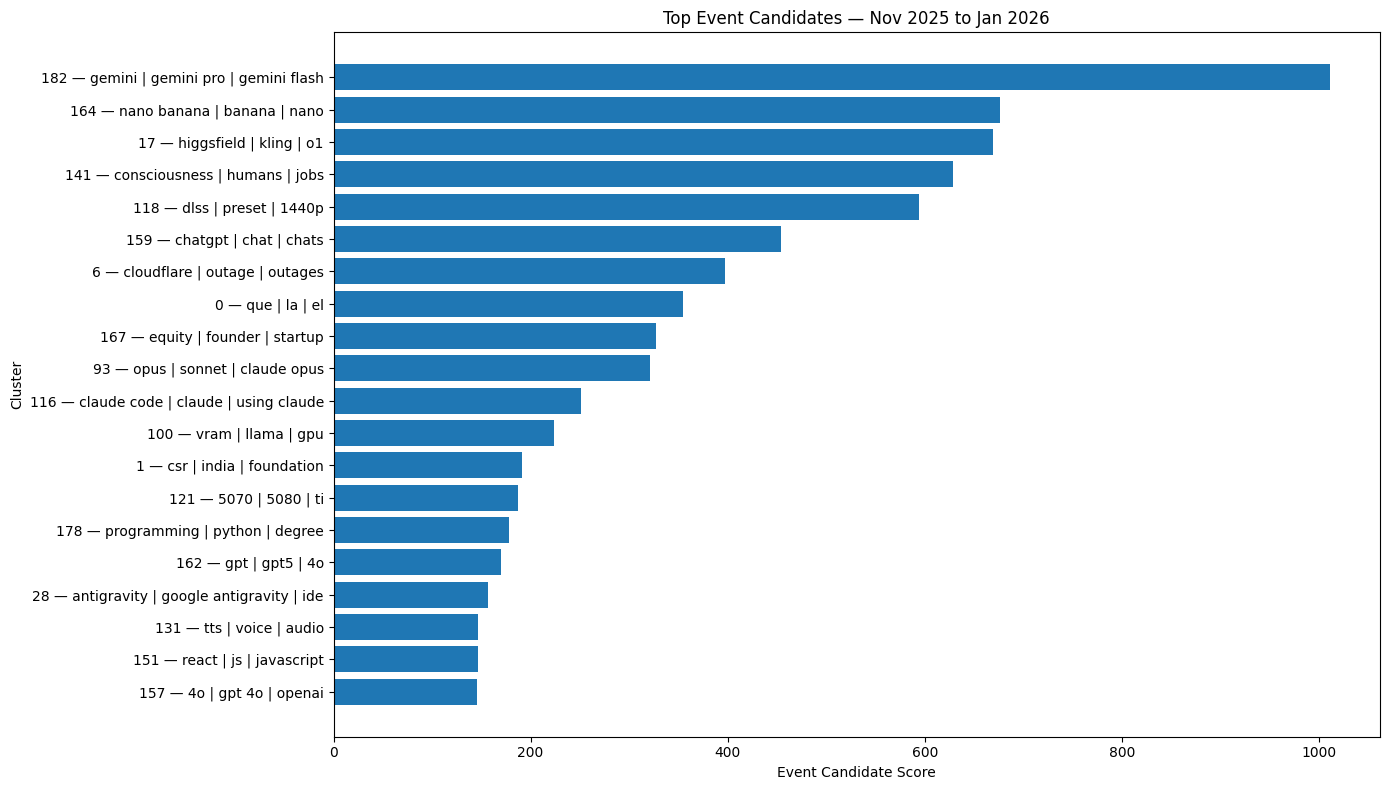

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/top_event_candidates.png


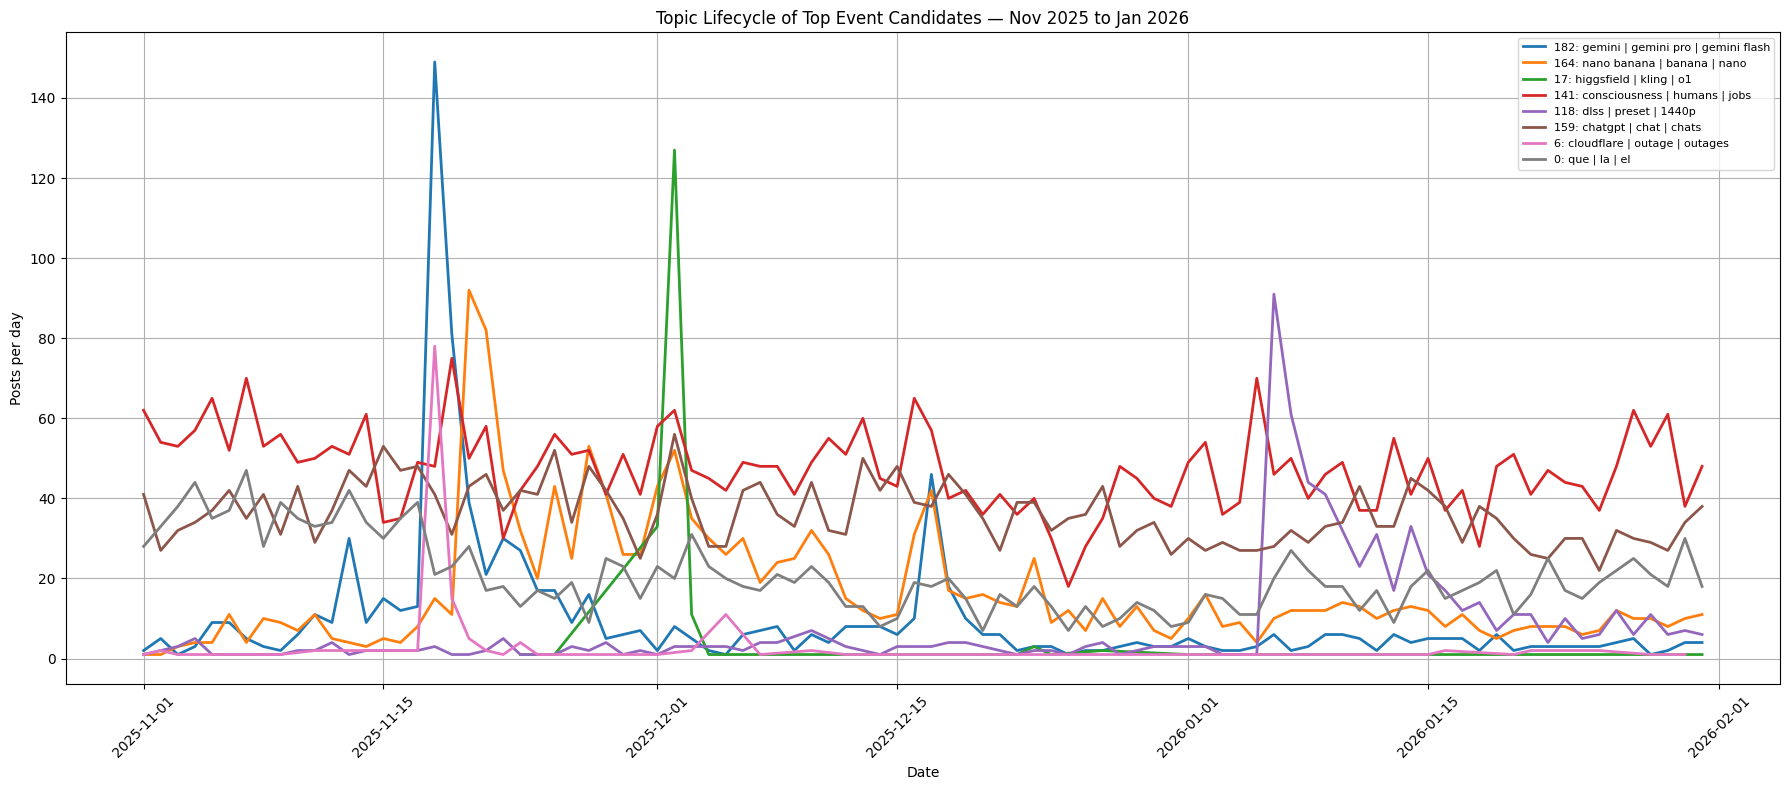

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/topic_lifecycle_top_events.png


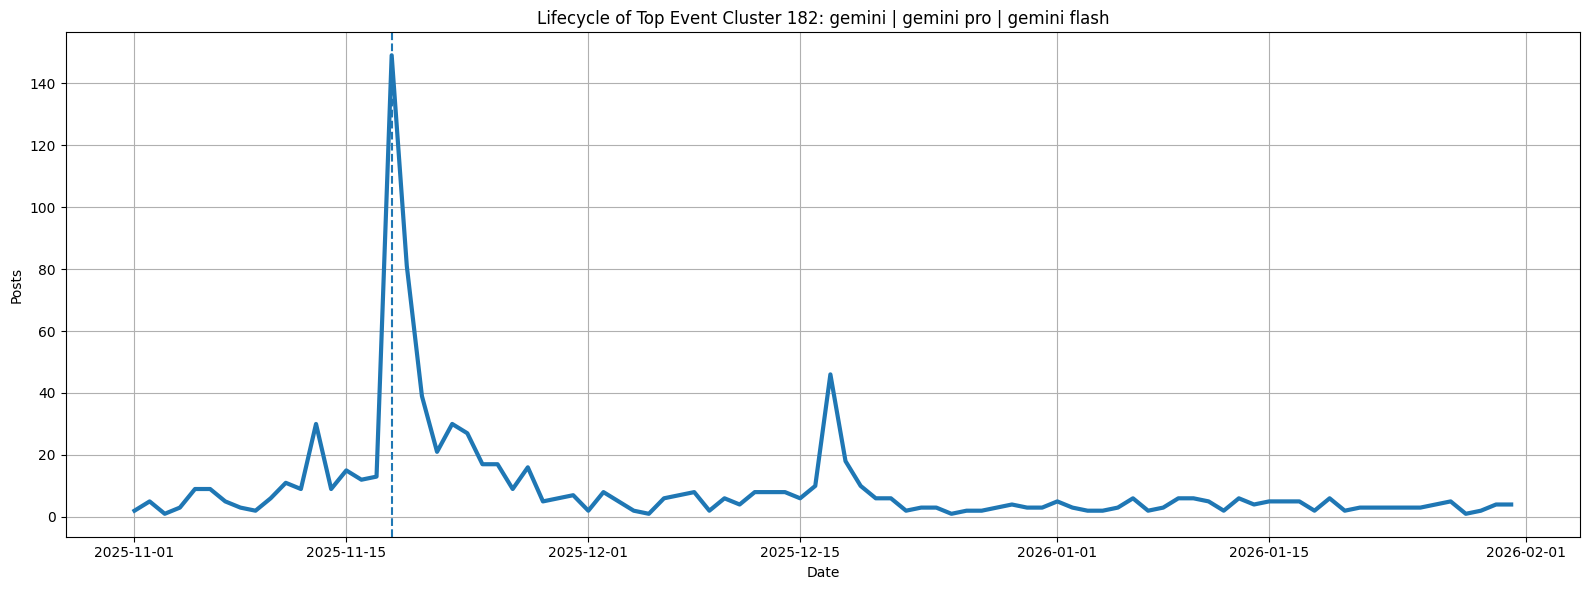

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/lifecycle_cluster_182.png
Top cluster: 182
Peak date: 2025-11-18 00:00:00+00:00
Peak volume: 149


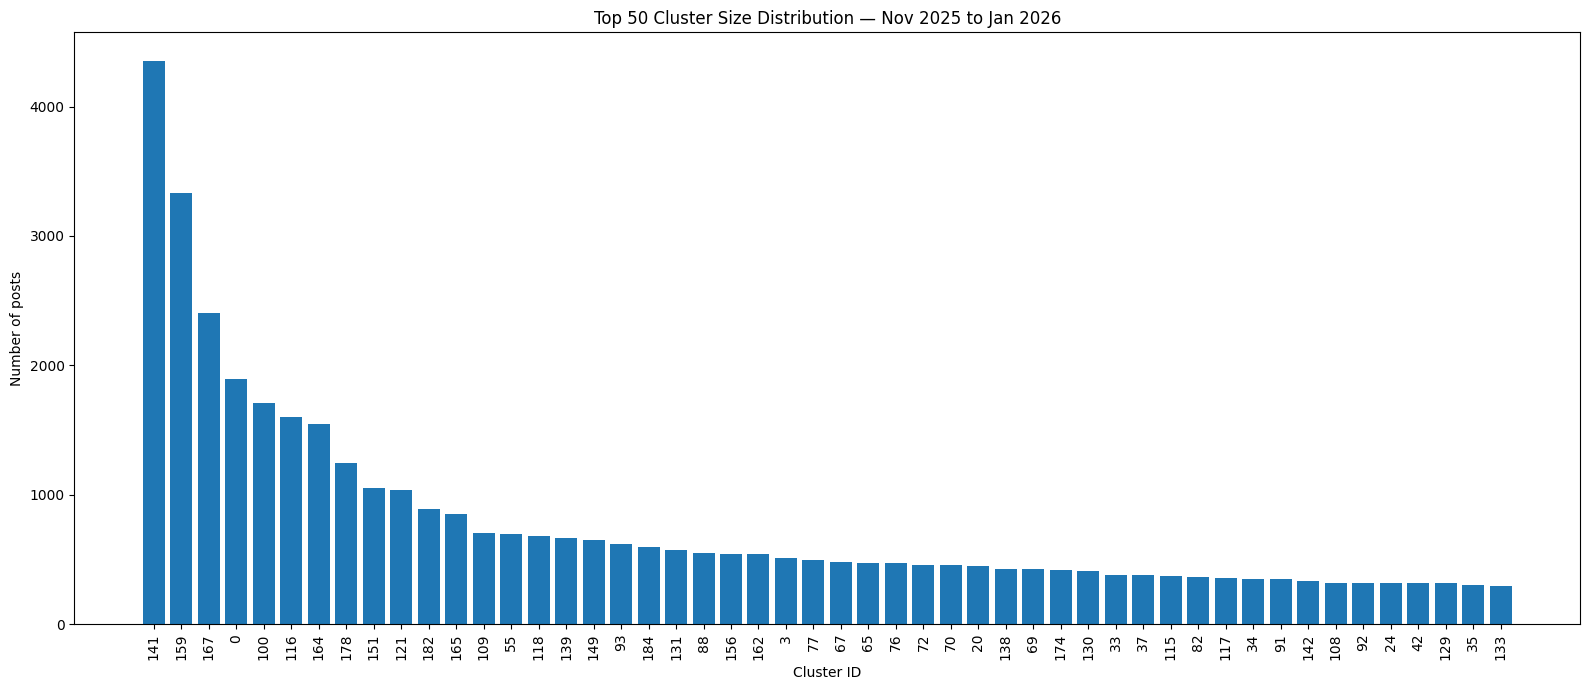

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/cluster_size_distribution_top50.png


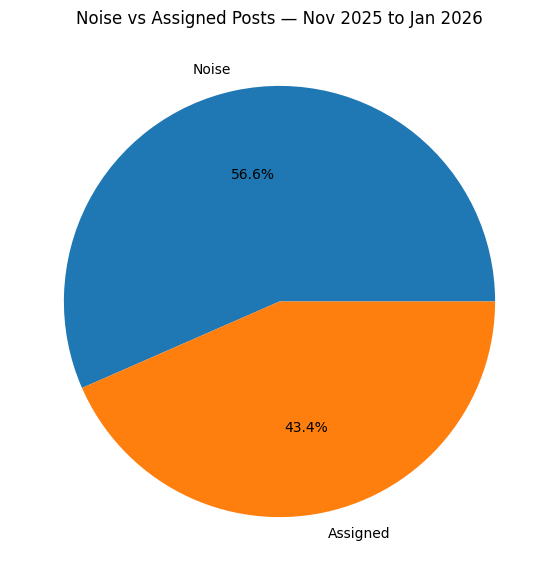

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/noise_vs_assigned.png


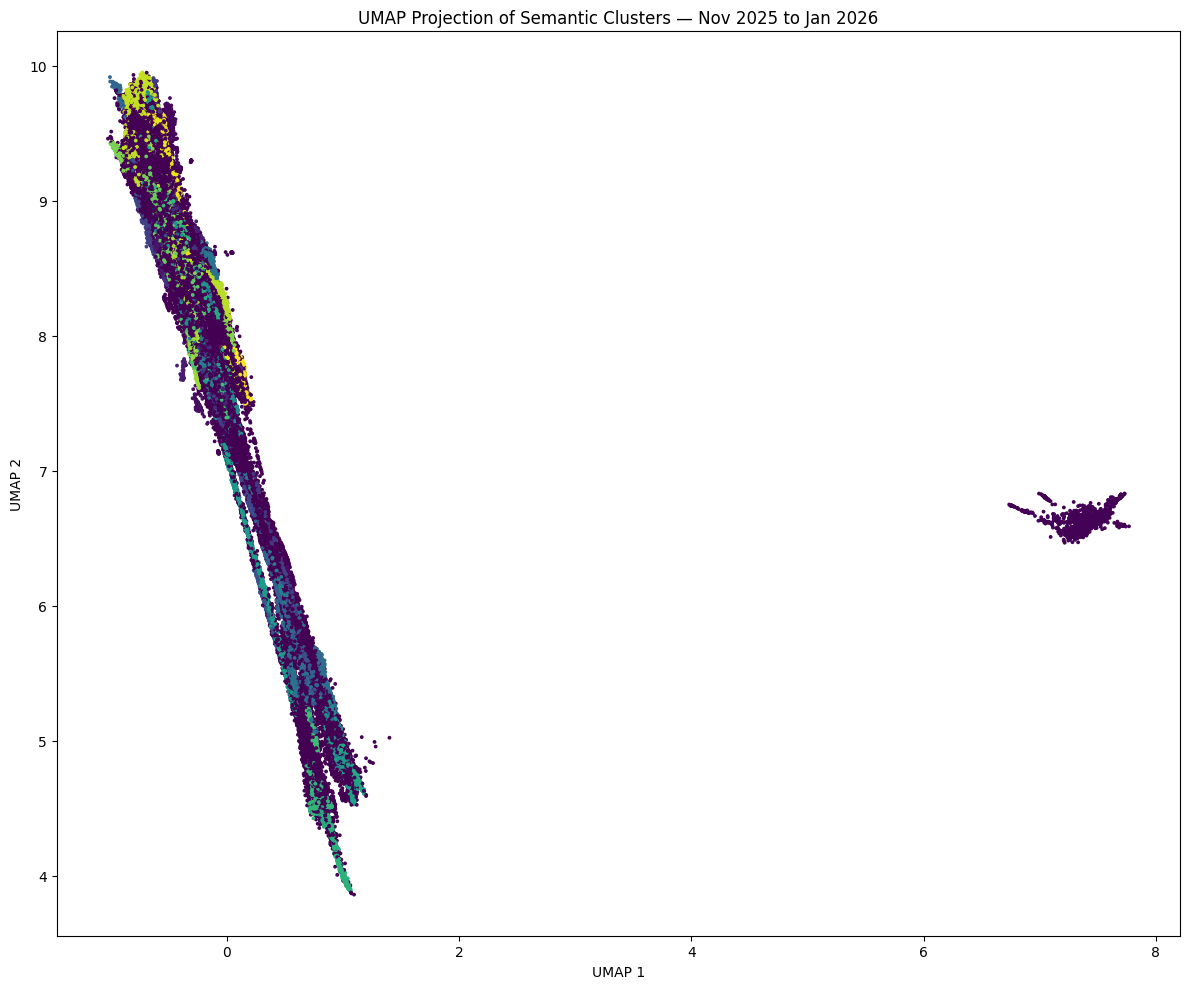

Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/plots/umap_semantic_clusters.png
DONE.


In [ ]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

POSTS_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
CLUSTER_LABELS_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_labels.npy"
UMAP_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"

OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
TEMPORAL_DIR = OUTPUT_DIR / "temporal_analysis"

CLUSTER_SUMMARY_OUTPUT = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_summary_labeled.csv"
EVENT_CANDIDATES_OUTPUT = TEMPORAL_DIR / "event_candidates_ranked.csv"

TOP_N_TERMS = 5
TOP_N_EVENTS = 20
TOP_N_PLOTS = 8

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TEMPORAL_DIR.mkdir(parents=True, exist_ok=True)

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_parquet(POSTS_FILE)

required_cols = ["cluster_id", "cluster_probability"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["created_dt"] = pd.to_datetime(df["created_dt"], utc=True, errors="coerce")

if "date" not in df.columns:
    df["date"] = df["created_dt"].dt.floor("D")
else:
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.floor("D")

print("Loaded posts:", df.shape)
print("Date range:", df["created_dt"].min(), "->", df["created_dt"].max())

if "text_for_embedding" in df.columns:
    TEXT_COL = "text_for_embedding"
elif "full_text" in df.columns:
    TEXT_COL = "full_text"
else:
    TEXT_COL = "title"

print("Using text column:", TEXT_COL)

# ==================================================
# BUILD CLUSTER SUMMARY
# ==================================================

STOPWORDS = {
    "the", "and", "for", "that", "this", "with", "from", "you", "your", "are",
    "was", "were", "have", "has", "had", "but", "not", "can", "could", "would",
    "should", "will", "just", "like", "about", "into", "than", "then", "they",
    "them", "their", "what", "when", "where", "why", "how", "all", "any",
    "new", "use", "using", "get", "got", "one", "out", "more", "some",
    "really", "does", "did", "been", "because", "after", "before",
    "chatgpt", "openai", "ai", "model"
}

def get_top_keywords(texts, top_k=12):
    text = " ".join(texts.fillna("").astype(str).tolist()).lower()
    words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9\-]{2,}\b", text)
    words = [w for w in words if w not in STOPWORDS and len(w) >= 3]
    counts = Counter(words)
    return ", ".join([f"{w}:{c}" for w, c in counts.most_common(top_k)])

def get_sample_titles(group, n=8):
    if "cluster_probability" in group.columns:
        group = group.sort_values("cluster_probability", ascending=False)

    titles = (
        group["title"]
        .fillna("")
        .astype(str)
        .str.strip()
        .tolist()
    )

    titles = [t for t in titles if t]

    return " || ".join(titles[:n])

valid_df = df[df["cluster_id"] != -1].copy()
summary_rows = []

for cluster_id, group in valid_df.groupby("cluster_id"):
    n_posts = len(group)

    top_subreddits = (
        group["subreddit"]
        .value_counts()
        .head(5)
        .to_dict()
    )

    daily_counts = (
        group.groupby("date")
        .size()
        .sort_values(ascending=False)
    )

    peak_date = daily_counts.index[0] if len(daily_counts) > 0 else None
    peak_count = int(daily_counts.iloc[0]) if len(daily_counts) > 0 else 0

    summary_rows.append({
        "cluster_id": cluster_id,
        "n_posts": n_posts,
        "date_start": group["date"].min(),
        "date_end": group["date"].max(),
        "peak_date": peak_date,
        "peak_count": peak_count,
        "top_subreddits": str(top_subreddits),
        "top_keywords": get_top_keywords(group[TEXT_COL], top_k=12),
        "sample_titles": get_sample_titles(group, n=8),
    })

cluster_summary = pd.DataFrame(summary_rows)

cluster_summary = (
    cluster_summary
    .sort_values("n_posts", ascending=False)
    .reset_index(drop=True)
)

print("Cluster summary:", cluster_summary.shape)

# ==================================================
# c-TF-IDF LABELING
# ==================================================

cluster_docs = (
    valid_df
    .groupby("cluster_id")[TEXT_COL]
    .apply(lambda x: " ".join(x.fillna("").astype(str)))
    .reset_index(name="cluster_text")
)

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.8
)

X = vectorizer.fit_transform(cluster_docs["cluster_text"])
words = vectorizer.get_feature_names_out()

doc_freq = np.asarray((X > 0).sum(axis=0)).ravel()
idf = np.log((X.shape[0] + 1) / (doc_freq + 1))
c_tf_idf = X.multiply(idf)

labels = []
top_terms_all = []

for i in range(c_tf_idf.shape[0]):
    row = c_tf_idf.getrow(i).toarray().ravel()
    top_idx = row.argsort()[-TOP_N_TERMS:][::-1]
    top_terms = [words[j] for j in top_idx]

    labels.append(" | ".join(top_terms[:3]))
    top_terms_all.append(", ".join(top_terms))

cluster_labels_df = pd.DataFrame({
    "cluster_id": cluster_docs["cluster_id"],
    "interpreted_label_ctfidf": labels,
    "ctfidf_top_terms": top_terms_all
})

cluster_summary = cluster_summary.merge(
    cluster_labels_df,
    on="cluster_id",
    how="left"
)

# ==================================================
# AUTOMATIC EVENT CANDIDATE RANKING
# ==================================================

cluster_summary["peak_ratio"] = (
    cluster_summary["peak_count"] / cluster_summary["n_posts"]
)

cluster_summary["eventness_score"] = cluster_summary["peak_ratio"]
cluster_summary["importance_score"] = cluster_summary["peak_count"]

cluster_summary["event_candidate_score"] = (
    cluster_summary["peak_count"] *
    np.log1p(cluster_summary["n_posts"])
)

cluster_summary = (
    cluster_summary
    .sort_values("event_candidate_score", ascending=False)
    .reset_index(drop=True)
)

cluster_summary.to_csv(CLUSTER_SUMMARY_OUTPUT, index=False)
cluster_summary.to_csv(EVENT_CANDIDATES_OUTPUT, index=False)

print("Saved:")
print(CLUSTER_SUMMARY_OUTPUT)
print(EVENT_CANDIDATES_OUTPUT)

display(
    cluster_summary[
        [
            "cluster_id",
            "interpreted_label_ctfidf",
            "n_posts",
            "peak_date",
            "peak_count",
            "peak_ratio",
            "event_candidate_score"
        ]
    ].head(20)
)

# ==================================================
# PLOT 1 — TOP EVENT CANDIDATES
# ==================================================

plot_df = cluster_summary.head(TOP_N_EVENTS).copy()

labels_plot = (
    plot_df["cluster_id"].astype(str)
    + " — "
    + plot_df["interpreted_label_ctfidf"].fillna("")
)

plt.figure(figsize=(14, 8))
plt.barh(labels_plot, plot_df["event_candidate_score"])
plt.gca().invert_yaxis()
plt.xlabel("Event Candidate Score")
plt.ylabel("Cluster")
plt.title("Top Event Candidates — Nov 2025 to Jan 2026")
plt.tight_layout()

out = PLOTS_DIR / "top_event_candidates.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ==================================================
# PLOT 2 — TOP EVENT LIFECYCLES
# ==================================================

target_clusters = cluster_summary.head(TOP_N_PLOTS)["cluster_id"].tolist()

df_lifecycle = df[df["cluster_id"].isin(target_clusters)].copy()

daily_counts = (
    df_lifecycle
    .groupby(["date", "cluster_id"])
    .size()
    .reset_index(name="n_posts")
)

plt.figure(figsize=(18, 8))

for cluster_id in target_clusters:
    temp = daily_counts[daily_counts["cluster_id"] == cluster_id]

    label = cluster_summary.loc[
        cluster_summary["cluster_id"] == cluster_id,
        "interpreted_label_ctfidf"
    ].iloc[0]

    plt.plot(
        temp["date"],
        temp["n_posts"],
        linewidth=2,
        label=f"{cluster_id}: {label}"
    )

plt.xlabel("Date")
plt.ylabel("Posts per day")
plt.title("Topic Lifecycle of Top Event Candidates — Nov 2025 to Jan 2026")
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

out = PLOTS_DIR / "topic_lifecycle_top_events.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ==================================================
# PLOT 3 — BEST SINGLE EVENT LIFECYCLE
# ==================================================

top_cluster = int(cluster_summary.iloc[0]["cluster_id"])
top_label = cluster_summary.iloc[0]["interpreted_label_ctfidf"]

single_cluster = (
    df[df["cluster_id"] == top_cluster]
    .groupby("date")
    .size()
    .reset_index(name="n_posts")
)

peak_idx = single_cluster["n_posts"].idxmax()
peak_date = single_cluster.loc[peak_idx, "date"]
peak_value = single_cluster.loc[peak_idx, "n_posts"]

plt.figure(figsize=(16, 6))
plt.plot(single_cluster["date"], single_cluster["n_posts"], linewidth=3)
plt.axvline(peak_date, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Posts")
plt.title(f"Lifecycle of Top Event Cluster {top_cluster}: {top_label}")
plt.grid(True)
plt.tight_layout()

out = PLOTS_DIR / f"lifecycle_cluster_{top_cluster}.png"
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)
print("Top cluster:", top_cluster)
print("Peak date:", peak_date)
print("Peak volume:", peak_value)

# ==================================================
# PLOT 4 — CLUSTER SIZE DISTRIBUTION
# ==================================================

cluster_sizes = (
    df[df["cluster_id"] != -1]
    .groupby("cluster_id")
    .size()
    .reset_index(name="n_posts")
    .sort_values("n_posts", ascending=False)
    .head(50)
)

plt.figure(figsize=(16, 7))
plt.bar(cluster_sizes["cluster_id"].astype(str), cluster_sizes["n_posts"])
plt.xlabel("Cluster ID")
plt.ylabel("Number of posts")
plt.title("Top 50 Cluster Size Distribution — Nov 2025 to Jan 2026")
plt.xticks(rotation=90)
plt.tight_layout()

out = PLOTS_DIR / "cluster_size_distribution_top50.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ==================================================
# PLOT 5 — NOISE RATIO
# ==================================================

noise_count = int((df["cluster_id"] == -1).sum())
assigned_count = int((df["cluster_id"] != -1).sum())

plt.figure(figsize=(7, 7))
plt.pie(
    [noise_count, assigned_count],
    labels=["Noise", "Assigned"],
    autopct="%1.1f%%"
)
plt.title("Noise vs Assigned Posts — Nov 2025 to Jan 2026")

out = PLOTS_DIR / "noise_vs_assigned.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ==================================================
# PLOT 6 — UMAP
# ==================================================

if UMAP_FILE.exists() and CLUSTER_LABELS_FILE.exists():
    umap_embeddings = np.load(UMAP_FILE)
    cluster_labels = np.load(CLUSTER_LABELS_FILE)

    plt.figure(figsize=(12, 10))
    plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c=cluster_labels,
        s=3
    )
    plt.title("UMAP Projection of Semantic Clusters — Nov 2025 to Jan 2026")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.tight_layout()

    out = PLOTS_DIR / "umap_semantic_clusters.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)
else:
    print("UMAP files not found, skipped.")

print("DONE.")

# STEP 22 — Baseline clustering (TF-IDF + KMeans)
# Crea una baseline lessicale con TF-IDF e KMeans (k=227) per confrontarla con la pipeline semantica MiniLM+UMAP+HDBSCAN.

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

df = pd.read_parquet(
    BASE / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
)

print(df.shape)
print(df.columns.tolist())

(140669, 10)
['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments', 'cluster_id', 'cluster_probability']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import time

# ==================================================
# STEP 1 — TF-IDF BASELINE
# ==================================================

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    min_df=5,
    max_df=0.8
)

X_tfidf = vectorizer.fit_transform(
    df["text_for_embedding"].fillna("")
)

print("TF-IDF shape:", X_tfidf.shape)

# ==================================================
# STEP 2 — GET HDBSCAN CLUSTER COUNT
# ==================================================

if "cluster_id" in df.columns:
    n_hdbscan_clusters = df.loc[
        df["cluster_id"] != -1,
        "cluster_id"
    ].nunique()
else:
    raise ValueError("df must contain cluster_id. Load posts_with_clusters file.")

print("HDBSCAN clusters:", n_hdbscan_clusters)

# ==================================================
# STEP 3 — KMEANS BASELINE
# ==================================================

kmeans = KMeans(
    n_clusters=n_hdbscan_clusters,
    random_state=42,
    n_init=10,
    max_iter=200,
    verbose=1
)

start = time.time()

baseline_labels = kmeans.fit_predict(X_tfidf)

end = time.time()

# ==================================================
# STEP 4 — ATTACH BASELINE CLUSTERS
# ==================================================

df["baseline_cluster"] = baseline_labels

print("\nDONE")
print("Execution time (minutes):", round((end - start) / 60, 2))

# ==================================================
# STEP 5 — CLUSTER SIZE DISTRIBUTION
# ==================================================

cluster_sizes = (
    df["baseline_cluster"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nTop 20 baseline cluster sizes:")
print(cluster_sizes.head(20))

TF-IDF shape: (140669, 10000)
HDBSCAN clusters: 185
Initialization complete
Iteration 0, inertia 231842.50759019502.
Iteration 1, inertia 130417.34336881978.
Iteration 2, inertia 128568.97969846205.
Iteration 3, inertia 127862.33132562395.
Iteration 4, inertia 127542.84047129979.
Iteration 5, inertia 127397.28249923087.
Iteration 6, inertia 127331.20275064219.
Iteration 7, inertia 127280.5747739685.
Iteration 8, inertia 127246.4575897459.
Iteration 9, inertia 127227.41364117368.
Iteration 10, inertia 127207.75929079267.
Iteration 11, inertia 127194.77959505019.
Iteration 12, inertia 127183.2487432555.
Iteration 13, inertia 127171.24645423442.
Iteration 14, inertia 127163.27216676688.
Iteration 15, inertia 127157.92332832137.
Iteration 16, inertia 127153.16410356363.
Iteration 17, inertia 127148.63144129796.
Iteration 18, inertia 127143.94261493186.
Iteration 19, inertia 127139.58286672518.
Iteration 20, inertia 127136.23724916062.
Iteration 21, inertia 127133.90330906611.
Iteration 22,

# STEP 23 — Inspect KMeans clusters
# Mostra le parole TF-IDF più importanti per ogni cluster per interpretare la baseline.

In [ ]:
import numpy as np

terms = vectorizer.get_feature_names_out()

for cluster_id in range(10):
    center = kmeans.cluster_centers_[cluster_id]

    top_idx = np.argsort(center)[-10:][::-1]

    top_terms = [terms[i] for i in top_idx]

    print("\nCLUSTER", cluster_id)
    print(top_terms)

NameError: name 'vectorizer' is not defined

# STEP 24 — Inspect KMeans samples
# Mostra esempi di titoli per ogni cluster della baseline per valutazione qualitativa.

In [ ]:
for cluster_id in range(10):
    sample = (
        df[df["baseline_cluster"] == cluster_id]["title"]
        .dropna()
        .head(10)
    )

    print("\n" + "="*80)
    print("CLUSTER", cluster_id)
    print(sample.to_string(index=False))


CLUSTER 0
Best way to improve sales, leadership & busines...
(Business Partner) - Lead Gen / Sales / Marketi...
From idea to first sales in 6 months: Launching...
Here’s a toolkit I built that lays out everythi...
Looking for ideas to improve sales at gas stati...
Apple iPhone sales hit 3 billion mark amid 13% ...
The "Castle in Paradise" Close: 10x Your SaaS P...
For my freelance clients, I created an Excel da...
         2 sales in first 3 days, is my saas good?
Struggling with low sales? Here’s what I see in...

CLUSTER 1
I’m attempting to make the Ai agent draw using ...
How do I 'save' an Agent in order to use anothe...
🚀 Comparing JavaScript Multi‑Agent Frameworks: ...
[AskJS] What JavaScript frameworks are people u...
I’m ChatGPT (Agent Mode) – Here are my 16Person...
I’m ChatGPT (Agent Mode) – Here are my 16Person...
Beyond Python: AI Agents in JavaScript with Kai...
ChatGPT (Agent Mode) – My MBTI/16Personalities ...
Is this AI Coding Agent for your terminal any g...
Is it too

# STEP 25 — Evaluate baseline clustering
# Calcola il silhouette score su un campione per valutare la qualità della clustering TF-IDF + KMeans.

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(
    X_tfidf.shape[0],
    size=5000,
    replace=False
)

score = silhouette_score(
    X_tfidf[sample_idx],
    df.iloc[sample_idx]["baseline_cluster"]
)

print("Baseline silhouette:", score)

Baseline silhouette: 0.015850878923957194


# STEP 26 — Load data for evaluation
# Carica embedding UMAP e dataset clusterizzato per valutare la qualità della pipeline semantica.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

UMAP_FILE = BASE / "reddit_tech_nov_2025_jan_2026_umap_embeddings.npy"
CLUSTERED_FILE = BASE / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"

# ==================================================
# LOAD
# ==================================================

umap_embeddings = np.load(UMAP_FILE)

df_clusters = pd.read_parquet(CLUSTERED_FILE)

print("UMAP:", umap_embeddings.shape)
print("Clustered dataframe:", df_clusters.shape)
print("Columns:", df_clusters.columns.tolist())

# ==================================================
# SAFETY CHECK
# ==================================================

assert umap_embeddings.shape[0] == df_clusters.shape[0], "Mismatch: UMAP rows != dataframe rows"
assert "cluster_id" in df_clusters.columns, "Missing cluster_id"
assert "cluster_probability" in df_clusters.columns, "Missing cluster_probability"

print("Files loaded correctly.")

UMAP: (140669, 15)
Clustered dataframe: (140669, 10)
Columns: ['id', 'created_dt', 'date', 'subreddit', 'title', 'text_for_embedding', 'score', 'num_comments', 'cluster_id', 'cluster_probability']
Files loaded correctly.


# STEP 27 — Evaluate HDBSCAN clustering
# Calcola il silhouette score sui cluster semantici (escludendo noise) per confronto con la baseline.

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# ==================================================
# SAMPLE FOR SILHOUETTE
# ==================================================

sample_size = min(5000, umap_embeddings.shape[0])

sample_idx = np.random.choice(
    umap_embeddings.shape[0],
    size=sample_size,
    replace=False
)

sample_df = df_clusters.iloc[sample_idx].copy()

# remove noise
mask = sample_df["cluster_id"] != -1

X_eval = umap_embeddings[sample_idx][mask]
y_eval = sample_df.loc[mask, "cluster_id"].values

print("Evaluation points:", len(y_eval))
print("Unique clusters:", len(np.unique(y_eval)))

# ==================================================
# SAFETY CHECK
# ==================================================

if len(np.unique(y_eval)) < 2:
    raise ValueError(
        "Silhouette requires at least 2 clusters."
    )

# ==================================================
# SILHOUETTE SCORE
# ==================================================

score_hdbscan = silhouette_score(
    X_eval,
    y_eval
)

print("HDBSCAN silhouette:", round(score_hdbscan, 4))

Evaluation points: 2177
Unique clusters: 183
HDBSCAN silhouette: 0.4848


# STEP 28 — Event scoring ablation
# Calcola feature temporali, engagement e semantic coherence per ogni cluster; confronta 5 scoring functions (S1–S5), genera Top-20 ranking, overlap, template di validazione e plot.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/AI_project/outputs/scoring_ablation
Posts: (165733, 10)
Cluster summary: (227, 15)
Assigned posts: (71980, 10)
Valid clusters: 227
   cluster_id  n_posts                date_start                  date_end  \
0           0     2783 2025-08-01 00:00:00+00:00 2025-10-31 00:00:00+00:00   
1           1      508 2025-08-01 00:00:00+00:00 2025-10-31 00:00:00+00:00   
2           2      111 2025-08-05 00:00:00+00:00 2025-10-31 00:00:00+00:00   
3           3      268 2025-08-01 00:00:00+00:00 2025-10-31 00:00:00+00:00   
4           4      169 2025-08-02 00:00:00+00:00 2025-10-31 00:00:00+00:00   

     avg_score  avg_comments  total_score  total_comments  \
0     0.871362      0.887891         2425            2471   
1    30.007874     10.507874        15244            5338   
2  1774.774775    152.630631       197000      

,rank,cluster_id,interpreted_label_ctfidf,n_posts,peak_date,peak_count,S1_baseline
0,1,188,gpt | 4o | gpt 4o,3364,2025-08-08 00:00:00+00:00,602,4888.952312
1,2,172,4o | openai | gpt,1221,2025-08-08 00:00:00+00:00,134,952.504715
2,3,192,4o | gpt | chatgpt,853,2025-08-08 00:00:00+00:00,135,911.240711
3,4,194,4o | legacy models | legacy,684,2025-08-08 00:00:00+00:00,103,672.530140
4,5,165,iphone | pro max | 17 pro,1246,2025-09-10 00:00:00+00:00,92,655.821627
5,6,127,gemini | gemini pro | google gemini,2648,2025-08-08 00:00:00+00:00,60,472.916249
6,7,176,python | java | dsa,3441,2025-08-21 00:00:00+00:00,56,456.053247
7,8,124,image | chatgpt | asked chatgpt,1403,2025-08-02 00:00:00+00:00,52,376.848190
8,9,0,que | la | en,2783,2025-09-04 00:00:00+00:00,45,356.923981
9,10,159,iphone 17 | 17 pro | pickup,412,2025-09-19 00:00:00+00:00,55,331.289618


Saved: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/top_20_S1_baseline.csv

TOP 20 BY S2_burst_aware


,rank,cluster_id,interpreted_label_ctfidf,n_posts,peak_date,peak_count,S2_burst_aware
0,1,188,gpt | 4o | gpt 4o,3364,2025-08-08 00:00:00+00:00,602,874.895747
1,2,192,4o | gpt | chatgpt,853,2025-08-08 00:00:00+00:00,135,144.217463
2,3,172,4o | openai | gpt,1221,2025-08-08 00:00:00+00:00,134,104.533687
3,4,194,4o | legacy models | legacy,684,2025-08-08 00:00:00+00:00,103,101.272814
4,5,14,atlas | chatgpt atlas | browser,132,2025-10-22 00:00:00+00:00,42,65.352847
5,6,165,iphone | pro max | 17 pro,1246,2025-09-10 00:00:00+00:00,92,48.423427
6,7,193,legacy models | legacy | old models,146,2025-08-08 00:00:00+00:00,37,46.793851
7,8,159,iphone 17 | 17 pro | pickup,412,2025-09-19 00:00:00+00:00,55,44.225556
8,9,11,ref | google store | pixel,94,2025-09-09 00:00:00+00:00,26,32.749157
9,10,7,sora | cameo | sora2,448,2025-10-01 00:00:00+00:00,49,32.729826


Saved: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/top_20_S2_burst_aware.csv

TOP 20 BY S3_engagement_aware


...

,rank,cluster_id,interpreted_label_ctfidf,n_posts,peak_date,peak_count,S5_semantic_quality
0,1,188,gpt | 4o | gpt 4o,3364,2025-08-08 00:00:00+00:00,602,544.891427
1,2,192,4o | gpt | chatgpt,853,2025-08-08 00:00:00+00:00,135,98.973133
2,3,172,4o | openai | gpt,1221,2025-08-08 00:00:00+00:00,134,72.366188
3,4,194,4o | legacy models | legacy,684,2025-08-08 00:00:00+00:00,103,61.914752
4,5,14,atlas | chatgpt atlas | browser,132,2025-10-22 00:00:00+00:00,42,44.081438
5,6,165,iphone | pro max | 17 pro,1246,2025-09-10 00:00:00+00:00,92,32.555943
6,7,159,iphone 17 | 17 pro | pickup,412,2025-09-19 00:00:00+00:00,55,29.769953
7,8,193,legacy models | legacy | old models,146,2025-08-08 00:00:00+00:00,37,28.697387
8,9,11,ref | google store | pixel,94,2025-09-09 00:00:00+00:00,26,22.984836
9,10,5,sora | sora codes | codes,140,2025-10-07 00:00:00+00:00,28,21.400495


Saved: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/top_20_S5_semantic_quality.csv
Saved overlap table: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/top_k_score_overlap.csv


,score_a,score_b,top_k_overlap,jaccard
0,S1_baseline,S1_baseline,20,1.000000
1,S1_baseline,S2_burst_aware,13,0.481481
2,S1_baseline,S3_engagement_aware,18,0.818182
3,S1_baseline,S4_full_metadata,13,0.481481
4,S1_baseline,S5_semantic_quality,12,0.428571
5,S2_burst_aware,S1_baseline,13,0.481481
6,S2_burst_aware,S2_burst_aware,20,1.000000
7,S2_burst_aware,S3_engagement_aware,13,0.481481
8,S2_burst_aware,S4_full_metadata,18,0.818182
9,S2_burst_aware,S5_semantic_quality,19,0.904762


Saved validation template: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/validation_template_top_events.csv


,score_method,rank,cluster_id,label,peak_date,n_posts,peak_count,real_world_event_found,real_world_event_name,source_url,match,notes
0,S1_baseline,1,188,gpt | 4o | gpt 4o,2025-08-08 00:00:00+00:00,3364,602,,,,,
1,S1_baseline,2,172,4o | openai | gpt,2025-08-08 00:00:00+00:00,1221,134,,,,,
2,S1_baseline,3,192,4o | gpt | chatgpt,2025-08-08 00:00:00+00:00,853,135,,,,,
3,S1_baseline,4,194,4o | legacy models | legacy,2025-08-08 00:00:00+00:00,684,103,,,,,
4,S1_baseline,5,165,iphone | pro max | 17 pro,2025-09-10 00:00:00+00:00,1246,92,,,,,
5,S1_baseline,6,127,gemini | gemini pro | google gemini,2025-08-08 00:00:00+00:00,2648,60,,,,,
6,S1_baseline,7,176,python | java | dsa,2025-08-21 00:00:00+00:00,3441,56,,,,,
7,S1_baseline,8,124,image | chatgpt | asked chatgpt,2025-08-02 00:00:00+00:00,1403,52,,,,,
8,S1_baseline,9,0,que | la | en,2025-09-04 00:00:00+00:00,2783,45,,,,,
9,S1_baseline,10,159,iphone 17 | 17 pro | pickup,2025-09-19 00:00:00+00:00,412,55,,,,,


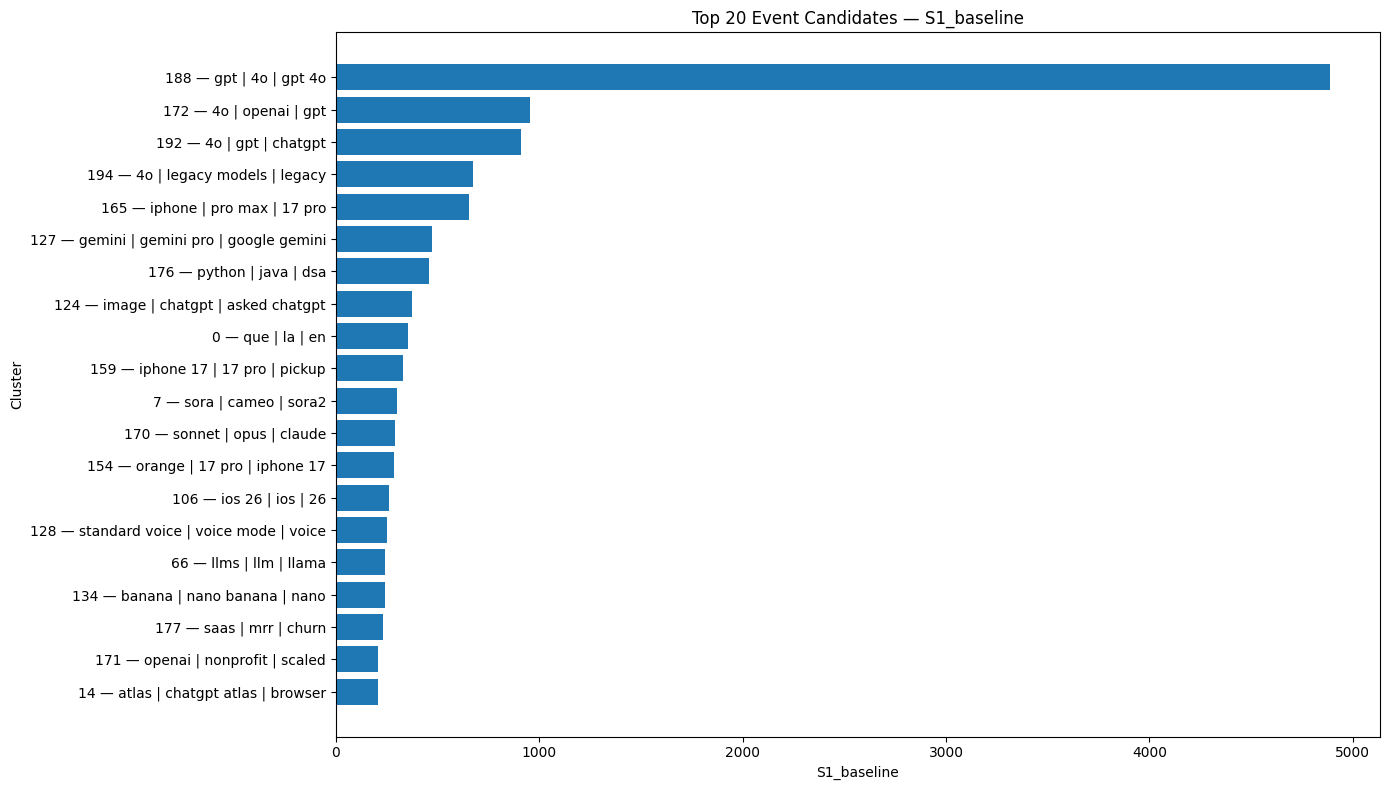

Saved plot: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/plot_top_20_S1_baseline.png


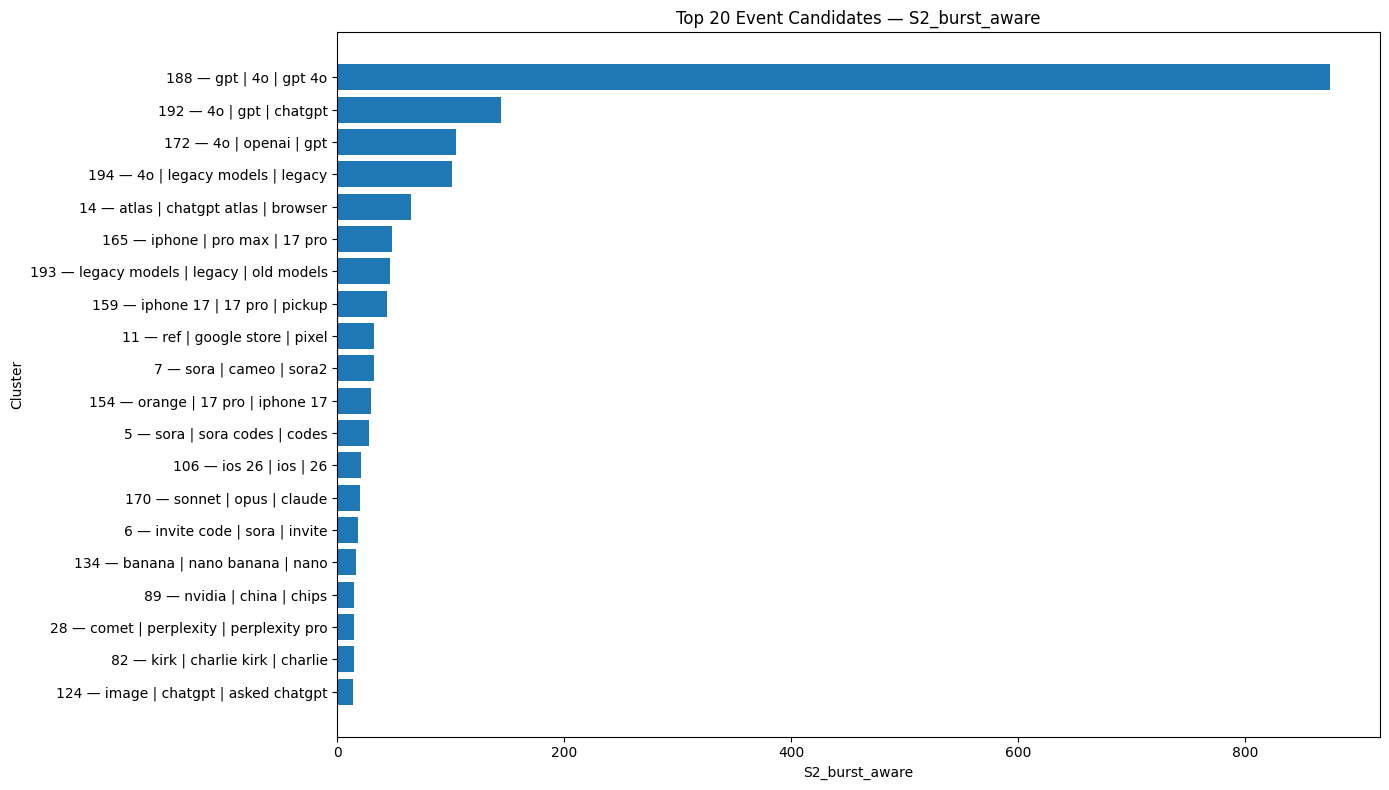

Saved plot: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/plot_top_20_S2_burst_aware.png


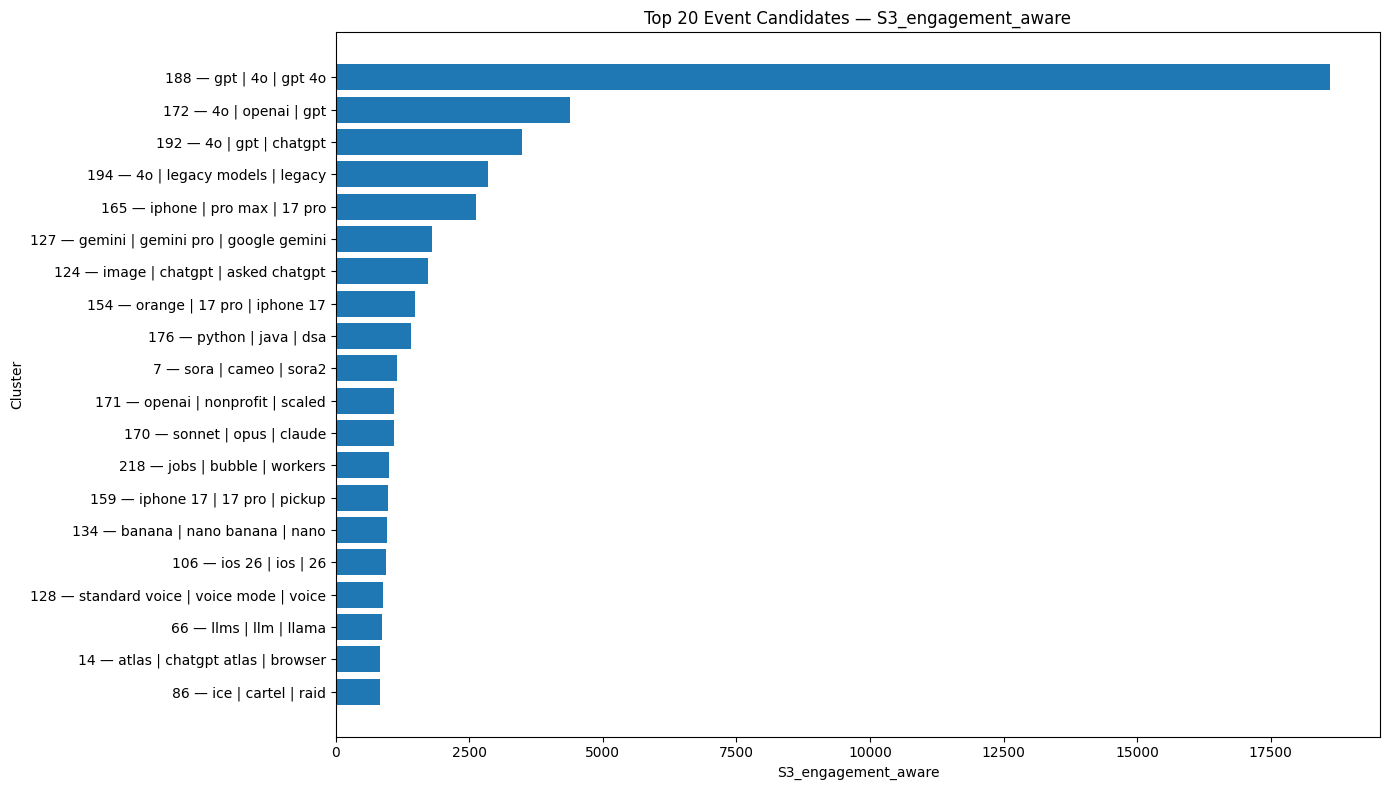

Saved plot: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/plot_top_20_S3_engagement_aware.png


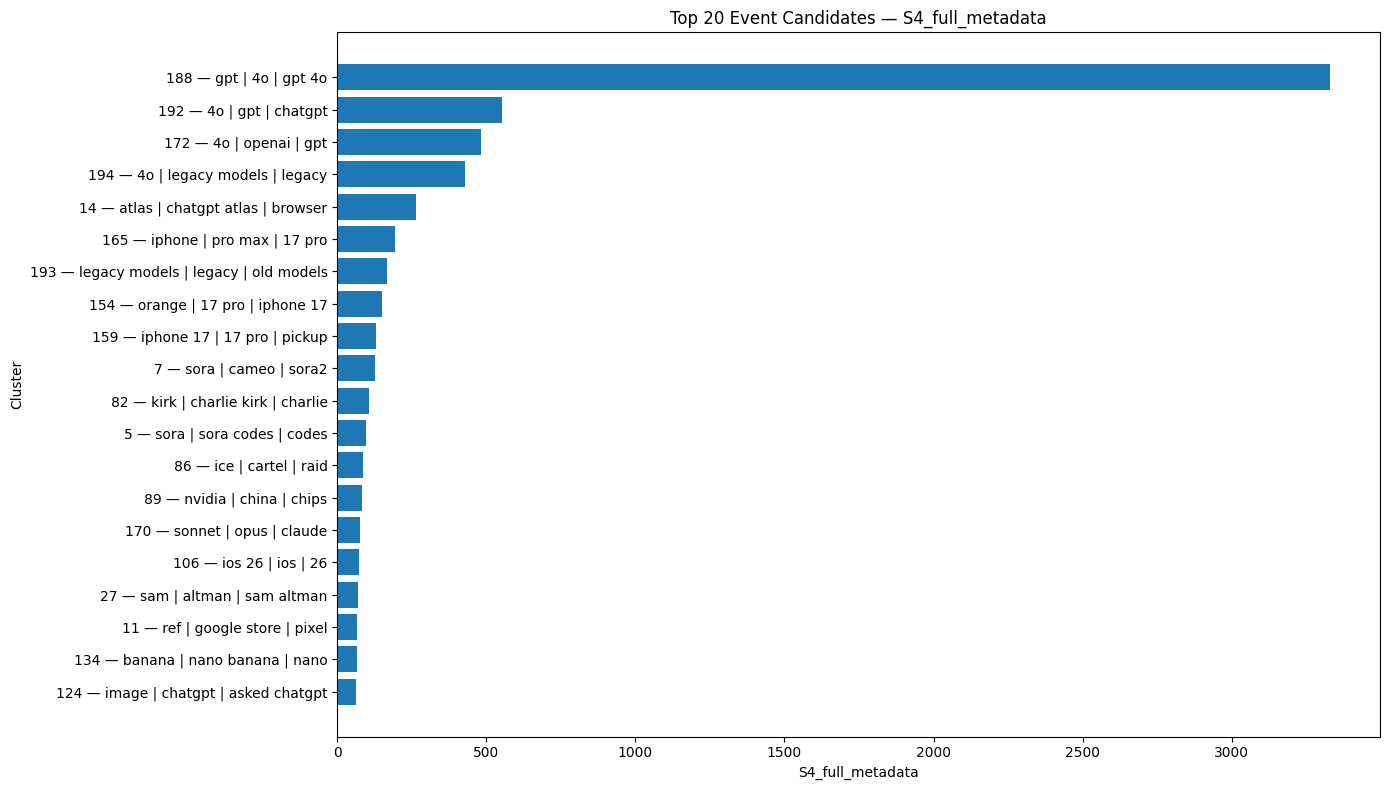

Saved plot: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/plot_top_20_S4_full_metadata.png


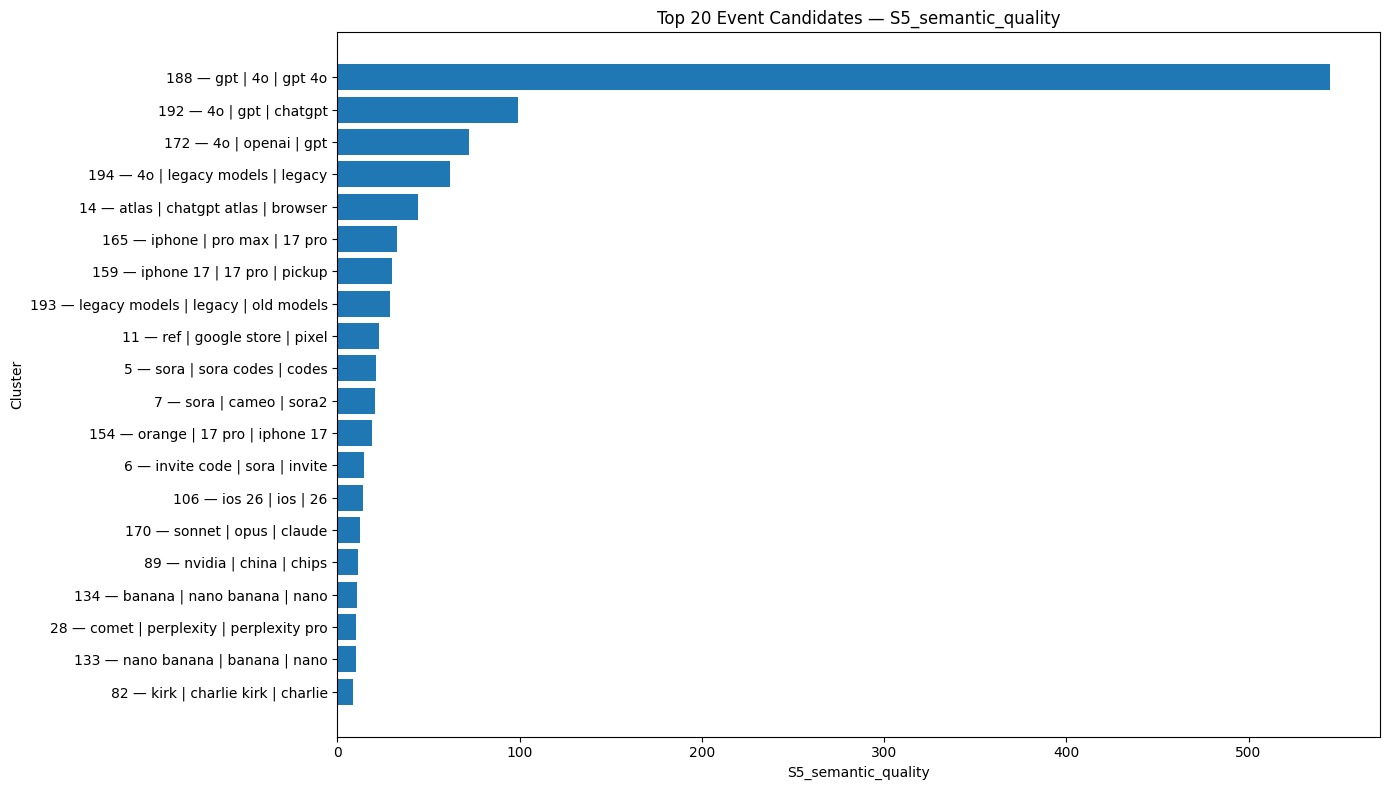

Saved plot: /content/drive/MyDrive/AI_project/outputs/scoring_ablation/plot_top_20_S5_semantic_quality.png

DONE.
All outputs saved in: /content/drive/MyDrive/AI_project/outputs/scoring_ablation


In [ ]:
# ============================================================
# EVENT SCORING ABLATION
# Unsupervised Reddit Technology Event Discovery
#
# Goal:
# Compare different event scoring formulas WITHOUT reclustering.
#
# Input:
# - reddit_tech_posts_with_clusters.parquet
# - reddit_tech_cluster_summary_labeled.csv
# - reddit_tech_embeddings.npy
#
# Output:
# - event_scoring_ablation_full.csv
# - top_20_S1_baseline.csv
# - top_20_S2_burst_aware.csv
# - top_20_S3_engagement_aware.csv
# - top_20_S4_full_metadata.csv
# - top_20_S5_semantic_quality.csv
# - validation_template_top_events.csv
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# STEP 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# STEP 2 — CONFIG
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project")

POSTS_FILE = BASE_DIR / "reddit_tech_posts_with_clusters.parquet"
SUMMARY_FILE = BASE_DIR / "reddit_tech_cluster_summary_labeled.csv"
EMBEDDINGS_FILE = BASE_DIR / "reddit_tech_embeddings.npy"

OUTPUT_DIR = BASE_DIR / "outputs" / "scoring_ablation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 20
MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE = 1000

print("Output directory:", OUTPUT_DIR)

# ============================================================
# STEP 3 — LOAD DATA
# ============================================================

df = pd.read_parquet(POSTS_FILE)
cluster_summary = pd.read_csv(SUMMARY_FILE)

print("Posts:", df.shape)
print("Cluster summary:", cluster_summary.shape)

df["created_dt"] = pd.to_datetime(df["created_dt"], utc=True, errors="coerce")

if "date" not in df.columns:
    df["date"] = df["created_dt"].dt.floor("D")
else:
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.floor("D")

# Keep only assigned clusters
df_valid = df[df["cluster_id"] != -1].copy()

print("Assigned posts:", df_valid.shape)
print("Valid clusters:", df_valid["cluster_id"].nunique())

# ============================================================
# STEP 4 — BASIC CLUSTER TEMPORAL FEATURES
# ============================================================

# Total posts per cluster
cluster_stats = (
    df_valid
    .groupby("cluster_id")
    .agg(
        n_posts=("id", "count"),
        date_start=("date", "min"),
        date_end=("date", "max"),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean"),
        total_score=("score", "sum"),
        total_comments=("num_comments", "sum")
    )
    .reset_index()
)

# Daily counts
daily_counts = (
    df_valid
    .groupby(["cluster_id", "date"])
    .size()
    .reset_index(name="daily_posts")
)

# Peak features
peak_stats = (
    daily_counts
    .sort_values(["cluster_id", "daily_posts"], ascending=[True, False])
    .groupby("cluster_id")
    .head(1)
    .rename(columns={
        "date": "peak_date",
        "daily_posts": "peak_count"
    })
    [["cluster_id", "peak_date", "peak_count"]]
)

# Active days and mean daily activity
daily_stats = (
    daily_counts
    .groupby("cluster_id")
    .agg(
        active_days=("date", "count"),
        mean_daily_posts=("daily_posts", "mean"),
        std_daily_posts=("daily_posts", "std")
    )
    .reset_index()
)

cluster_stats = (
    cluster_stats
    .merge(peak_stats, on="cluster_id", how="left")
    .merge(daily_stats, on="cluster_id", how="left")
)

cluster_stats["std_daily_posts"] = cluster_stats["std_daily_posts"].fillna(0)

# Burst concentration
cluster_stats["burst_share"] = (
    cluster_stats["peak_count"] / cluster_stats["n_posts"]
)

# Peak prominence
cluster_stats["peak_prominence"] = (
    cluster_stats["peak_count"] / cluster_stats["mean_daily_posts"]
)

# Engagement
cluster_stats["avg_score"] = cluster_stats["avg_score"].fillna(0).clip(lower=0)
cluster_stats["avg_comments"] = cluster_stats["avg_comments"].fillna(0).clip(lower=0)

cluster_stats["engagement"] = (
    cluster_stats["avg_score"] + cluster_stats["avg_comments"]
)

print(cluster_stats.head())

# ============================================================
# STEP 5 — SEMANTIC COHERENCE
# ============================================================
# Coherence = average cosine similarity of posts to cluster centroid.
# To avoid huge memory usage, sample up to 1000 posts per cluster.

print("Loading embeddings...")
embeddings = np.load(EMBEDDINGS_FILE, mmap_mode="r")
print("Embeddings:", embeddings.shape)

if embeddings.shape[0] != df.shape[0]:
    raise ValueError(
        f"Embeddings rows {embeddings.shape[0]} do not match df rows {df.shape[0]}"
    )

coherence_rows = []

rng = np.random.default_rng(42)

for cluster_id, group in df_valid.groupby("cluster_id"):
    idx = group.index.to_numpy()

    if len(idx) > MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE:
        idx_sample = rng.choice(
            idx,
            size=MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE,
            replace=False
        )
    else:
        idx_sample = idx

    X = np.asarray(embeddings[idx_sample], dtype=np.float32)

    centroid = X.mean(axis=0, keepdims=True)

    sims = cosine_similarity(X, centroid).ravel()

    coherence_rows.append({
        "cluster_id": cluster_id,
        "semantic_coherence": float(np.mean(sims)),
        "semantic_coherence_std": float(np.std(sims)),
        "coherence_sample_size": len(idx_sample)
    })

coherence_df = pd.DataFrame(coherence_rows)

cluster_stats = cluster_stats.merge(
    coherence_df,
    on="cluster_id",
    how="left"
)

print("Coherence computed.")
print(cluster_stats[["cluster_id", "semantic_coherence"]].head())

# ============================================================
# STEP 6 — MERGE WITH LABELS
# ============================================================

label_cols = [
    "cluster_id",
    "interpreted_label_ctfidf",
    "ctfidf_top_terms",
    "top_subreddits",
    "sample_titles"
]

label_cols = [c for c in label_cols if c in cluster_summary.columns]

cluster_stats = cluster_stats.merge(
    cluster_summary[label_cols],
    on="cluster_id",
    how="left"
)

# ============================================================
# STEP 7 — DEFINE SCORING FUNCTIONS
# ============================================================

# S1 — current baseline
cluster_stats["S1_baseline"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"])
)

# S2 — burst-aware
cluster_stats["S2_burst_aware"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"]) *
    cluster_stats["burst_share"]
)

# S3 — engagement-aware
cluster_stats["S3_engagement_aware"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"]) *
    np.log1p(cluster_stats["engagement"])
)

# S4 — full metadata score
cluster_stats["S4_full_metadata"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"]) *
    cluster_stats["burst_share"] *
    np.log1p(cluster_stats["engagement"])
)

# S5 — semantic quality score
cluster_stats["S5_semantic_quality"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"]) *
    cluster_stats["burst_share"] *
    cluster_stats["semantic_coherence"]
)

score_cols = [
    "S1_baseline",
    "S2_burst_aware",
    "S3_engagement_aware",
    "S4_full_metadata",
    "S5_semantic_quality"
]

# ============================================================
# STEP 8 — SAVE FULL SCORING TABLE
# ============================================================

output_full = OUTPUT_DIR / "event_scoring_ablation_full.csv"
cluster_stats.to_csv(output_full, index=False)

print("Saved full scoring table:", output_full)

# ============================================================
# STEP 9 — GENERATE TOP-K RANKINGS FOR EACH SCORE
# ============================================================

rankings = {}

for score_col in score_cols:
    ranking = (
        cluster_stats
        .sort_values(score_col, ascending=False)
        .reset_index(drop=True)
        .copy()
    )

    ranking["rank"] = np.arange(1, len(ranking) + 1)

    keep_cols = [
        "rank",
        "cluster_id",
        "interpreted_label_ctfidf",
        "n_posts",
        "peak_date",
        "peak_count",
        "burst_share",
        "peak_prominence",
        "engagement",
        "semantic_coherence",
        score_col,
        "ctfidf_top_terms",
        "sample_titles"
    ]

    keep_cols = [c for c in keep_cols if c in ranking.columns]

    top_k = ranking[keep_cols].head(TOP_K)

    out_file = OUTPUT_DIR / f"top_{TOP_K}_{score_col}.csv"
    top_k.to_csv(out_file, index=False)

    rankings[score_col] = top_k

    print("\n" + "=" * 80)
    print("TOP", TOP_K, "BY", score_col)
    display(top_k[[
        "rank",
        "cluster_id",
        "interpreted_label_ctfidf",
        "n_posts",
        "peak_date",
        "peak_count",
        score_col
    ]])
    print("Saved:", out_file)

# ============================================================
# STEP 10 — COMPARE TOP-K OVERLAP BETWEEN SCORES
# ============================================================

overlap_rows = []

for s1 in score_cols:
    top_s1 = set(rankings[s1]["cluster_id"])

    for s2 in score_cols:
        top_s2 = set(rankings[s2]["cluster_id"])

        overlap = len(top_s1.intersection(top_s2))
        jaccard = overlap / len(top_s1.union(top_s2))

        overlap_rows.append({
            "score_a": s1,
            "score_b": s2,
            "top_k_overlap": overlap,
            "jaccard": jaccard
        })

overlap_df = pd.DataFrame(overlap_rows)

out_overlap = OUTPUT_DIR / "top_k_score_overlap.csv"
overlap_df.to_csv(out_overlap, index=False)

print("Saved overlap table:", out_overlap)
display(overlap_df)

# ============================================================
# STEP 11 — VALIDATION TEMPLATE
# ============================================================
# This creates a manual annotation file.
# You will use it to compare top events against real-world events.

validation_rows = []

for score_col in score_cols:
    temp = rankings[score_col].copy()

    for _, row in temp.iterrows():
        validation_rows.append({
            "score_method": score_col,
            "rank": row["rank"],
            "cluster_id": row["cluster_id"],
            "label": row.get("interpreted_label_ctfidf", ""),
            "peak_date": row.get("peak_date", ""),
            "n_posts": row.get("n_posts", ""),
            "peak_count": row.get("peak_count", ""),
            "real_world_event_found": "",
            "real_world_event_name": "",
            "source_url": "",
            "match": "",   # yes / no / partial
            "notes": ""
        })

validation_template = pd.DataFrame(validation_rows)

out_validation = OUTPUT_DIR / "validation_template_top_events.csv"
validation_template.to_csv(out_validation, index=False)

print("Saved validation template:", out_validation)
display(validation_template.head(20))

# ============================================================
# STEP 12 — PLOTS
# ============================================================

for score_col in score_cols:
    plot_df = (
        cluster_stats
        .sort_values(score_col, ascending=False)
        .head(TOP_K)
        .copy()
    )

    plot_labels = (
        plot_df["cluster_id"].astype(str)
        + " — "
        + plot_df["interpreted_label_ctfidf"].fillna("")
    )

    plt.figure(figsize=(14, 8))
    plt.barh(plot_labels, plot_df[score_col])
    plt.gca().invert_yaxis()
    plt.xlabel(score_col)
    plt.ylabel("Cluster")
    plt.title(f"Top {TOP_K} Event Candidates — {score_col}")
    plt.tight_layout()

    out_plot = OUTPUT_DIR / f"plot_top_{TOP_K}_{score_col}.png"
    plt.savefig(out_plot, dpi=200)
    plt.show()

    print("Saved plot:", out_plot)

print("\nDONE.")
print("All outputs saved in:", OUTPUT_DIR)

# STEP 29 — Evaluation metrics computation
# Carica i file di validazione manuale (S1–S5), calcola metriche (precision@20, strict precision, unique precision, noise ratio, mean rank) e salva il confronto finale tra scoring functions.

In [ ]:
import pandas as pd
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/AI_project/outputs/evaluation")

files = {
    "S1": BASE / "S1 validation.xlsx",
    "S2": BASE / "S2 validation.xlsx",
    "S3": BASE / "S3 validation.xlsx",
    "S4": BASE / "S4 validation.xlsx",
    "S5": BASE / "S5 validation.xlsx"
}

results = []

for score_name, file_path in files.items():

    df = pd.read_excel(file_path)

    total = len(df)

    yes_count = (df["Match"] == "yes").sum()
    partial_count = (df["Match"] == "partial").sum()
    no_count = (df["Match"] == "no").sum()

    precision_at_20 = (yes_count + partial_count) / total
    strict_precision = yes_count / total
    noise_ratio = no_count / total

    unique_events = df.loc[
        df["Match"].isin(["yes", "partial"]),
        "macro_event_id"
    ].nunique()

    unique_precision = unique_events / total

    mean_rank = df.loc[
        df["Match"].isin(["yes", "partial"])
    ]["Rank"].mean()

    results.append({
        "score": score_name,
        "precision@20": precision_at_20,
        "strict_precision": strict_precision,
        "unique_precision": unique_precision,
        "noise_ratio": noise_ratio,
        "unique_events_found": unique_events,
        "mean_rank": mean_rank
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["precision@20", "unique_precision"],
    ascending=False
)

print(results_df)

results_df.to_csv(
    BASE / "evaluation_metrics.csv",
    index=False
)

print("\nSaved: evaluation_metrics.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  score  precision@20  strict_precision  unique_precision  noise_ratio  \
1    S2          0.60              0.45              0.50         0.10   
4    S5          0.60              0.45              0.50         0.05   
0    S1          0.55              0.45              0.55         0.20   
2    S3          0.55              0.45              0.55         0.20   
3    S4          0.55              0.40              0.50         0.15   

   unique_events_found  mean_rank  
1                   10  11.333333  
4                   10  11.250000  
0                   11  12.363636  
2                   11  11.818182  
3                   10  12.090909  

Saved: evaluation_metrics.csv


S5 scoring per il data set TEST

Posts: (140669, 10)
Assigned posts: (61096, 10)
Valid clusters: 185
Loading embeddings...
Embeddings: (140669, 384)
Semantic coherence computed.
Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/s5_scoring_full.csv
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/top_20_S5_semantic_quality.csv
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/validation_template_top20_S5.csv


,rank,cluster_id,interpreted_label_ctfidf,n_posts,peak_date,peak_count,burst_share,peak_prominence,semantic_coherence,S5_semantic_quality,ctfidf_top_terms,sample_titles
0,1,17,higgsfield | kling | o1,194,2025-12-02 00:00:00+00:00,127,0.654639,15.056701,0.648890,284.468578,"higgsfield, kling, o1, shrek, scene","With Kling O1 on Higgsfield, this subway clip ..."
1,2,6,cloudflare | outage | outages,161,2025-11-18 00:00:00+00:00,78,0.484472,20.832298,0.647471,124.479061,"cloudflare, outage, outages, unblock, 443",Turning off Quic.cloud while using Litespeed [...
2,3,182,gemini | gemini pro | gemini flash,886,2025-11-18 00:00:00+00:00,149,0.168172,15.471783,0.660894,112.409383,"gemini, gemini pro, gemini flash, flash, const","Gemini 3.0 is a lobotomized version of 2.5, he..."
3,4,1,csr | india | foundation,84,2025-11-13 00:00:00+00:00,43,0.511905,6.654762,0.834844,81.640450,"csr, india, foundation, social impact, india ai",TIL about an Indian NGO that's actually using ...
4,5,118,dlss | preset | 1440p,680,2026-01-06 00:00:00+00:00,91,0.133824,11.241176,0.622533,49.456267,"dlss, preset, 1440p, fps, dlaa",The image quality of DLSS 4.5 is insane! I'm s...
5,6,164,nano banana | banana | nano,1549,2025-11-20 00:00:00+00:00,92,0.059393,5.464170,0.599906,24.080146,"nano banana, banana, nano, nano banana pro, ba...","Google is preparing Nano Banana 2, ""GEMPIX2,"" ..."
6,7,9,clawdbot | moltbot | openclaw,98,2026-01-31 00:00:00+00:00,28,0.285714,3.142857,0.630968,23.194988,"clawdbot, moltbot, openclaw, clawdbot moltbot,...",Surprised I've not yet heard anyone here talk ...
7,8,94,messages sent | year chatgpt | messages,95,2025-12-23 00:00:00+00:00,26,0.273684,5.747368,0.662844,21.528481,"messages sent, year chatgpt, messages, stats, ...",¿GPT 5.1 High 3000 messages per week in ChatGP...
8,9,93,opus | sonnet | claude opus,621,2025-11-25 00:00:00+00:00,50,0.080515,7.246377,0.622916,16.131977,"opus, sonnet, claude opus, claude, haiku",Prompt challenge to different LLMs. This Gemin...
9,10,157,4o | gpt 4o | openai,220,2026-01-30 00:00:00+00:00,27,0.122727,8.222727,0.652467,11.671042,"4o, gpt 4o, openai, gpt, code red",Gpt4o can no longer access the content of stor...


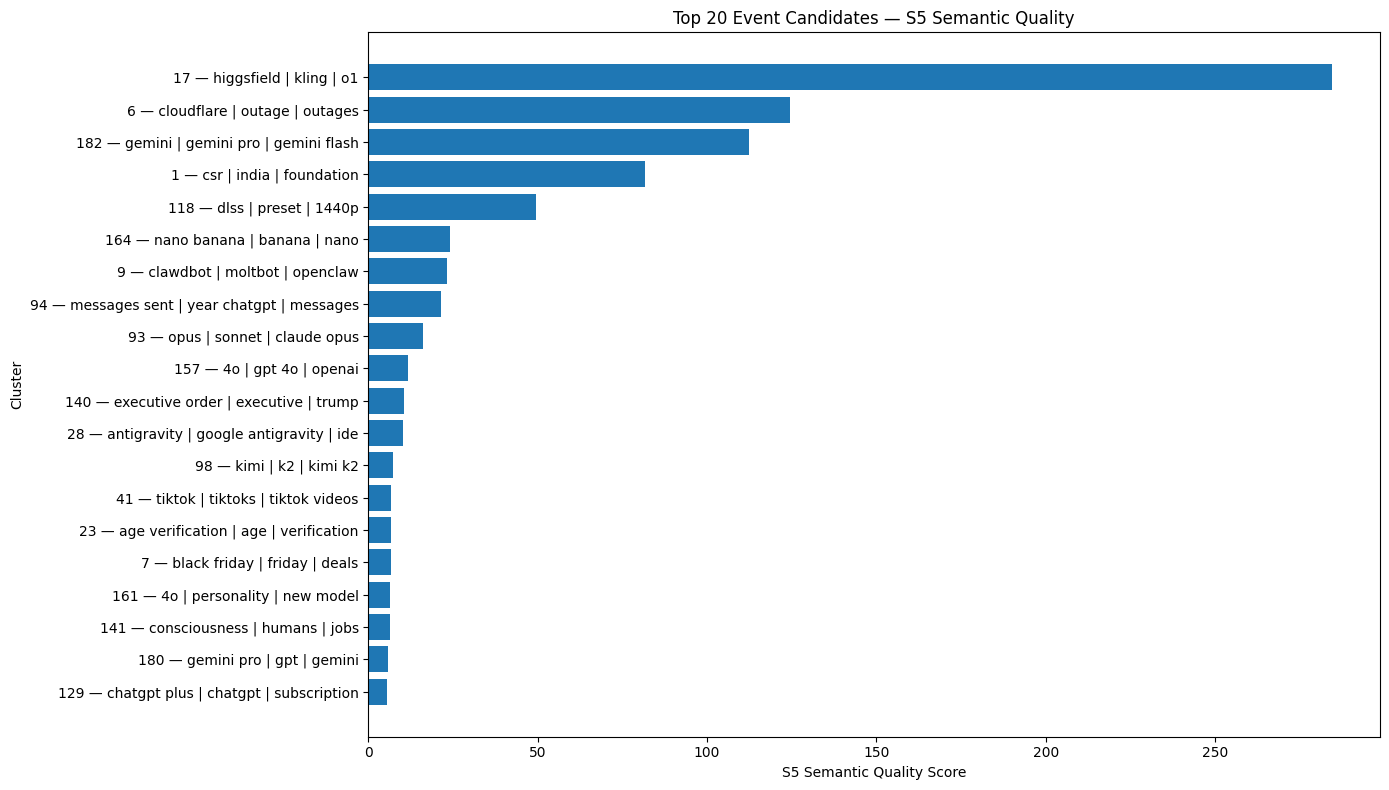

Saved plot: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/plot_top_20_S5_semantic_quality.png


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# S5 EVENT SCORING ONLY
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

POSTS_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
SUMMARY_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_cluster_summary_labeled.csv"
EMBEDDINGS_FILE = BASE_DIR / "reddit_tech_nov_2025_jan_2026_embeddings.npy"

OUTPUT_DIR = BASE_DIR / "outputs" / "s5_scoring"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 20
MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE = 1000

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_parquet(POSTS_FILE)
cluster_summary = pd.read_csv(SUMMARY_FILE)

df["created_dt"] = pd.to_datetime(df["created_dt"], utc=True, errors="coerce")

if "date" not in df.columns:
    df["date"] = df["created_dt"].dt.floor("D")
else:
    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.floor("D")

df_valid = df[df["cluster_id"] != -1].copy()

print("Posts:", df.shape)
print("Assigned posts:", df_valid.shape)
print("Valid clusters:", df_valid["cluster_id"].nunique())

# ============================================================
# BASIC TEMPORAL FEATURES
# ============================================================

cluster_stats = (
    df_valid
    .groupby("cluster_id")
    .agg(
        n_posts=("id", "count"),
        date_start=("date", "min"),
        date_end=("date", "max"),
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean"),
        total_score=("score", "sum"),
        total_comments=("num_comments", "sum")
    )
    .reset_index()
)

daily_counts = (
    df_valid
    .groupby(["cluster_id", "date"])
    .size()
    .reset_index(name="daily_posts")
)

peak_stats = (
    daily_counts
    .sort_values(["cluster_id", "daily_posts"], ascending=[True, False])
    .groupby("cluster_id")
    .head(1)
    .rename(columns={
        "date": "peak_date",
        "daily_posts": "peak_count"
    })
    [["cluster_id", "peak_date", "peak_count"]]
)

daily_stats = (
    daily_counts
    .groupby("cluster_id")
    .agg(
        active_days=("date", "count"),
        mean_daily_posts=("daily_posts", "mean"),
        std_daily_posts=("daily_posts", "std")
    )
    .reset_index()
)

cluster_stats = (
    cluster_stats
    .merge(peak_stats, on="cluster_id", how="left")
    .merge(daily_stats, on="cluster_id", how="left")
)

cluster_stats["std_daily_posts"] = cluster_stats["std_daily_posts"].fillna(0)

cluster_stats["burst_share"] = (
    cluster_stats["peak_count"] / cluster_stats["n_posts"]
)

cluster_stats["peak_prominence"] = (
    cluster_stats["peak_count"] / cluster_stats["mean_daily_posts"]
)

cluster_stats["avg_score"] = cluster_stats["avg_score"].fillna(0).clip(lower=0)
cluster_stats["avg_comments"] = cluster_stats["avg_comments"].fillna(0).clip(lower=0)

cluster_stats["engagement"] = (
    cluster_stats["avg_score"] + cluster_stats["avg_comments"]
)

# ============================================================
# SEMANTIC COHERENCE
# ============================================================

print("Loading embeddings...")
embeddings = np.load(EMBEDDINGS_FILE, mmap_mode="r")
print("Embeddings:", embeddings.shape)

if embeddings.shape[0] != df.shape[0]:
    raise ValueError(
        f"Embeddings rows {embeddings.shape[0]} do not match df rows {df.shape[0]}"
    )

coherence_rows = []
rng = np.random.default_rng(42)

for cluster_id, group in df_valid.groupby("cluster_id"):
    idx = group.index.to_numpy()

    if len(idx) > MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE:
        idx_sample = rng.choice(
            idx,
            size=MAX_SAMPLE_PER_CLUSTER_FOR_COHERENCE,
            replace=False
        )
    else:
        idx_sample = idx

    X = np.asarray(embeddings[idx_sample], dtype=np.float32)
    centroid = X.mean(axis=0, keepdims=True)
    sims = cosine_similarity(X, centroid).ravel()

    coherence_rows.append({
        "cluster_id": cluster_id,
        "semantic_coherence": float(np.mean(sims)),
        "semantic_coherence_std": float(np.std(sims)),
        "coherence_sample_size": len(idx_sample)
    })

coherence_df = pd.DataFrame(coherence_rows)

cluster_stats = cluster_stats.merge(
    coherence_df,
    on="cluster_id",
    how="left"
)

print("Semantic coherence computed.")

# ============================================================
# MERGE LABELS
# ============================================================

label_cols = [
    "cluster_id",
    "interpreted_label_ctfidf",
    "ctfidf_top_terms",
    "top_subreddits",
    "sample_titles"
]

label_cols = [c for c in label_cols if c in cluster_summary.columns]

cluster_stats = cluster_stats.merge(
    cluster_summary[label_cols],
    on="cluster_id",
    how="left"
)

# ============================================================
# S5 SCORING ONLY
# S5 = peak_count * log(1 + n_posts) * burst_share * semantic_coherence
# ============================================================

cluster_stats["S5_semantic_quality"] = (
    cluster_stats["peak_count"] *
    np.log1p(cluster_stats["n_posts"]) *
    cluster_stats["burst_share"] *
    cluster_stats["semantic_coherence"]
)

ranking = (
    cluster_stats
    .sort_values("S5_semantic_quality", ascending=False)
    .reset_index(drop=True)
    .copy()
)

ranking["rank"] = np.arange(1, len(ranking) + 1)

keep_cols = [
    "rank",
    "cluster_id",
    "interpreted_label_ctfidf",
    "n_posts",
    "peak_date",
    "peak_count",
    "burst_share",
    "peak_prominence",
    "semantic_coherence",
    "S5_semantic_quality",
    "ctfidf_top_terms",
    "sample_titles"
]

keep_cols = [c for c in keep_cols if c in ranking.columns]

top_s5 = ranking[keep_cols].head(TOP_K)

# ============================================================
# SAVE OUTPUTS
# ============================================================

full_output = OUTPUT_DIR / "s5_scoring_full.csv"
top_output = OUTPUT_DIR / "top_20_S5_semantic_quality.csv"
validation_output = OUTPUT_DIR / "validation_template_top20_S5.csv"

cluster_stats.to_csv(full_output, index=False)
top_s5.to_csv(top_output, index=False)

validation_template = top_s5.copy()
validation_template["real_world_event_found"] = ""
validation_template["real_world_event_name"] = ""
validation_template["source_url"] = ""
validation_template["match"] = ""
validation_template["notes"] = ""

validation_template.to_csv(validation_output, index=False)

print("Saved:")
print(full_output)
print(top_output)
print(validation_output)

display(top_s5)

# ============================================================
# PLOT TOP 20 S5
# ============================================================

plot_df = top_s5.copy()

plot_labels = (
    plot_df["cluster_id"].astype(str)
    + " — "
    + plot_df["interpreted_label_ctfidf"].fillna("")
)

plt.figure(figsize=(14, 8))
plt.barh(plot_labels, plot_df["S5_semantic_quality"])
plt.gca().invert_yaxis()
plt.xlabel("S5 Semantic Quality Score")
plt.ylabel("Cluster")
plt.title("Top 20 Event Candidates — S5 Semantic Quality")
plt.tight_layout()

plot_output = OUTPUT_DIR / "plot_top_20_S5_semantic_quality.png"
plt.savefig(plot_output, dpi=200)
plt.show()

print("Saved plot:", plot_output)

# STEP 30 — Automatic macro-event deduplication
# Raggruppa cluster S5 che rappresentano lo stesso evento usando overlap delle label (Jaccard) e vicinanza temporale del peak date.

In [ ]:
import pandas as pd
import re
from pathlib import Path
from itertools import combinations

# ==================================================
# CONFIG — NOV 2025 TO JAN 2026
# ==================================================

BASE = Path(
    "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring"
)

FILE = BASE / "S5 validation_november.xlsx"

OUTPUT_FILE = BASE / "S5_validation_november_with_auto_macro_events.xlsx"

# ==================================================
# LOAD VALIDATION FILE
# ==================================================

df = pd.read_excel(FILE)
df.columns = df.columns.str.strip()

df["Peak date"] = pd.to_datetime(
    df["Peak date"],
    errors="coerce"
)

# ==================================================
# NORMALIZE LABELS
# ==================================================

def normalize_label(label):
    label = str(label).lower()
    label = re.sub(r"[^a-z0-9\s|]", " ", label)

    terms = [
        t.strip()
        for t in label.split("|")
    ]

    terms = [
        t for t in terms
        if t
    ]

    return set(terms)


df["label_terms"] = df["Label"].apply(
    normalize_label
)

# ==================================================
# JACCARD SIMILARITY
# ==================================================

def jaccard(a, b):
    if not a or not b:
        return 0

    return len(a & b) / len(a | b)

# ==================================================
# UNION-FIND FOR DUPLICATE MACRO EVENTS
# ==================================================

parent = {
    cluster: cluster
    for cluster in df["Cluster"]
}


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]

    return x


def union(a, b):
    ra, rb = find(a), find(b)

    if ra != rb:
        parent[rb] = ra

# ==================================================
# AUTO MERGE RULE
# ==================================================

for i, j in combinations(df.index, 2):

    row_i = df.loc[i]
    row_j = df.loc[j]

    sim = jaccard(
        row_i["label_terms"],
        row_j["label_terms"]
    )

    date_diff = abs(
        (row_i["Peak date"] - row_j["Peak date"]).days
    )

    same_event_signal = (
        sim >= 0.30
        and date_diff <= 2
    )

    if same_event_signal:
        union(
            row_i["Cluster"],
            row_j["Cluster"]
        )

# ==================================================
# ASSIGN MACRO EVENT ID
# ==================================================

df["auto_macro_event_id"] = df["Cluster"].apply(
    lambda x: f"event_{find(x)}"
)

df_out = df.drop(
    columns=["label_terms"]
)

display(df_out)

# ==================================================
# SAVE
# ==================================================

df_out.to_excel(
    OUTPUT_FILE,
    index=False
)

print("Saved:")
print(OUTPUT_FILE)

,Rank,Cluster,Label,Peak date,Match,Evento reale associato,Reference,auto_macro_event_id
0,1,17,higgsfield | kling | o1,2025-12-02,partial,Higgsfield + Kling O1 video generation wave,https://higgsfield.ai/,event_17
1,2,6,cloudflare | outage | outages,2025-11-18,yes,Cloudflare global outage,https://www.cloudflarestatus.com/,event_6
2,3,182,gemini | gemini pro | gemini flash,2025-11-18,yes,Gemini 3 release,https://blog.google/products/gemini/gemini-3-c...,event_182
3,4,1,csr | india | foundation,2025-11-13,no,NGO/CSR topic (not tech event),NaN,event_1
4,5,118,dlss | preset | 1440p,2026-01-06,yes,NVIDIA DLSS 4.5 / CES 2026 graphics stack,https://www.nvidia.com/en-us/geforce/news/,event_118
5,6,164,nano banana | banana | nano,2025-11-20,yes,Nano Banana Pro release,https://blog.google/innovation-and-ai/products...,event_164
6,7,9,clawdbot | moltbot | openclaw,2026-01-31,no,niche bot/tool discussion,NaN,event_9
7,8,94,messages sent | year chatgpt | messages,2025-12-23,partial,GPT-5.1 usage expansion / quota discussion,https://help.openai.com/en/articles/9624314-mo...,event_94
8,9,93,opus | sonnet | claude opus,2025-11-25,yes,Claude Opus 4.5 release,https://www.anthropic.com/news/claude-opus-4-5,event_93
9,10,157,4o | gpt 4o | openai,2026-01-30,partial,GPT-4o ecosystem updates,https://openai.com/,event_157


Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/S5_validation_november_with_auto_macro_events.xlsx


# STEP 31 — Create deduplicated S5 event table
# Filtra eventi validi, rimuove duplicati per macro-evento e genera la tabella finale ordinata dei macro-eventi scoperti.

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring"
)

INPUT_FILE = BASE / "S5_validation_november_with_auto_macro_events.xlsx"

OUTPUT_FILE = BASE / "S5_deduplicated_table.xlsx"

df = pd.read_excel(INPUT_FILE)

# normalize match labels
df["Match_clean"] = (
    df["Match"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# keep only real matches
valid_matches = [
    "yes",
    "partial",
    "yes, but non-tech"
]

df_valid = df[
    df["Match_clean"].isin(valid_matches)
].copy()

# deduplicate macro-events
df_dedup = (
    df_valid
    .sort_values("Rank")
    .drop_duplicates(
        subset=["auto_macro_event_id"],
        keep="first"
    )
)

# reorder
df_dedup = (
    df_dedup
    .sort_values("Rank")
    .reset_index(drop=True)
)

# rebuild ranking
df_dedup["New Rank"] = range(
    1,
    len(df_dedup) + 1
)

# final output table
final_cols = [
    "New Rank",
    "Cluster",
    "Label",
    "Peak date",
    "Match",
    "Evento reale associato",
    "Reference",
    "auto_macro_event_id"
]

final_cols = [
    c for c in final_cols
    if c in df_dedup.columns
]

final_table = df_dedup[final_cols]

display(final_table)

final_table.to_excel(
    OUTPUT_FILE,
    index=False
)

print("Saved:")
print(OUTPUT_FILE)

,New Rank,Cluster,Label,Peak date,Match,Evento reale associato,Reference,auto_macro_event_id
0,1,17,higgsfield | kling | o1,2025-12-02,partial,Higgsfield + Kling O1 video generation wave,https://higgsfield.ai/,event_17
1,2,6,cloudflare | outage | outages,2025-11-18,yes,Cloudflare global outage,https://www.cloudflarestatus.com/,event_6
2,3,182,gemini | gemini pro | gemini flash,2025-11-18,yes,Gemini 3 release,https://blog.google/products/gemini/gemini-3-c...,event_182
3,4,118,dlss | preset | 1440p,2026-01-06,yes,NVIDIA DLSS 4.5 / CES 2026 graphics stack,https://www.nvidia.com/en-us/geforce/news/,event_118
4,5,164,nano banana | banana | nano,2025-11-20,yes,Nano Banana Pro release,https://blog.google/innovation-and-ai/products...,event_164
5,6,94,messages sent | year chatgpt | messages,2025-12-23,partial,GPT-5.1 usage expansion / quota discussion,https://help.openai.com/en/articles/9624314-mo...,event_94
6,7,93,opus | sonnet | claude opus,2025-11-25,yes,Claude Opus 4.5 release,https://www.anthropic.com/news/claude-opus-4-5,event_93
7,8,157,4o | gpt 4o | openai,2026-01-30,partial,GPT-4o ecosystem updates,https://openai.com/,event_157
8,9,28,antigravity | google antigravity | ide,2025-11-18,yes,Google Antigravity launch,https://blog.google/products/gemini/gemini-3-c...,event_28
9,10,98,kimi | k2 | kimi k2,2026-01-27,yes,Kimi K2.5 release,https://platform.moonshot.ai/,event_98


Saved:
/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/S5_deduplicated_table.xlsx


# STEP 32 — Deduplicated S5 evaluation metrics
# Calcola metriche finali dopo deduplicazione (unique events, precision@20, strict precision, noise ratio) sui macro-eventi.

In [ ]:
import pandas as pd

PATH = "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/S5_validation_november_with_auto_macro_events.xlsx"

df = pd.read_excel(PATH)

# normalize
df["Match_clean"] = df["Match"].str.lower().str.strip()

# strict matches
strict_yes = df["Match_clean"] == "yes"

# valid event matches
valid_matches = df["Match_clean"].isin([
    "yes",
    "partial",
    "yes, but non-tech"
])

# unique macro events
unique_events = df.loc[valid_matches, "auto_macro_event_id"].nunique()

# metrics
precision_20 = unique_events / 20
strict_precision = strict_yes.sum() / 20
noise_ratio = (~valid_matches).sum() / 20

results = pd.DataFrame({
    "unique_events": [unique_events],
    "precision@20_deduplicated": [precision_20],
    "strict_precision@20": [strict_precision],
    "noise_ratio": [noise_ratio]
})

print(results)

save_path = "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/S5_deduplicated_metrics.csv"

results.to_csv(save_path, index=False)

print("Saved:", save_path)

   unique_events  precision@20_deduplicated  strict_precision@20  noise_ratio
0             12                        0.6                 0.35          0.4
Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/S5_deduplicated_metrics.csv


# STEP 33 — Before/after deduplication comparison
# Confronta S5 prima e dopo la deduplicazione automatica: precision@20, noise ratio, duplicate ratio e unique events.

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring"
)

INPUT_FILE = BASE / "S5_validation_november_with_auto_macro_events.xlsx"

df = pd.read_excel(INPUT_FILE)
df.columns = df.columns.str.strip()

df["Match_clean"] = (
    df["Match"]
    .astype(str)
    .str.lower()
    .str.strip()
)

TOTAL = len(df)

# =========================
# categories
# =========================

strict_true = df["Match_clean"] == "yes"

partial_true = df["Match_clean"].str.contains(
    "partial",
    na=False
)

duplicates = df["Match_clean"].str.contains(
    "duplicate",
    na=False
)

noise = (
    df["Match_clean"].str.contains("no", na=False)
    |
    df["Match_clean"].str.contains("non-tech", na=False)
)

valid = strict_true | partial_true

# =========================
# BEFORE
# =========================

before_precision = valid.sum() / TOTAL
before_noise_ratio = noise.sum() / TOTAL
before_duplicate_ratio = duplicates.sum() / TOTAL

before_unique = df.loc[
    valid,
    "auto_macro_event_id"
].nunique()

# =========================
# AFTER DEDUP
# =========================

dedup = (
    df[valid]
    .sort_values("Rank")
    .drop_duplicates(
        subset=["auto_macro_event_id"]
    )
)

after_precision = len(dedup) / TOTAL
after_noise_ratio = noise.sum() / TOTAL
after_duplicate_ratio = 0

after_unique = dedup[
    "auto_macro_event_id"
].nunique()

# =========================
# output
# =========================

results = pd.DataFrame({
    "stage": ["before", "after"],
    "precision@20": [
        before_precision,
        after_precision
    ],
    "noise_ratio": [
        before_noise_ratio,
        after_noise_ratio
    ],
    "duplicate_ratio": [
        before_duplicate_ratio,
        after_duplicate_ratio
    ],
    "unique_events": [
        before_unique,
        after_unique
    ]
})

display(results)

,stage,precision@20,noise_ratio,duplicate_ratio,unique_events
0,before,0.6,0.3,0.1,12
1,after,0.6,0.3,0.0,12


# STEP 34 — Macro-event lifecycle analysis
# Aggrega i cluster deduplicati in macro-eventi, calcola volume/peak/top terms e genera plot temporali per ogni macro-evento.

(140669, 10)
   Rank  Cluster                               Label  Peak date    Match  \
0     1       17             higgsfield | kling | o1 2025-12-02  partial   
1     2        6       cloudflare | outage | outages 2025-11-18      yes   
2     3      182  gemini | gemini pro | gemini flash 2025-11-18      yes   
3     4        1            csr | india | foundation 2025-11-13       no   
4     5      118               dlss | preset | 1440p 2026-01-06      yes   

                        Evento reale associato  \
0  Higgsfield + Kling O1 video generation wave   
1                     Cloudflare global outage   
2                             Gemini 3 release   
3               NGO/CSR topic (not tech event)   
4    NVIDIA DLSS 4.5 / CES 2026 graphics stack   

                                           Reference auto_macro_event_id  
0                             https://higgsfield.ai/            event_17  
1                  https://www.cloudflarestatus.com/             event_6  
2  h

,auto_macro_event_id,clusters,labels,event_name,reference
0,event_118,[118],dlss | preset | 1440p,NVIDIA DLSS 4.5 / CES 2026 graphics stack,https://www.nvidia.com/en-us/geforce/news/
1,event_129,[129],chatgpt plus | chatgpt | subscription,ChatGPT subscription/product updates,https://openai.com/chatgpt/pricing/
2,event_157,[157],4o | gpt 4o | openai,GPT-4o ecosystem updates,https://openai.com/
3,event_161,[161],4o | personality | new model,Same GPT-5.1 family rollout,https://openai.com/index/gpt-5-1/
4,event_164,[164],nano banana | banana | nano,Nano Banana Pro release,https://blog.google/innovation-and-ai/products...
5,event_17,[17],higgsfield | kling | o1,Higgsfield + Kling O1 video generation wave,https://higgsfield.ai/
6,event_182,"[182, 180]",gemini | gemini pro | gemini flash || gemini p...,Gemini 3 release,https://blog.google/products/gemini/gemini-3-c...
7,event_28,[28],antigravity | google antigravity | ide,Google Antigravity launch,https://blog.google/products/gemini/gemini-3-c...
8,event_6,[6],cloudflare | outage | outages,Cloudflare global outage,https://www.cloudflarestatus.com/
9,event_7,[7],black friday | friday | deals,Black Friday software deals,https://www.adobe.com/blackfriday.html


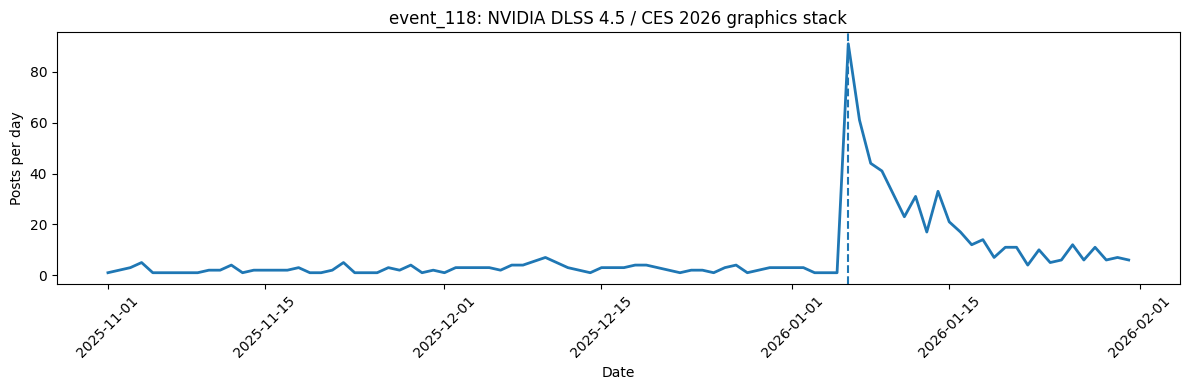

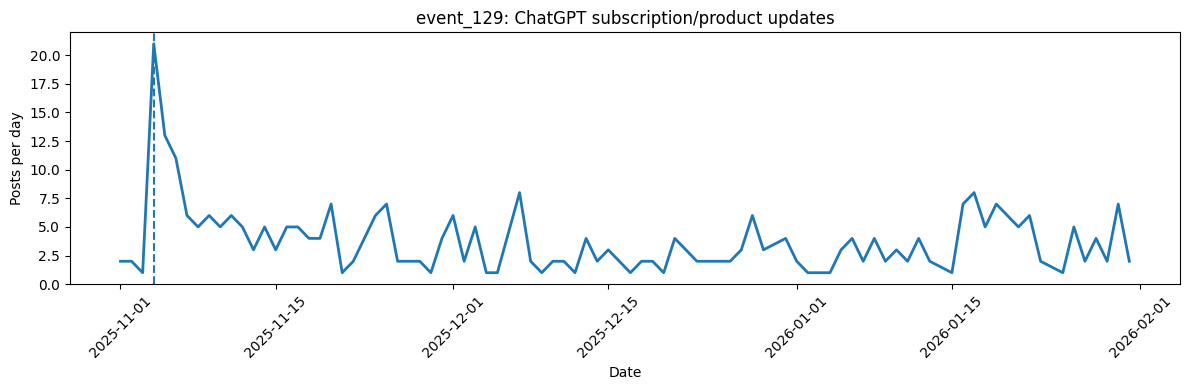

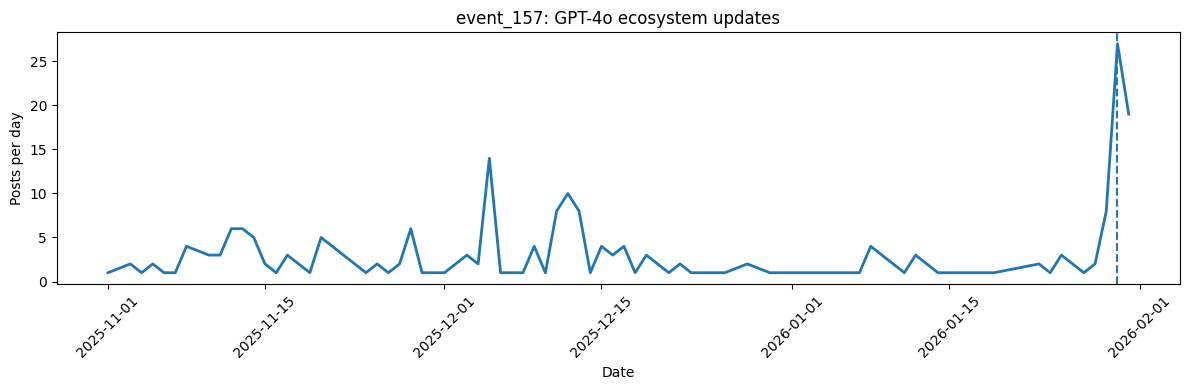

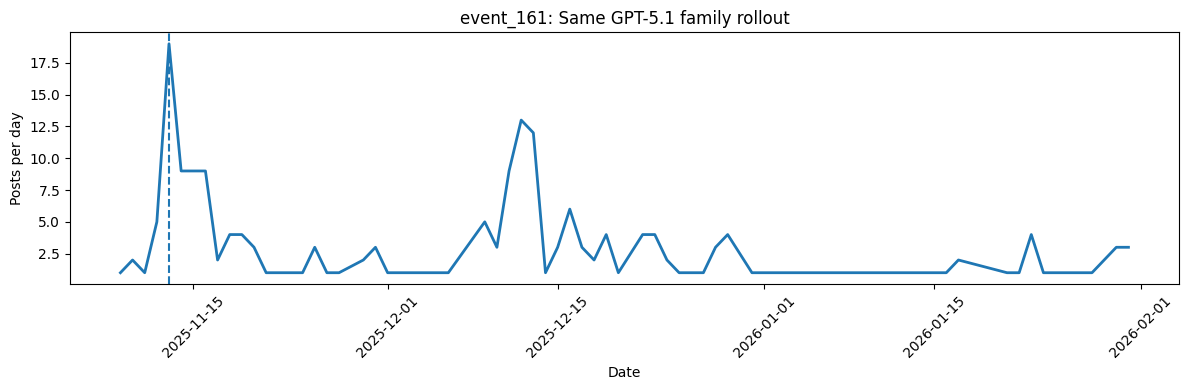

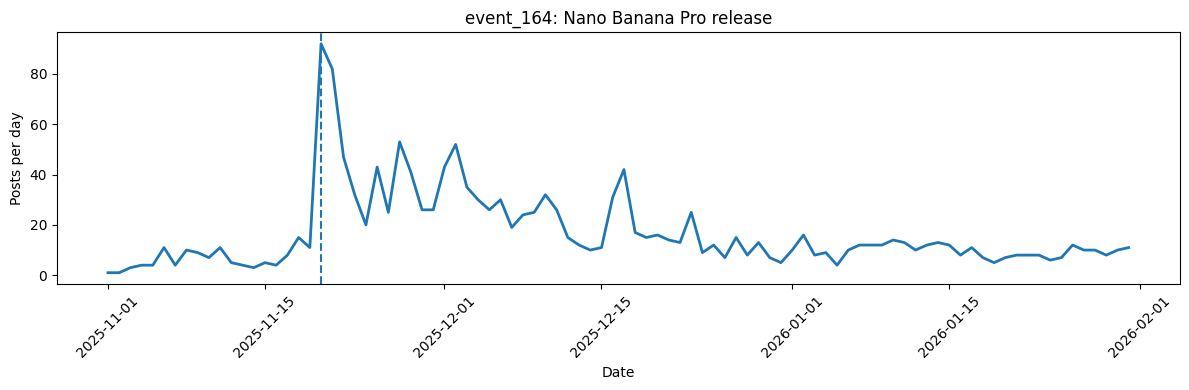

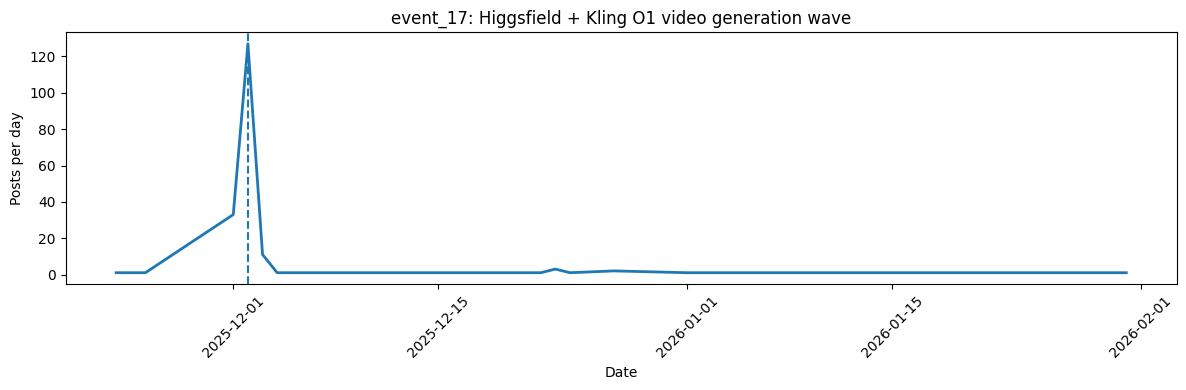

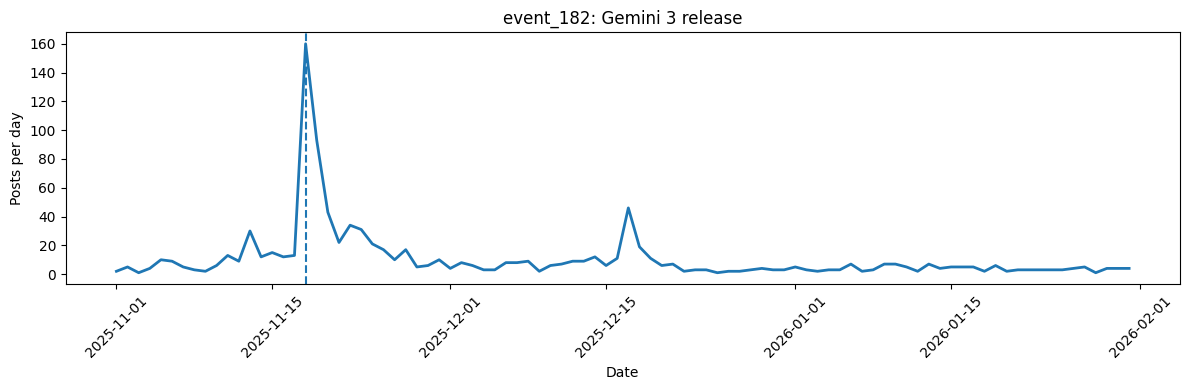

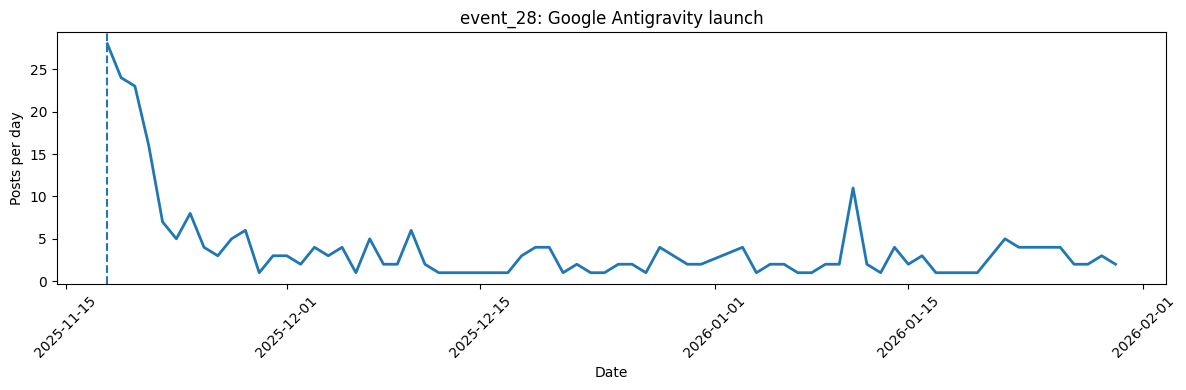

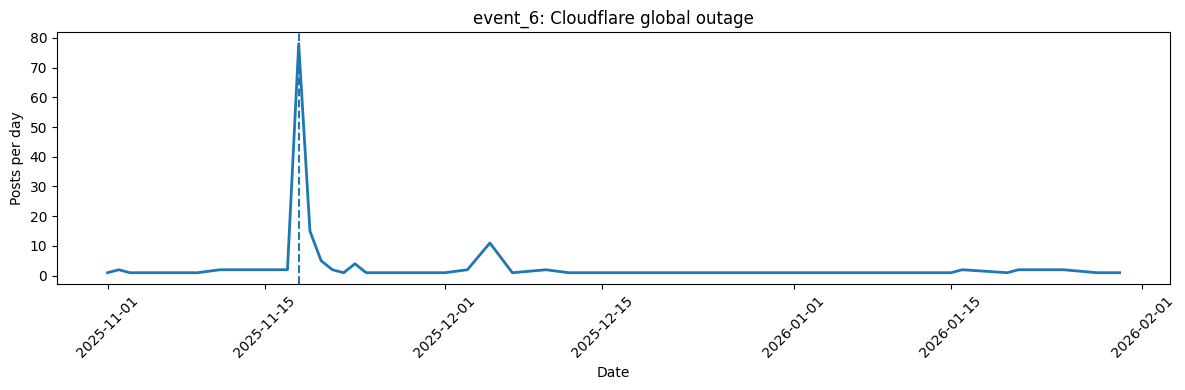

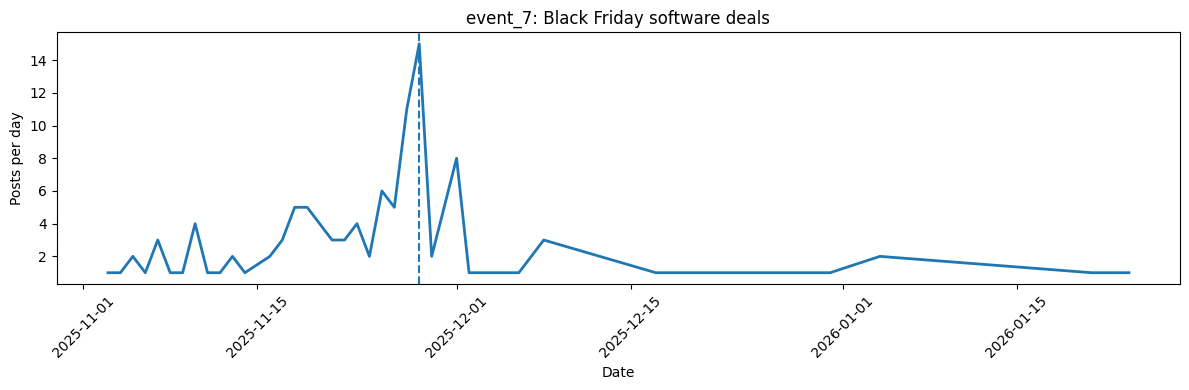

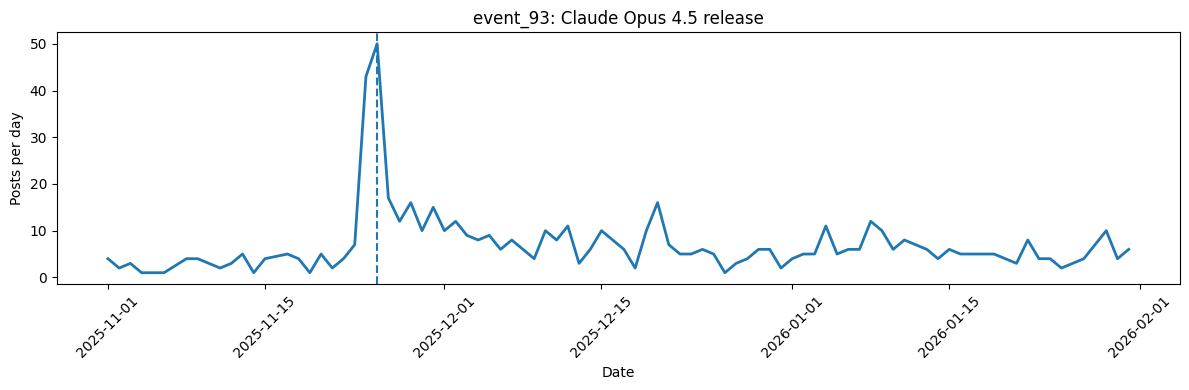

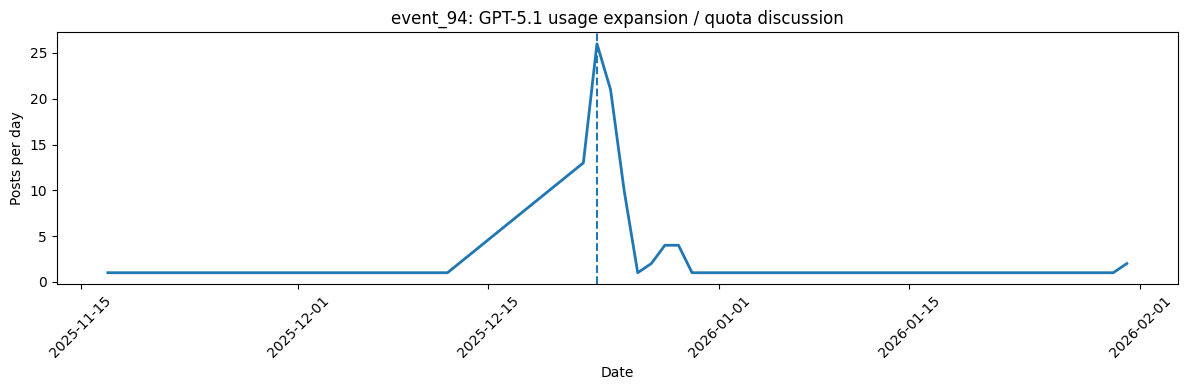

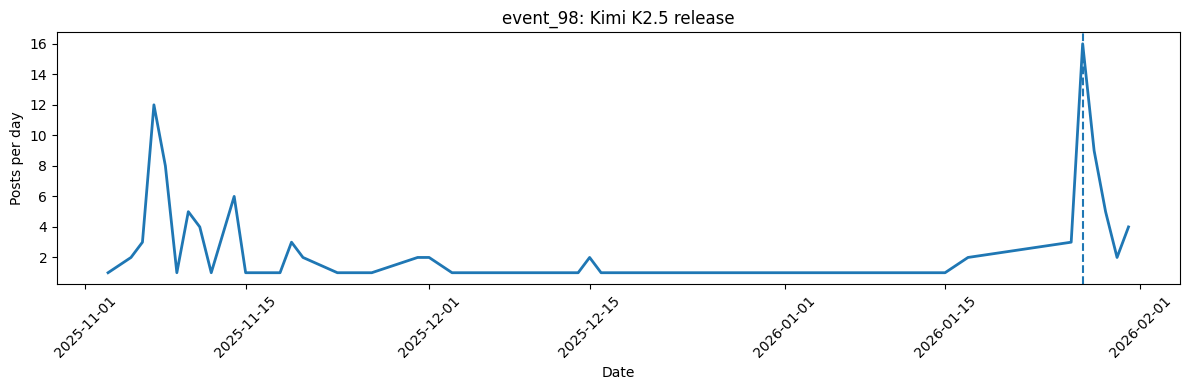

,macro_event_id,clusters,n_clusters,n_posts,peak_date,peak_count,event_name,top_terms
0,event_118,[118],1,680,2026-01-06 00:00:00+00:00,91,NVIDIA DLSS 4.5 / CES 2026 graphics stack,"dlss, preset, performance, quality, 4k, nvidia..."
1,event_129,[129],1,317,2025-11-04 00:00:00+00:00,21,ChatGPT subscription/product updates,"free, plus, subscription, chatgpt plus, month,..."
2,event_157,[157],1,220,2026-01-30 00:00:00+00:00,27,GPT-4o ecosystem updates,"4o, gpt, openai, just, gpt 4o, model, like, us..."
3,event_161,[161],1,193,2025-11-13 00:00:00+00:00,19,Same GPT-5.1 family rollout,"like, just, model, 4o, new, does, think, don, ..."
4,event_164,[164],1,1549,2025-11-20 00:00:00+00:00,92,Nano Banana Pro release,"nano banana, pro, banana pro, nano banana pro,..."
5,event_17,[17],1,194,2025-12-02 00:00:00+00:00,127,Higgsfield + Kling O1 video generation wave,"o1, kling o1, o1 higgsfield, kling o1 higgsfie..."
6,event_182,"[182, 180]",2,968,2025-11-18 00:00:00+00:00,160,Gemini 3 release,"pro, gemini pro, flash, google, gemini flash, ..."
7,event_28,[28],1,272,2025-11-18 00:00:00+00:00,28,Google Antigravity launch,"google, gemini, google antigravity, claude, id..."
8,event_6,[6],1,161,2025-11-18 00:00:00+00:00,78,Cloudflare global outage,"outage, cloudflare outage, chatgpt, internet, ..."
9,event_7,[7],1,112,2025-11-28 00:00:00+00:00,15,Black Friday software deals,"deals, deal, best, saas, cyber monday, cyber, ..."


Saved: /content/drive/MyDrive/AI_project/nov_2025_jan_2026_test/outputs/s5_scoring/macro_event_analysis/macro_event_summary.csv


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

BASE = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

POSTS_FILE = BASE / "reddit_tech_nov_2025_jan_2026_posts_with_clusters.parquet"
VALIDATION_FILE = BASE / "outputs/s5_scoring/S5_validation_november_with_auto_macro_events.xlsx"

OUTPUT_DIR = BASE / "outputs/s5_scoring/macro_event_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

posts = pd.read_parquet(POSTS_FILE)
validation = pd.read_excel(VALIDATION_FILE)

posts["date"] = pd.to_datetime(posts["date"], utc=True, errors="coerce").dt.floor("D")
validation["Peak date"] = pd.to_datetime(validation["Peak date"], errors="coerce")

print(posts.shape)
print(validation.head())

# Keep useful event candidates only
validation["Match_clean"] = validation["Match"].astype(str).str.lower().str.strip()

event_candidates = validation[
    ~validation["Match_clean"].str.contains("no", na=False)
].copy()

# Group clusters by automatic macro-event
macro_events = (
    event_candidates
    .groupby("auto_macro_event_id")
    .agg(
        clusters=("Cluster", lambda x: list(x)),
        labels=("Label", lambda x: " || ".join(x.astype(str))),
        event_name=("Evento reale associato", "first"),
        reference=("Reference", "first")
    )
    .reset_index()
)

display(macro_events)

# Function: top TF-IDF terms inside a set of clusters
def get_top_terms_for_clusters(cluster_ids, top_k=15):
    subset = posts[posts["cluster_id"].isin(cluster_ids)].copy()
    texts = subset["text_for_embedding"].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 3),
        min_df=3,
        max_df=0.8
    )

    X = vectorizer.fit_transform(texts)
    terms = vectorizer.get_feature_names_out()

    scores = X.mean(axis=0).A1
    top_idx = scores.argsort()[-top_k:][::-1]

    return [(terms[i], scores[i]) for i in top_idx], subset

summary_rows = []

for _, row in macro_events.iterrows():
    macro_id = row["auto_macro_event_id"]
    cluster_ids = row["clusters"]

    top_terms, subset = get_top_terms_for_clusters(cluster_ids)

    daily = (
        subset.groupby("date")
        .size()
        .reset_index(name="n_posts")
        .sort_values("date")
    )

    peak_row = daily.loc[daily["n_posts"].idxmax()]

    summary_rows.append({
        "macro_event_id": macro_id,
        "clusters": cluster_ids,
        "n_clusters": len(cluster_ids),
        "n_posts": len(subset),
        "peak_date": peak_row["date"],
        "peak_count": int(peak_row["n_posts"]),
        "event_name": row["event_name"],
        "top_terms": ", ".join([t for t, s in top_terms[:10]])
    })

    # Plot lifecycle
    plt.figure(figsize=(12, 4))
    plt.plot(daily["date"], daily["n_posts"], linewidth=2)
    plt.axvline(peak_row["date"], linestyle="--")
    plt.title(f"{macro_id}: {row['event_name']}")
    plt.xlabel("Date")
    plt.ylabel("Posts per day")
    plt.xticks(rotation=45)
    plt.tight_layout()

    out_plot = OUTPUT_DIR / f"lifecycle_{macro_id}.png"
    plt.savefig(out_plot, dpi=200)
    plt.show()

summary = pd.DataFrame(summary_rows)

display(summary)

summary.to_csv(
    OUTPUT_DIR / "macro_event_summary.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "macro_event_summary.csv")

# STEP 35 — External event full-rank coverage check
# Cerca eventi tecnologici noti in tutti i 227 cluster usando label/terms/sample titles, confrontando il rank sotto S1–S5 per analisi di recall e false negatives.

In [ ]:
from pathlib import Path
import pandas as pd
import re

# ============================================================
# CONFIG
# ============================================================

BASE = Path("/content/drive/MyDrive/AI_project")
SCORING_FILE = BASE / "outputs/scoring_ablation/event_scoring_ablation_full.csv"
OUTPUT_DIR = BASE / "outputs/evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_cols = {
    "S1_baseline": "S1_baseline",
    "S2_burst_aware": "S2_burst_aware",
    "S3_engagement_aware": "S3_engagement_aware",
    "S4_full_metadata": "S4_full_metadata",
    "S5_semantic_quality": "S5_semantic_quality",
}

external_events = [
    {
        "event_name": "OpenAI GPT-OSS / open-weight model discussion",
        "category": "AI / Models",
        "keywords": ["gpt oss", "gpt-oss", "oss", "open weight", "open-weight", "open source"],
    },
    {
        "event_name": "Gemini for Home launch",
        "category": "Smart Home / AI",
        "keywords": ["gemini home", "google home", "nest"],
    },
    {
        "event_name": "Copilot ecosystem event",
        "category": "Developer Tools / AI",
        "keywords": ["copilot", "github copilot", "microsoft copilot"],
    },
    {
        "event_name": "Meta AI / Meta Connect ecosystem event",
        "category": "Consumer Tech / AI",
        "keywords": ["meta", "llama", "connect", "ray-ban", "quest"],
    },
    {
        "event_name": "xAI / Grok ecosystem event",
        "category": "AI / Models",
        "keywords": ["xai", "grok", "elon"],
    },
    {
        "event_name": "Android ecosystem event",
        "category": "Mobile OS",
        "keywords": ["android", "play store", "apk", "apks"],
    },
    {
        "event_name": "Google AI Mode / Search AI rollout",
        "category": "Search / AI",
        "keywords": ["ai mode", "google search", "search bar", "safari"],
    },
    {
        "event_name": "NVIDIA infrastructure / GTC-related news",
        "category": "Chips / AI Infrastructure",
        "keywords": ["nvidia", "blackwell", "oracle", "supercomputer", "palantir", "nokia"],
    },
]

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(SCORING_FILE)

print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

def normalize_text(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z0-9\s\-\|]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# Search only in existing columns
df["label_norm"] = df["interpreted_label_ctfidf"].fillna("").apply(normalize_text)
df["terms_norm"] = df["ctfidf_top_terms"].fillna("").apply(normalize_text)
df["titles_norm"] = df["sample_titles"].fillna("").apply(normalize_text)

df["search_text"] = (
    df["label_norm"] + " " +
    df["terms_norm"] + " " +
    df["titles_norm"]
)

# ============================================================
# FULL RANKS
# ============================================================

for score_name, score_col in score_cols.items():
    rank_col = f"rank_{score_name}"
    df[rank_col] = df[score_col].rank(
        ascending=False,
        method="min"
    ).astype(int)

# ============================================================
# SEARCH ALL CLUSTERS
# ============================================================

rows = []
detailed_matches = []

for event in external_events:
    event_name = event["event_name"]
    category = event["category"]
    keywords = event["keywords"]

    event_matches = []

    for kw in keywords:
        kw_norm = normalize_text(kw)

        m = df[
            df["search_text"].str.contains(kw_norm, case=False, na=False)
        ].copy()

        if len(m) > 0:
            m["matched_keyword"] = kw
            event_matches.append(m)

    if event_matches:
        matches = pd.concat(event_matches, ignore_index=True)
        matches = matches.drop_duplicates(subset=["cluster_id"])

        best_info = {}

        for score_name in score_cols.keys():
            rank_col = f"rank_{score_name}"
            best_row = matches.sort_values(rank_col).iloc[0]

            best_info[f"best_rank_{score_name}"] = int(best_row[rank_col])
            best_info[f"best_cluster_{score_name}"] = int(best_row["cluster_id"])
            best_info[f"best_label_{score_name}"] = best_row["interpreted_label_ctfidf"]

        all_rank_cols = [f"rank_{s}" for s in score_cols.keys()]
        matches["overall_best_rank"] = matches[all_rank_cols].min(axis=1)
        overall_best = matches.sort_values("overall_best_rank").iloc[0]

        rows.append({
            "event_name": event_name,
            "category": category,
            "detected_in_all_clusters": True,
            "overall_best_rank": int(overall_best["overall_best_rank"]),
            "overall_best_cluster": int(overall_best["cluster_id"]),
            "overall_best_label": overall_best["interpreted_label_ctfidf"],
            "matched_keyword": overall_best["matched_keyword"],
            **best_info
        })

        for _, r in matches.iterrows():
            detailed_matches.append({
                "event_name": event_name,
                "category": category,
                "cluster_id": int(r["cluster_id"]),
                "label": r["interpreted_label_ctfidf"],
                "matched_keyword": r["matched_keyword"],
                "rank_S1": int(r["rank_S1_baseline"]),
                "rank_S2": int(r["rank_S2_burst_aware"]),
                "rank_S3": int(r["rank_S3_engagement_aware"]),
                "rank_S4": int(r["rank_S4_full_metadata"]),
                "rank_S5": int(r["rank_S5_semantic_quality"]),
                "n_posts": int(r["n_posts"]),
                "peak_date": r["peak_date"],
                "peak_count": int(r["peak_count"]),
                "burst_share": r["burst_share"],
                "engagement": r["engagement"],
                "semantic_coherence": r["semantic_coherence"],
            })

    else:
        rows.append({
            "event_name": event_name,
            "category": category,
            "detected_in_all_clusters": False,
            "overall_best_rank": None,
            "overall_best_cluster": None,
            "overall_best_label": None,
            "matched_keyword": None,
        })

summary = pd.DataFrame(rows)
details = pd.DataFrame(detailed_matches)

summary_path = OUTPUT_DIR / "external_events_all_clusters_rank_check.csv"
details_path = OUTPUT_DIR / "external_events_all_clusters_detailed_matches.csv"

summary.to_csv(summary_path, index=False)
details.to_csv(details_path, index=False)

print("Saved:", summary_path)
print("Saved:", details_path)

display(summary)

print("\nDETAILED MATCHES:")
display(details.sort_values(["event_name", "rank_S5"]).head(100))

Loaded: (227, 28)
Columns: ['cluster_id', 'n_posts', 'date_start', 'date_end', 'avg_score', 'avg_comments', 'total_score', 'total_comments', 'peak_date', 'peak_count', 'active_days', 'mean_daily_posts', 'std_daily_posts', 'burst_share', 'peak_prominence', 'engagement', 'semantic_coherence', 'semantic_coherence_std', 'coherence_sample_size', 'interpreted_label_ctfidf', 'ctfidf_top_terms', 'top_subreddits', 'sample_titles', 'S1_baseline', 'S2_burst_aware', 'S3_engagement_aware', 'S4_full_metadata', 'S5_semantic_quality']
Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/external_events_all_clusters_rank_check.csv
Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/external_events_all_clusters_detailed_matches.csv


,event_name,category,detected_in_all_clusters,overall_best_rank,overall_best_cluster,overall_best_label,matched_keyword,best_rank_S1_baseline,best_cluster_S1_baseline,best_label_S1_baseline,...,best_label_S2_burst_aware,best_rank_S3_engagement_aware,best_cluster_S3_engagement_aware,best_label_S3_engagement_aware,best_rank_S4_full_metadata,best_cluster_S4_full_metadata,best_label_S4_full_metadata,best_rank_S5_semantic_quality,best_cluster_S5_semantic_quality,best_label_S5_semantic_quality
0,OpenAI GPT-OSS / open-weight model discussion,AI / Models,True,2,172,4o | openai | gpt,open weight,2,172,4o | openai | gpt,...,4o | openai | gpt,2,172,4o | openai | gpt,3,172,4o | openai | gpt,3,172,4o | openai | gpt
1,Gemini for Home launch,Smart Home / AI,True,36,155,magsafe | iphone 17 | 17 pro,nest,36,155,magsafe | iphone 17 | 17 pro,...,magsafe | iphone 17 | 17 pro,56,155,magsafe | iphone 17 | 17 pro,61,155,magsafe | iphone 17 | 17 pro,41,155,magsafe | iphone 17 | 17 pro
2,Copilot ecosystem event,Developer Tools / AI,True,49,34,deepseek | deepseek v3 | v3,copilot,100,34,deepseek | deepseek v3 | v3,...,deepseek | deepseek v3 | v3,75,34,deepseek | deepseek v3 | v3,49,34,deepseek | deepseek v3 | v3,54,34,deepseek | deepseek v3 | v3
3,Meta AI / Meta Connect ecosystem event,Consumer Tech / AI,True,7,124,image | chatgpt | asked chatgpt,quest,7,176,python | java | dsa,...,sora | cameo | sora2,7,124,image | chatgpt | asked chatgpt,10,7,sora | cameo | sora2,11,7,sora | cameo | sora2
4,xAI / Grok ecosystem event,AI / Models,True,42,16,grok | elon | musk,xai,58,16,grok | elon | musk,...,grok | elon | musk,46,16,grok | elon | musk,42,16,grok | elon | musk,45,16,grok | elon | musk
5,Android ecosystem event,Mobile OS,True,55,63,android | play store | apks,android,71,63,android | play store | apks,...,ocr | deepseek | vlm,55,63,android | play store | apks,65,63,android | play store | apks,57,37,ocr | deepseek | vlm
6,Google AI Mode / Search AI rollout,Search / AI,True,21,51,antitrust | lawsuit | suspension,google search,40,90,nvidia | amd | openai,...,antitrust | lawsuit | suspension,33,90,nvidia | amd | openai,21,51,antitrust | lawsuit | suspension,29,189,gpt | gpt5 | gpt ai
7,NVIDIA infrastructure / GTC-related news,Chips / AI Infrastructure,True,14,89,nvidia | china | chips,nvidia,40,90,nvidia | amd | openai,...,nvidia | china | chips,33,90,nvidia | amd | openai,14,89,nvidia | china | chips,16,89,nvidia | china | chips



DETAILED MATCHES:


,event_name,category,cluster_id,label,matched_keyword,rank_S1,rank_S2,rank_S3,rank_S4,rank_S5,n_posts,peak_date,peak_count,burst_share,engagement,semantic_coherence
93,Android ecosystem event,Mobile OS,37,ocr | deepseek | vlm,android,117,62,114,69,57,119,2025-10-22 00:00:00+00:00,10,0.084034,37.672269,0.667860
96,Android ecosystem event,Mobile OS,63,android | play store | apks,android,71,75,55,65,79,258,2025-08-28 00:00:00+00:00,12,0.046512,207.686047,0.583312
98,Android ecosystem event,Mobile OS,136,iphone | android | pixel,android,93,120,87,97,112,283,2025-09-20 00:00:00+00:00,10,0.035336,62.749117,0.668920
92,Android ecosystem event,Mobile OS,36,music | spotify | apple music,android,96,110,79,88,117,258,2025-08-05 00:00:00+00:00,10,0.038760,103.872093,0.576035
100,Android ecosystem event,Mobile OS,203,codex | codex cli | gpt codex,android,158,133,143,125,121,132,2025-09-12 00:00:00+00:00,7,0.053030,33.848485,0.662799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,OpenAI GPT-OSS / open-weight model discussion,AI / Models,203,codex | codex cli | gpt codex,gpt oss,158,133,143,125,121,132,2025-09-12 00:00:00+00:00,7,0.053030,33.848485,0.662799
3,OpenAI GPT-OSS / open-weight model discussion,AI / Models,17,mouse | keyboard | macro,oss,98,100,107,100,123,231,2025-08-20 00:00:00+00:00,10,0.043290,27.822511,0.500031
6,OpenAI GPT-OSS / open-weight model discussion,AI / Models,39,podcast | podcasts | ai news,oss,187,143,219,201,130,102,2025-10-01 00:00:00+00:00,6,0.058824,4.470588,0.677684
36,OpenAI GPT-OSS / open-weight model discussion,AI / Models,148,open source | source projects | open source pr...,open source,86,135,97,132,135,328,2025-08-07 00:00:00+00:00,10,0.030488,32.079268,0.608743


# STEP 36 — External event positioning summary
# Classifica gli eventi esterni trovati in base al rank S5 (top20/top50/top100) e salva una tabella finale di coverage.

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

summary = pd.read_csv(
    BASE / "outputs/evaluation/external_events_all_clusters_rank_check.csv"
)

def top_bucket(rank):
    if pd.isna(rank):
        return "not_found"
    rank = int(rank)

    if rank <= 20:
        return "top20"
    elif rank <= 50:
        return "top50"
    elif rank <= 100:
        return "top100"
    else:
        return "below100"

final = summary.copy()

final["in_top20"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 20
)

final["in_top50"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 50
)

final["in_top100"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 100
)

final["rank_bucket"] = final["best_rank_S5_semantic_quality"].apply(top_bucket)

final["status"] = final.apply(
    lambda row:
    "detected"
    if row["detected_in_all_clusters"] else "missed",
    axis=1
)

final = final[
    [
        "event_name",
        "detected_in_all_clusters",
        "best_cluster_S5_semantic_quality",
        "best_label_S5_semantic_qualityimport pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/AI_project/nov_2025_jan_2026_test")

summary = pd.read_csv(
    BASE / "outputs/evaluation/external_events_all_clusters_rank_check.csv"
)

def top_bucket(rank):
    if pd.isna(rank):
        return "not_found"
    rank = int(rank)

    if rank <= 20:
        return "top20"
    elif rank <= 50:
        return "top50"
    elif rank <= 100:
        return "top100"
    else:
        return "below100"

final = summary.copy()

final["in_top20"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 20
)

final["in_top50"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 50
)

final["in_top100"] = final["best_rank_S5_semantic_quality"].apply(
    lambda x: False if pd.isna(x) else int(x) <= 100
)

final["rank_bucket"] = final["best_rank_S5_semantic_quality"].apply(top_bucket)

final["status"] = final.apply(
    lambda row:
    "detected"
    if row["detected_in_all_clusters"] else "missed",
    axis=1
)

final = final[
    [
        "event_name",
        "detected_in_all_clusters",
        "best_cluster_S5_semantic_quality",
        "best_label_S5_semantic_quality",
        "best_rank_S5_semantic_quality",
        "in_top20",
        "in_top50",
        "in_top100",
        "rank_bucket",
        "status"
    ]
]

output = BASE / "outputs/evaluation/final_external_event_positioning.csv"
final.to_csv(output, index=False)

print("Saved:", output)

display(final)

print("\nSUMMARY")
print("External events:", len(final))
print("Detected:", (final["status"] == "detected").sum())
print("Missed:", (final["status"] == "missed").sum())",
        "best_rank_S5_semantic_quality",
        "in_top20",
        "in_top50",
        "in_top100",
        "rank_bucket",
        "status"
    ]
]

output = BASE / "outputs/evaluation/final_external_event_positioning.csv"
final.to_csv(output, index=False)

print("Saved:", output)

display(final)

print("\nSUMMARY")
print("External events:", len(final))
print("Detected:", (final["status"] == "detected").sum())
print("Missed:", (final["status"] == "missed").sum())

SyntaxError: unterminated string literal (detected at line 52) (1302898032.py, line 52)

# STEP 37 — Final evaluation plots and error analysis
# Analizza sincronizzazione tra cluster dello stesso macro-evento, produce false positive/false negative analysis e genera i plot finali per report e presentazione.

Posts: (165733, 10)
Validation: (20, 9)


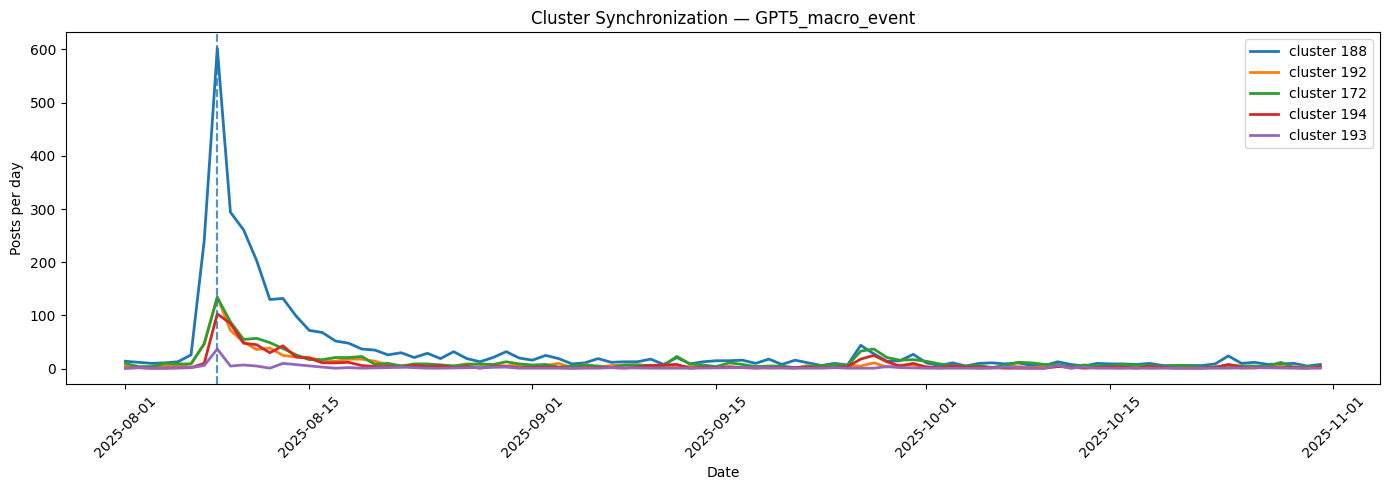

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/sync_GPT5_macro_event.png


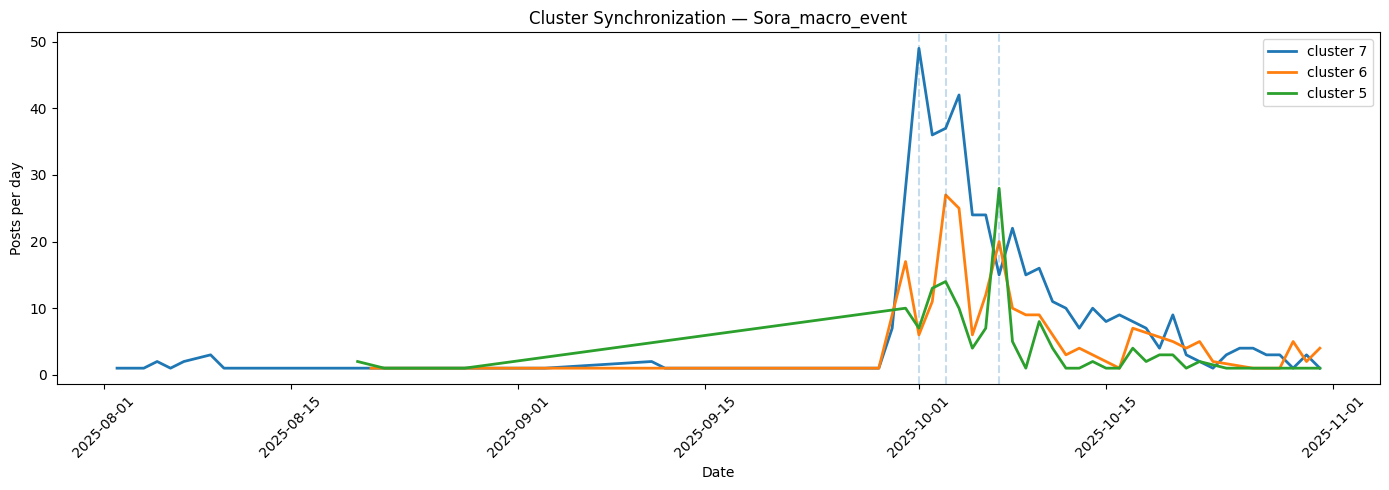

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/sync_Sora_macro_event.png


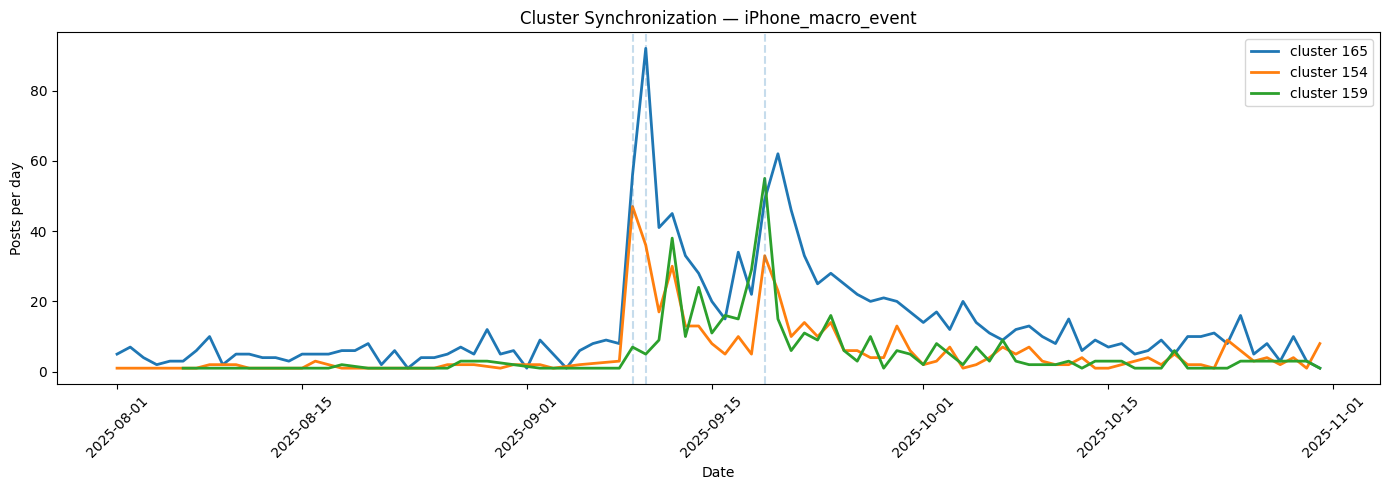

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/sync_iPhone_macro_event.png


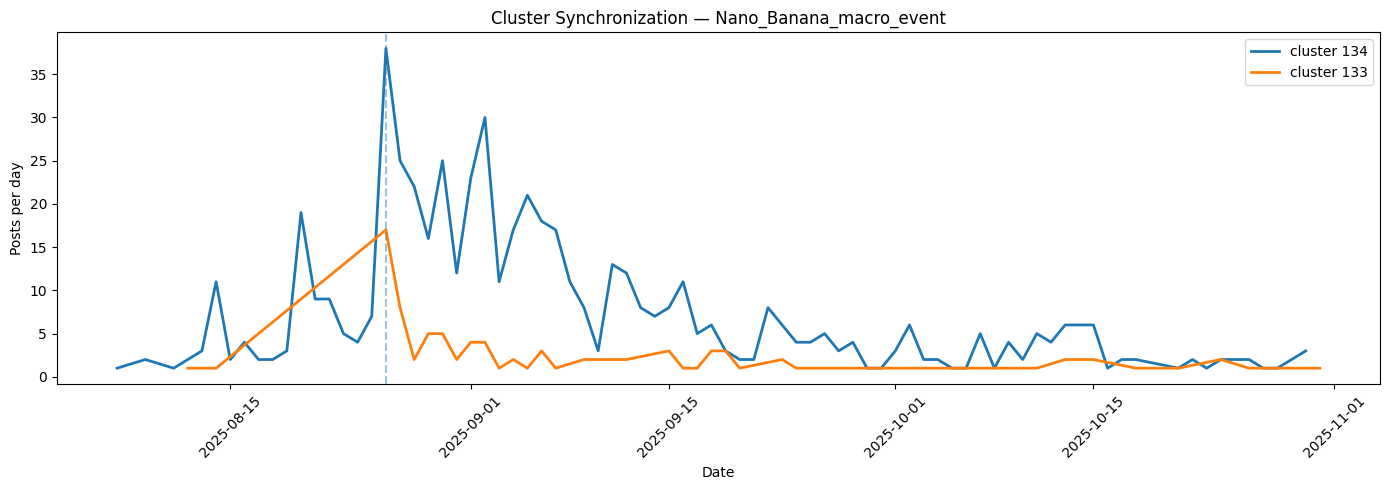

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/sync_Nano_Banana_macro_event.png


,macro_event,cluster_id,n_posts,peak_date,peak_count
0,GPT5_macro_event,188,3364,2025-08-08 00:00:00+00:00,602
1,GPT5_macro_event,192,853,2025-08-08 00:00:00+00:00,135
2,GPT5_macro_event,172,1221,2025-08-08 00:00:00+00:00,134
3,GPT5_macro_event,194,684,2025-08-08 00:00:00+00:00,103
4,GPT5_macro_event,193,146,2025-08-08 00:00:00+00:00,37
5,Sora_macro_event,7,448,2025-10-01 00:00:00+00:00,49
6,Sora_macro_event,6,212,2025-10-03 00:00:00+00:00,27
7,Sora_macro_event,5,140,2025-10-07 00:00:00+00:00,28
8,iPhone_macro_event,165,1246,2025-09-10 00:00:00+00:00,92
9,iPhone_macro_event,154,463,2025-09-09 00:00:00+00:00,47


,macro_event,n_clusters,total_posts,first_peak,last_peak,max_peak_count,peak_spread_days
0,GPT5_macro_event,5,6268,2025-08-08 00:00:00+00:00,2025-08-08 00:00:00+00:00,602,0
1,Nano_Banana_macro_event,2,663,2025-08-26 00:00:00+00:00,2025-08-26 00:00:00+00:00,38,0
2,Sora_macro_event,3,800,2025-10-01 00:00:00+00:00,2025-10-07 00:00:00+00:00,49,6
3,iPhone_macro_event,3,2121,2025-09-09 00:00:00+00:00,2025-09-19 00:00:00+00:00,92,10


Saved synchronization tables.


,Rank,Cluster,Label,Peak date,Match,Evento reale associato,Reference,error_type,explanation
19,20,82,kirk | charlie kirk,2025-09-11,"yes, but non-tech",News event,https://www.fbi.gov/news,false_positive,Domain noise: real-world burst but not technol...


,event_name,detected_in_all_clusters,best_cluster_S5_semantic_quality,best_label_S5_semantic_quality,best_rank_S5_semantic_quality,in_top20,in_top50,in_top100,rank_bucket,manual_status
0,OpenAI GPT-OSS / open-weight model discussion,True,172,4o | openai | gpt,3,True,True,True,top20,partial_absorbed_by_gpt_macro_event
1,Gemini for Home launch,True,155,magsafe | iphone 17 | 17 pro,41,False,True,True,top50,likely_false_negative_or_false_keyword_match
2,Copilot ecosystem event,True,34,deepseek | deepseek v3 | v3,54,False,False,True,top100,likely_false_negative_or_false_keyword_match
3,Meta AI / Meta Connect ecosystem event,True,7,sora | cameo | sora2,11,True,True,True,top20,likely_false_negative_or_false_keyword_match
4,xAI / Grok ecosystem event,True,16,grok | elon | musk,45,False,True,True,top50,detected_low_rank
5,Android ecosystem event,True,37,ocr | deepseek | vlm,57,False,False,True,top100,likely_false_negative_or_false_keyword_match
6,Google AI Mode / Search AI rollout,True,189,gpt | gpt5 | gpt ai,29,False,True,True,top50,likely_false_negative_or_false_keyword_match
7,NVIDIA infrastructure / GTC-related news,True,89,nvidia | china | chips,16,True,True,True,top20,detected


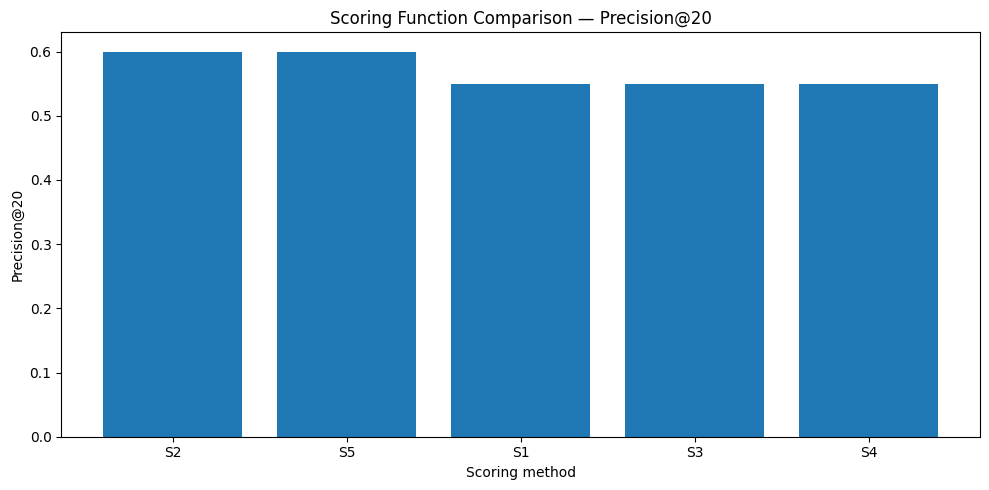

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/score_comparison_precision20.png


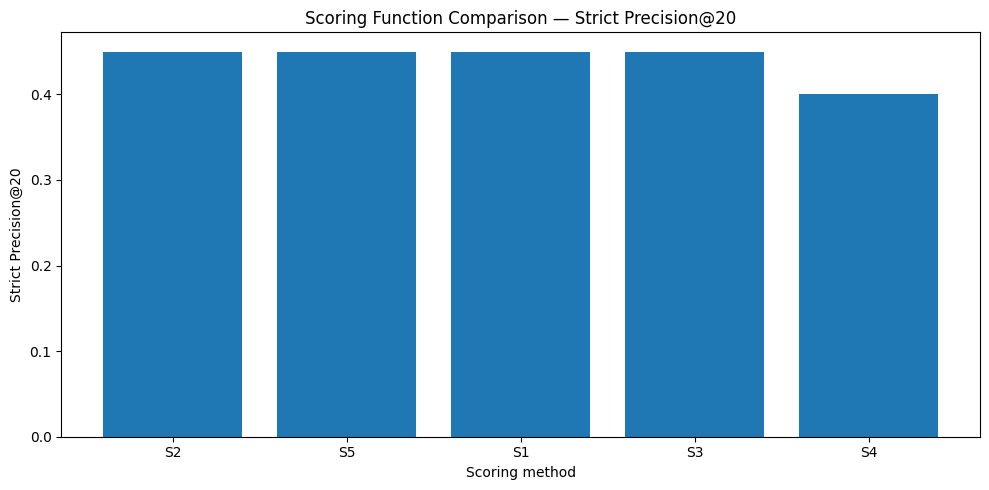

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/score_comparison_strict_precision20.png


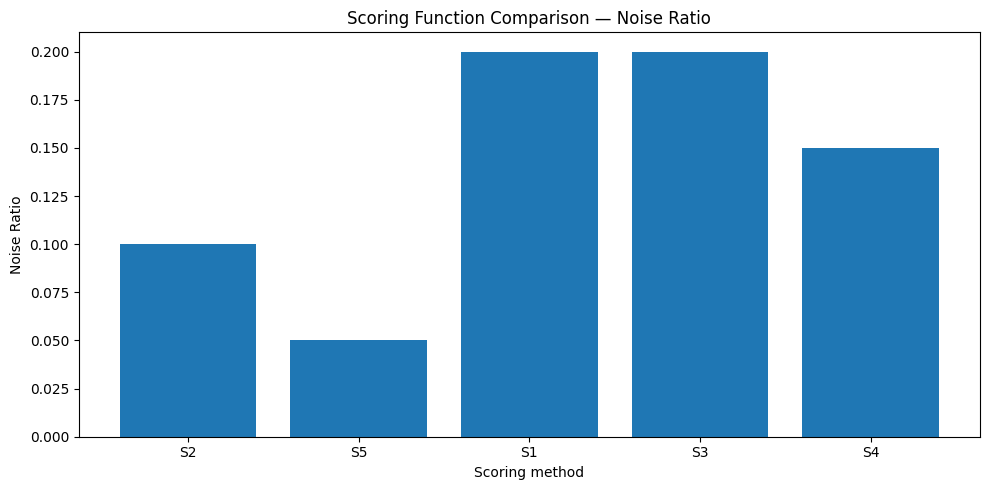

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/score_comparison_noise_ratio.png
No dedup metrics file found. Skipping before/after dedup plots.


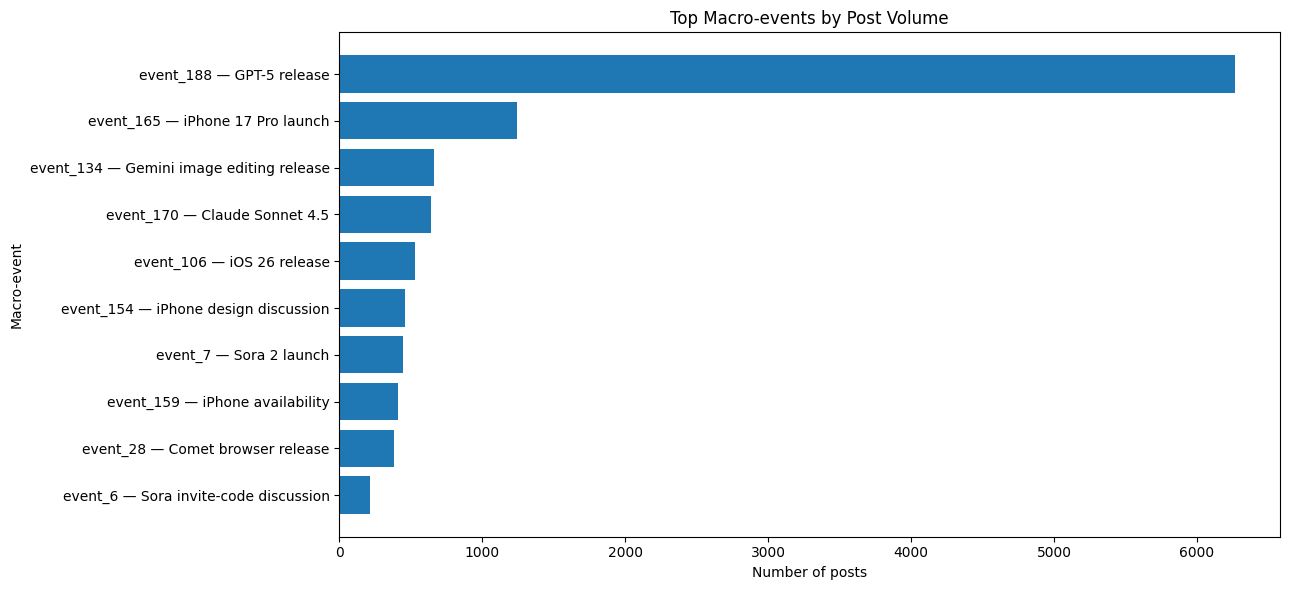

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/macro_event_post_volume_top10.png


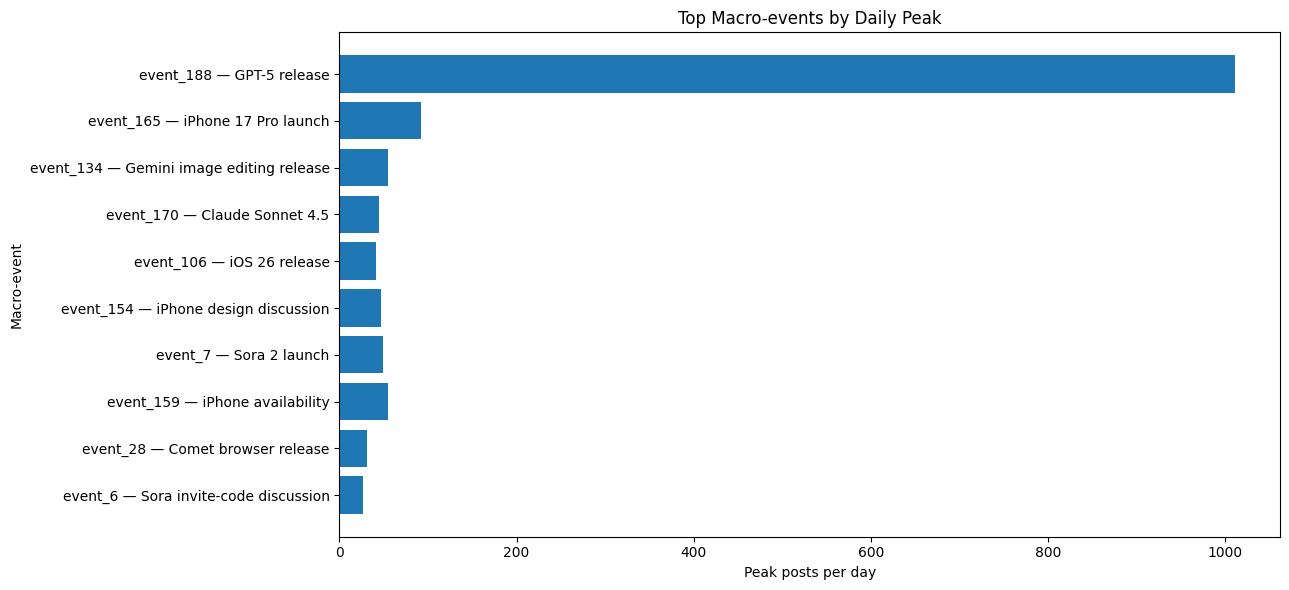

Saved: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots/macro_event_peak_top10.png

DONE.
Final plots and tables saved in: /content/drive/MyDrive/AI_project/outputs/evaluation/final_plots


In [ ]:
# ============================================================
# FINAL EVALUATION ANALYSIS
# A. Cluster synchronization analysis
# B. Error analysis
# C. Final plots
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE = Path("/content/drive/MyDrive/AI_project")

POSTS_FILE = BASE / "reddit_tech_posts_with_clusters.parquet"

EVAL_DIR = BASE / "outputs/evaluation"
MACRO_DIR = EVAL_DIR / "macro_event_analysis"
FINAL_PLOTS_DIR = EVAL_DIR / "final_plots"

FINAL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_FILE = EVAL_DIR / "S5_validation_with_auto_macro_events.xlsx"
METRICS_FILE = EVAL_DIR / "evaluation_metrics.csv"
DEDUP_METRICS_FILE = EVAL_DIR / "S5_before_after_auto_dedup_metrics.csv"

# If this file has a different name, adjust here
if not DEDUP_METRICS_FILE.exists():
    DEDUP_METRICS_FILE = EVAL_DIR / "S5_before_after_dedup.csv"

# ============================================================
# LOAD DATA
# ============================================================

posts = pd.read_parquet(POSTS_FILE)
validation = pd.read_excel(VALIDATION_FILE)

posts["date"] = pd.to_datetime(posts["date"], utc=True, errors="coerce").dt.floor("D")
validation["Peak date"] = pd.to_datetime(validation["Peak date"], errors="coerce")

validation["Match_clean"] = (
    validation["Match"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Posts:", posts.shape)
print("Validation:", validation.shape)

# ============================================================
# A. CLUSTER SYNCHRONIZATION ANALYSIS
# ============================================================

# Macro-event groups to inspect
macro_groups = {
    "GPT5_macro_event": [188, 192, 172, 194, 193],
    "Sora_macro_event": [7, 6, 5],
    "iPhone_macro_event": [165, 154, 159],
    "Nano_Banana_macro_event": [134, 133],
}

sync_rows = []

for event_name, clusters in macro_groups.items():

    plt.figure(figsize=(14, 5))

    peak_dates = []

    for cluster_id in clusters:
        subset = posts[posts["cluster_id"] == cluster_id].copy()

        if subset.empty:
            continue

        daily = (
            subset
            .groupby("date")
            .size()
            .reset_index(name="n_posts")
            .sort_values("date")
        )

        peak_idx = daily["n_posts"].idxmax()
        peak_date = daily.loc[peak_idx, "date"]
        peak_count = int(daily.loc[peak_idx, "n_posts"])

        peak_dates.append(peak_date)

        sync_rows.append({
            "macro_event": event_name,
            "cluster_id": cluster_id,
            "n_posts": len(subset),
            "peak_date": peak_date,
            "peak_count": peak_count
        })

        plt.plot(
            daily["date"],
            daily["n_posts"],
            linewidth=2,
            label=f"cluster {cluster_id}"
        )

        plt.axvline(
            peak_date,
            linestyle="--",
            alpha=0.25
        )

    plt.title(f"Cluster Synchronization — {event_name}")
    plt.xlabel("Date")
    plt.ylabel("Posts per day")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    out_plot = FINAL_PLOTS_DIR / f"sync_{event_name}.png"
    plt.savefig(out_plot, dpi=200)
    plt.show()

    print("Saved:", out_plot)

sync_df = pd.DataFrame(sync_rows)

# Compute peak spread per macro event
sync_summary = (
    sync_df
    .groupby("macro_event")
    .agg(
        n_clusters=("cluster_id", "nunique"),
        total_posts=("n_posts", "sum"),
        first_peak=("peak_date", "min"),
        last_peak=("peak_date", "max"),
        max_peak_count=("peak_count", "max")
    )
    .reset_index()
)

sync_summary["peak_spread_days"] = (
    sync_summary["last_peak"] - sync_summary["first_peak"]
).dt.days

display(sync_df)
display(sync_summary)

sync_df.to_csv(FINAL_PLOTS_DIR / "cluster_synchronization_details.csv", index=False)
sync_summary.to_csv(FINAL_PLOTS_DIR / "cluster_synchronization_summary.csv", index=False)

print("Saved synchronization tables.")

# ============================================================
# B. ERROR ANALYSIS
# ============================================================

# False positives from Top-20 S5 validation:
# non-tech or no / weak rows.
false_positive_mask = (
    validation["Match_clean"].str.contains("no", na=False)
    |
    validation["Match_clean"].str.contains("non-tech", na=False)
)

false_positives = validation[false_positive_mask].copy()

false_positives["error_type"] = "false_positive"
false_positives["explanation"] = false_positives["Match_clean"].apply(
    lambda x: (
        "Domain noise: real-world burst but not technology-related"
        if "non-tech" in x
        else "Low relevance or generic discussion not corresponding to a clear technology event"
    )
)

false_positives_out = false_positives[
    [
        "Rank",
        "Cluster",
        "Label",
        "Peak date",
        "Match",
        "Evento reale associato",
        "Reference",
        "error_type",
        "explanation"
    ]
]

display(false_positives_out)

false_positives_out.to_csv(
    FINAL_PLOTS_DIR / "false_positive_analysis.csv",
    index=False
)

# False negatives / missed or weak external events
# If you already generated this file, use it.
external_position_file = EVAL_DIR / "final_external_event_positioning.csv"

if external_position_file.exists():
    external = pd.read_csv(external_position_file)

    # Manual correction field for likely false keyword matches
    external["manual_status"] = "needs_manual_check"

    # Rules from your observed output
    likely_false_matches = [
        "Gemini for Home",
        "Copilot",
        "Meta AI",
        "Android",
        "Google AI Mode"
    ]

    def classify_external(row):
        name = str(row["event_name"]).lower()
        label = str(row.get("best_label_S5_semantic_quality", "")).lower()

        if "grok" in name and "grok" in label:
            return "detected_low_rank"
        if "nvidia" in name and "nvidia" in label:
            return "detected"
        if "gpt-oss" in name or "open-weight" in name:
            return "partial_absorbed_by_gpt_macro_event"

        for kw in likely_false_matches:
            if kw.lower() in name:
                return "likely_false_negative_or_false_keyword_match"

        return "needs_manual_check"

    external["manual_status"] = external.apply(classify_external, axis=1)

    false_negative_analysis = external[
        [
            "event_name",
            "detected_in_all_clusters",
            "best_cluster_S5_semantic_quality",
            "best_label_S5_semantic_quality",
            "best_rank_S5_semantic_quality",
            "in_top20",
            "in_top50",
            "in_top100",
            "rank_bucket",
            "manual_status"
        ]
    ]

    display(false_negative_analysis)

    false_negative_analysis.to_csv(
        FINAL_PLOTS_DIR / "false_negative_analysis.csv",
        index=False
    )

else:
    print("final_external_event_positioning.csv not found. Skipping false-negative table.")

# ============================================================
# C. FINAL PLOTS
# ============================================================

# ------------------------------------------------------------
# Plot 1 — Score comparison
# ------------------------------------------------------------

metrics = pd.read_csv(METRICS_FILE)

plt.figure(figsize=(10, 5))
plt.bar(metrics["score"], metrics["precision@20"])
plt.xlabel("Scoring method")
plt.ylabel("Precision@20")
plt.title("Scoring Function Comparison — Precision@20")
plt.tight_layout()

out_plot = FINAL_PLOTS_DIR / "score_comparison_precision20.png"
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

# ------------------------------------------------------------
# Plot 2 — Strict precision comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(metrics["score"], metrics["strict_precision"])
plt.xlabel("Scoring method")
plt.ylabel("Strict Precision@20")
plt.title("Scoring Function Comparison — Strict Precision@20")
plt.tight_layout()

out_plot = FINAL_PLOTS_DIR / "score_comparison_strict_precision20.png"
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

# ------------------------------------------------------------
# Plot 3 — Noise ratio comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(metrics["score"], metrics["noise_ratio"])
plt.xlabel("Scoring method")
plt.ylabel("Noise Ratio")
plt.title("Scoring Function Comparison — Noise Ratio")
plt.tight_layout()

out_plot = FINAL_PLOTS_DIR / "score_comparison_noise_ratio.png"
plt.savefig(out_plot, dpi=200)
plt.show()

print("Saved:", out_plot)

# ------------------------------------------------------------
# Plot 4 — Before vs After Deduplication
# ------------------------------------------------------------

# Try to load dedup metrics robustly
possible_files = [
    EVAL_DIR / "S5_before_after_auto_dedup_metrics.csv",
    EVAL_DIR / "S5_before_after_dedup.csv",
    EVAL_DIR / "S5_before_after_dedup_metrics.csv",
]

dedup_metrics = None

for f in possible_files:
    if f.exists():
        dedup_metrics = pd.read_csv(f)
        print("Loaded dedup metrics:", f)
        break

if dedup_metrics is not None:
    display(dedup_metrics)

    # Find precision column
    precision_col = None
    for col in dedup_metrics.columns:
        if "precision" in col.lower() and "liberal" in col.lower():
            precision_col = col
            break

    if precision_col is None:
        for col in dedup_metrics.columns:
            if "precision@20" in col.lower():
                precision_col = col
                break

    if precision_col is not None:
        plt.figure(figsize=(8, 5))
        plt.bar(dedup_metrics["stage"], dedup_metrics[precision_col])
        plt.xlabel("Stage")
        plt.ylabel("Precision@20")
        plt.title("Before vs After Automatic Deduplication")
        plt.xticks(rotation=20)
        plt.tight_layout()

        out_plot = FINAL_PLOTS_DIR / "before_after_dedup_precision.png"
        plt.savefig(out_plot, dpi=200)
        plt.show()

        print("Saved:", out_plot)

    if "duplicate_ratio" in dedup_metrics.columns:
        plt.figure(figsize=(8, 5))
        plt.bar(dedup_metrics["stage"], dedup_metrics["duplicate_ratio"])
        plt.xlabel("Stage")
        plt.ylabel("Duplicate Ratio")
        plt.title("Duplicate Ratio Before vs After Deduplication")
        plt.xticks(rotation=20)
        plt.tight_layout()

        out_plot = FINAL_PLOTS_DIR / "before_after_dedup_duplicate_ratio.png"
        plt.savefig(out_plot, dpi=200)
        plt.show()

        print("Saved:", out_plot)

else:
    print("No dedup metrics file found. Skipping before/after dedup plots.")

# ------------------------------------------------------------
# Plot 5 — Macro-event size summary
# ------------------------------------------------------------

macro_summary_file = MACRO_DIR / "macro_event_summary.csv"

if macro_summary_file.exists():
    macro_summary = pd.read_csv(macro_summary_file)

    macro_summary_plot = (
        macro_summary
        .sort_values("n_posts", ascending=False)
        .head(10)
        .copy()
    )

    labels = (
        macro_summary_plot["macro_event_id"].astype(str)
        + " — "
        + macro_summary_plot["event_name"].astype(str)
    )

    plt.figure(figsize=(13, 6))
    plt.barh(labels, macro_summary_plot["n_posts"])
    plt.gca().invert_yaxis()
    plt.xlabel("Number of posts")
    plt.ylabel("Macro-event")
    plt.title("Top Macro-events by Post Volume")
    plt.tight_layout()

    out_plot = FINAL_PLOTS_DIR / "macro_event_post_volume_top10.png"
    plt.savefig(out_plot, dpi=200)
    plt.show()

    print("Saved:", out_plot)

    plt.figure(figsize=(13, 6))
    plt.barh(labels, macro_summary_plot["peak_count"])
    plt.gca().invert_yaxis()
    plt.xlabel("Peak posts per day")
    plt.ylabel("Macro-event")
    plt.title("Top Macro-events by Daily Peak")
    plt.tight_layout()

    out_plot = FINAL_PLOTS_DIR / "macro_event_peak_top10.png"
    plt.savefig(out_plot, dpi=200)
    plt.show()

    print("Saved:", out_plot)

else:
    print("macro_event_summary.csv not found. Skipping macro-event plots.")

print("\nDONE.")
print("Final plots and tables saved in:", FINAL_PLOTS_DIR)